# Time Series Forecasting

Bitcoin


## Setup

CLI login -- gcloud auth application-default login

In [73]:
!pip install google-cloud-bigquery google-cloud-storage db-dtypes matplotlib seaborn statsmodels google-cloud-aiplatform

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 34.6 MB/s  0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 59.3 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [google-cloud-aiplatfo

In [44]:
# Standard library
import datetime
import io
import os
import warnings
import zipfile

# Third party
import pandas as pd
import requests
from google.cloud import bigquery, storage
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

# GCP configuration
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = "carty-470812"
GCS_PREFIX = "ml_projects/project_3_bitcoin"

# BigQuery
BQ_DATASET = "bitcoin_volatility"
BQ_TABLE_RAW = "btcusdt_5m_bars_raw"
BQ_TABLE = "btcusdt_5m_bars"
BQ_LOCATION = "US"  # Multi-region; matches public datasets like crypto_bitcoin

# Binance source
BINANCE_BASE_URL = "https://data.binance.vision/data/spot/monthly/klines"
SYMBOL = "BTCUSDT"
INTERVAL = "5m"
START_YEAR = 2017
START_MONTH = 8  # BTCUSDT begins on Binance in August 2017

# Clients
storage_client = storage.Client(project=PROJECT_ID)
bq_client = bigquery.Client(project=PROJECT_ID, location=BQ_LOCATION)

print(f"Project: {PROJECT_ID}")
print(f"Bucket:  gs://{BUCKET_NAME}/{GCS_PREFIX}")
print(f"Dataset: {PROJECT_ID}.{BQ_DATASET}")

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Project: carty-470812
Bucket:  gs://carty-470812/ml_projects/project_3_bitcoin
Dataset: carty-470812.bitcoin_volatility


In [23]:
def list_months_to_ingest(start_year, start_month, today=None):
    """Return list of (year, month) tuples from (start_year, start_month)
    through the last fully-completed month before `today`.

    Args:
        start_year: First year to include (inclusive).
        start_month: First month to include (inclusive, 1-12).
        today: Date to compute "last complete month" from. Defaults to today.

    Returns:
        List of (year, month) tuples in chronological order.
    """
    if today is None:
        today = datetime.date.today()

    # Last complete month = day before the first of the current month
    last_complete = datetime.date(today.year, today.month, 1) - datetime.timedelta(days=1)
    end_year, end_month = last_complete.year, last_complete.month

    # Linearise (year, month) to a single integer index, then iterate
    start_idx = start_year * 12 + (start_month - 1)
    end_idx = end_year * 12 + (end_month - 1)

    return [(idx // 12, idx % 12 + 1) for idx in range(start_idx, end_idx + 1)]


months_to_ingest = list_months_to_ingest(START_YEAR, START_MONTH)

print(f"Months to ingest: {len(months_to_ingest)}")
print(f"First 3: {months_to_ingest[:3]}")
print(f"Last 3:  {months_to_ingest[-3:]}")

Months to ingest: 104
First 3: [(2017, 8), (2017, 9), (2017, 10)]
Last 3:  [(2026, 1), (2026, 2), (2026, 3)]


In [24]:
def ingest_month(year, month):
    """Download a Binance monthly kline zip, extract the CSV, upload to GCS.

    Skips the upload if the GCS object already exists (idempotent).

    Args:
        year: 4-digit year.
        month: 1-12.

    Returns:
        One of: "uploaded", "skipped", "failed".
    """
    # Build the Binance URL and GCS destination
    file_stem = f"{SYMBOL}-{INTERVAL}-{year}-{month:02d}"
    url = f"{BINANCE_BASE_URL}/{SYMBOL}/{INTERVAL}/{file_stem}.zip"
    gcs_blob_path = (
        f"{GCS_PREFIX}/raw/binance/spot/klines/"
        f"{SYMBOL}/{INTERVAL}/{file_stem}.csv"
    )

    bucket = storage_client.bucket(BUCKET_NAME)
    blob = bucket.blob(gcs_blob_path)

    # Idempotency: skip if already in GCS
    if blob.exists():
        return "skipped"

    try:
        # Download the zip
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        # Extract the single CSV inside, in memory
        with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
            csv_name = zf.namelist()[0]
            csv_bytes = zf.read(csv_name)

        # Upload the CSV bytes to GCS
        blob.upload_from_string(csv_bytes, content_type="text/csv")
        return "uploaded"

    except requests.HTTPError as e:
        print(f"  HTTP error for {file_stem}: {e}")
        return "failed"
    except (requests.RequestException, zipfile.BadZipFile) as e:
        print(f"  Network/zip error for {file_stem}: {e}")
        return "failed"
    except Exception as e:
        print(f"  Unexpected error for {file_stem}: {e}")
        return "failed"

Test one month

In [25]:
result = ingest_month(2024, 1)
print(f"Result: {result}")

Result: skipped


Get all data into Bucket

In [26]:
from collections import Counter

results = Counter()
failures = []

for i, (year, month) in enumerate(months_to_ingest, start=1):
    file_stem = f"{SYMBOL}-{INTERVAL}-{year}-{month:02d}"
    status = ingest_month(year, month)
    results[status] += 1

    if status == "failed":
        failures.append((year, month))

    print(f"[{i:3d}/{len(months_to_ingest)}] {file_stem}: {status}")

print()
print("Summary:")
for status, count in results.most_common():
    print(f"  {status}: {count}")

if failures:
    print()
    print(f"Failures ({len(failures)}):")
    for year, month in failures:
        print(f"  ({year}, {month})")

[  1/104] BTCUSDT-5m-2017-08: skipped
[  2/104] BTCUSDT-5m-2017-09: skipped
[  3/104] BTCUSDT-5m-2017-10: skipped
[  4/104] BTCUSDT-5m-2017-11: skipped
[  5/104] BTCUSDT-5m-2017-12: skipped
[  6/104] BTCUSDT-5m-2018-01: skipped
[  7/104] BTCUSDT-5m-2018-02: skipped
[  8/104] BTCUSDT-5m-2018-03: skipped
[  9/104] BTCUSDT-5m-2018-04: skipped
[ 10/104] BTCUSDT-5m-2018-05: skipped
[ 11/104] BTCUSDT-5m-2018-06: skipped
[ 12/104] BTCUSDT-5m-2018-07: skipped
[ 13/104] BTCUSDT-5m-2018-08: skipped
[ 14/104] BTCUSDT-5m-2018-09: skipped
[ 15/104] BTCUSDT-5m-2018-10: skipped
[ 16/104] BTCUSDT-5m-2018-11: skipped
[ 17/104] BTCUSDT-5m-2018-12: skipped
[ 18/104] BTCUSDT-5m-2019-01: skipped
[ 19/104] BTCUSDT-5m-2019-02: skipped
[ 20/104] BTCUSDT-5m-2019-03: skipped
[ 21/104] BTCUSDT-5m-2019-04: skipped
[ 22/104] BTCUSDT-5m-2019-05: skipped
[ 23/104] BTCUSDT-5m-2019-06: skipped
[ 24/104] BTCUSDT-5m-2019-07: skipped
[ 25/104] BTCUSDT-5m-2019-08: skipped
[ 26/104] BTCUSDT-5m-2019-09: skipped
[ 27/104] BT

In [27]:
# Quick CSV format check — does Binance include headers?
bucket = storage_client.bucket(BUCKET_NAME)
gcs_dir = f"{GCS_PREFIX}/raw/binance/spot/klines/{SYMBOL}/{INTERVAL}"

for sample in [f"{SYMBOL}-{INTERVAL}-2017-08.csv",   # earliest
               f"{SYMBOL}-{INTERVAL}-2024-01.csv",   # mid
               f"{SYMBOL}-{INTERVAL}-2026-03.csv"]:  # latest
    blob = bucket.blob(f"{gcs_dir}/{sample}")
    first_bytes = blob.download_as_bytes(start=0, end=200)
    first_line = first_bytes.decode("utf-8").split("\n")[0]
    print(f"{sample}:\n  {first_line}\n")

BTCUSDT-5m-2017-08.csv:
  1502942400000,4261.48000000,4280.56000000,4261.48000000,4261.48000000,2.18906100,1502942699999,9333.62096220,9,0.48906100,2089.10496220,7960.37529526

BTCUSDT-5m-2024-01.csv:
  1704067200000,42283.58000000,42397.23000000,42261.02000000,42397.23000000,155.25731000,1704067499999,6572925.83256960,6350,106.05732000,4490262.47081090,0

BTCUSDT-5m-2026-03.csv:
  1772323200000000,66973.26000000,67121.80000000,66953.63000000,67038.82000000,131.15604000,1772323499999999,8789022.79659130,23006,105.80351000,7090094.81187060,0



### Phase 5a: Raw load — GCS CSVs to btcusdt_5m_bars_raw


In [28]:
# Phase 5a: Raw load — GCS CSVs to btcusdt_5m_bars_raw

# Step 1: Create the dataset (idempotent)
dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{BQ_DATASET}")
dataset_ref.location = BQ_LOCATION
dataset = bq_client.create_dataset(dataset_ref, exists_ok=True)
print(f"Dataset ready: {dataset.full_dataset_id} ({dataset.location})")

# Step 2: Define the explicit schema (12 columns, no header in CSVs)
raw_schema = [
    bigquery.SchemaField("open_time", "INTEGER"),
    bigquery.SchemaField("open", "FLOAT64"),
    bigquery.SchemaField("high", "FLOAT64"),
    bigquery.SchemaField("low", "FLOAT64"),
    bigquery.SchemaField("close", "FLOAT64"),
    bigquery.SchemaField("volume", "FLOAT64"),
    bigquery.SchemaField("close_time", "INTEGER"),
    bigquery.SchemaField("quote_volume", "FLOAT64"),
    bigquery.SchemaField("trade_count", "INTEGER"),
    bigquery.SchemaField("taker_buy_base", "FLOAT64"),
    bigquery.SchemaField("taker_buy_quote", "FLOAT64"),
    bigquery.SchemaField("ignore_col", "FLOAT64"),
]

# Step 3: Configure and run the load job
job_config = bigquery.LoadJobConfig(
    schema=raw_schema,
    source_format=bigquery.SourceFormat.CSV,
    field_delimiter=",",
    skip_leading_rows=0,
    autodetect=False,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

source_uri = (
    f"gs://{BUCKET_NAME}/{GCS_PREFIX}/raw/binance/spot/klines/"
    f"{SYMBOL}/{INTERVAL}/*.csv"
)
table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_RAW}"

print(f"Loading {source_uri} → {table_id}...")

load_job = bq_client.load_table_from_uri(
    source_uri,
    table_id,
    job_config=job_config,
)
load_job.result()  # block until done

# Step 4: Verify
table = bq_client.get_table(table_id)
print(f"Loaded {table.num_rows:,} rows into {table_id}")

Dataset ready: carty-470812:bitcoin_volatility (US)
Loading gs://carty-470812/ml_projects/project_3_bitcoin/raw/binance/spot/klines/BTCUSDT/5m/*.csv → carty-470812.bitcoin_volatility.btcusdt_5m_bars_raw...
Loaded 905,161 rows into carty-470812.bitcoin_volatility.btcusdt_5m_bars_raw


### Phase 5b: Transform — raw → partitioned, typed final table


In [29]:
# Phase 5b: Transform — raw → partitioned, typed final table

table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"
raw_table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_RAW}"

transform_sql = f"""
CREATE OR REPLACE TABLE `{table_id}`
PARTITION BY DATE(open_time)
OPTIONS (
  description = "BTCUSDT 5-minute bars from Binance, partitioned by date",
  require_partition_filter = false
)
AS
SELECT
  '{SYMBOL}' AS symbol,
  TIMESTAMP_MICROS(
    CASE
      WHEN open_time < 100000000000000 THEN open_time * 1000
      ELSE open_time
    END
  ) AS open_time,
  TIMESTAMP_MICROS(
    CASE
      WHEN close_time < 100000000000000 THEN close_time * 1000
      ELSE close_time
    END
  ) AS close_time,
  open,
  high,
  low,
  close,
  volume,
  quote_volume,
  trade_count,
  taker_buy_base,
  taker_buy_quote
FROM `{raw_table_id}`
"""

print(f"Transforming {raw_table_id} → {table_id}...")
job = bq_client.query(transform_sql)
job.result()  # block until done

table = bq_client.get_table(table_id)
print(f"Created {table_id}")
print(f"  Rows: {table.num_rows:,}")
print(f"  Partitioning: {table.time_partitioning}")
print(f"  Schema: {[f.name for f in table.schema]}")

Transforming carty-470812.bitcoin_volatility.btcusdt_5m_bars_raw → carty-470812.bitcoin_volatility.btcusdt_5m_bars...
Created carty-470812.bitcoin_volatility.btcusdt_5m_bars
  Rows: 905,161
  Partitioning: TimePartitioning(field='open_time',type_='DAY')
  Schema: ['symbol', 'open_time', 'close_time', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'trade_count', 'taker_buy_base', 'taker_buy_quote']


In [30]:
table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"

# Check 1: Date coverage
print("=" * 60)
print("Check 1: Date coverage")
print("=" * 60)
sql = f"""
SELECT
  MIN(open_time) AS earliest,
  MAX(open_time) AS latest,
  COUNT(*) AS total_rows,
  TIMESTAMP_DIFF(MAX(open_time), MIN(open_time), DAY) AS days_span
FROM `{table_id}`
"""
display(bq_client.query(sql).to_dataframe())

# Check 2: Daily bar density (find suspicious days)
print()
print("=" * 60)
print("Check 2: Days with < 280 bars (288 = full day)")
print("=" * 60)
sql = f"""
SELECT
  DATE(open_time) AS day,
  COUNT(*) AS bar_count
FROM `{table_id}`
GROUP BY day
HAVING bar_count < 280
ORDER BY bar_count ASC
LIMIT 20
"""
display(bq_client.query(sql).to_dataframe())

# Check 3: Duplicate detection
print()
print("=" * 60)
print("Check 3: Duplicate open_time values")
print("=" * 60)
sql = f"""
SELECT
  open_time,
  COUNT(*) AS occurrences
FROM `{table_id}`
GROUP BY open_time
HAVING occurrences > 1
ORDER BY occurrences DESC
LIMIT 10
"""
duplicates_df = bq_client.query(sql).to_dataframe()
if duplicates_df.empty:
    print("No duplicates found.")
else:
    display(duplicates_df)

# Check 4: Price sanity
print()
print("=" * 60)
print("Check 4: Price ranges and NULL counts")
print("=" * 60)
sql = f"""
SELECT
  MIN(close) AS min_close,
  MAX(close) AS max_close,
  AVG(close) AS avg_close,
  COUNTIF(close IS NULL) AS null_close,
  COUNTIF(volume = 0) AS zero_volume_bars,
  COUNT(*) AS total_rows
FROM `{table_id}`
"""
display(bq_client.query(sql).to_dataframe())

# Check 5: Microsecond/millisecond transition sanity
print()
print("=" * 60)
print("Check 5: Sample bars from key dates")
print("=" * 60)
sql = f"""
SELECT
  open_time,
  open,
  close
FROM `{table_id}`
WHERE DATE(open_time) IN ('2017-08-17', '2024-12-31', '2025-01-01', '2026-03-31')
ORDER BY open_time
LIMIT 20
"""
display(bq_client.query(sql).to_dataframe())

Check 1: Date coverage


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,earliest,latest,total_rows,days_span
0,2017-08-17 04:00:00+00:00,2026-03-31 23:55:00+00:00,905161,3148



Check 2: Days with < 280 bars (288 = full day)


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


...

No duplicates found.

Check 4: Price ranges and NULL counts


,min_close,max_close,avg_close,null_close,zero_volume_bars,total_rows
0,2820.0,126011.18,37119.870587,0,932,905161



Check 5: Sample bars from key dates


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,open_time,open,close
0,2017-08-17 04:00:00+00:00,4261.48,4261.48
1,2017-08-17 04:05:00+00:00,4261.48,4261.48
2,2017-08-17 04:10:00+00:00,4261.48,4261.48
3,2017-08-17 04:15:00+00:00,4261.48,4261.48
4,2017-08-17 04:20:00+00:00,4264.88,4266.29
5,2017-08-17 04:25:00+00:00,4266.29,4261.45
6,2017-08-17 04:30:00+00:00,4280.00,4296.63
7,2017-08-17 04:35:00+00:00,4300.38,4300.38
8,2017-08-17 04:40:00+00:00,4300.38,4310.07
9,2017-08-17 04:45:00+00:00,4310.07,4292.01


## Daily Realized Variance + On-Chain Feature Engineering

A new BigQuery table daily_market_features with one row per calendar day, containing:

| Column            |  Type        | Description  |
| --- | --- | --- |
| date              |  DATE      |  Calendar day (UTC)  |
| realized_variance | FLOAT64    | Σ (log return)² over all 5-min returns within the day  |
| log_rv            |  FLOAT64   |  LN (realized_variance) — the modelling target  |
| bar_count         |  INTEGER   |  Number of 5-min bars present that day (max 288)  |
| daily_open        |  FLOAT64   |  First close price of the day | 
| daily_high        |  FLOAT64   |  Max close price of the day  |
| daily_low         |  FLOAT64   |  Min close price of the day  |
| daily_close       |  FLOAT64   |  Last close price of the day  |
| daily_volume      |  FLOAT64   |  Total BTC volume traded  |
| daily_quote_volume | FLOAT64   |  Total USDT volume traded  |
| daily_trade_countI | NTEGER    |  Total trades count  |
  
So we get the target plus a set of supporting daily features that will be useful for the GBT and LSTM models.

In [31]:
target_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_market_features"
source_table = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"

market_features_sql = f"""
CREATE OR REPLACE TABLE `{target_table}`
PARTITION BY date
OPTIONS (
  description = "Daily market features for BTCUSDT: realized variance + supporting OHLCV"
)
AS
WITH returns AS (
  SELECT
    DATE(open_time) AS date,
    open_time,
    close,
    volume,
    quote_volume,
    trade_count,
    SAFE.LN(SAFE_DIVIDE(close, LAG(close) OVER (ORDER BY open_time))) AS log_return
  FROM `{source_table}`
)
SELECT
  date,
  SUM(POW(log_return, 2)) AS realized_variance,
  SAFE.LN(SUM(POW(log_return, 2))) AS log_rv,
  COUNT(*) AS bar_count,
  ARRAY_AGG(close ORDER BY open_time LIMIT 1)[OFFSET(0)] AS daily_open,
  MAX(close) AS daily_high,
  MIN(close) AS daily_low,
  ARRAY_AGG(close ORDER BY open_time DESC LIMIT 1)[OFFSET(0)] AS daily_close,
  SUM(volume) AS daily_volume,
  SUM(quote_volume) AS daily_quote_volume,
  SUM(trade_count) AS daily_trade_count
FROM returns
GROUP BY date
"""

print(f"Computing daily market features → {target_table}...")
job = bq_client.query(market_features_sql)
job.result()

table = bq_client.get_table(target_table)
print(f"Created {target_table}")
print(f"  Rows: {table.num_rows:,}")

# Quick sanity preview
preview_sql = f"""
SELECT *
FROM `{target_table}`
ORDER BY date
LIMIT 5
"""
display(bq_client.query(preview_sql).to_dataframe())

Computing daily market features → carty-470812.bitcoin_volatility.daily_market_features...
Created carty-470812.bitcoin_volatility.daily_market_features
  Rows: 3,149


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,realized_variance,log_rv,bar_count,daily_open,daily_high,daily_low,daily_close,daily_volume,daily_quote_volume,daily_trade_count
0,2017-08-17,0.003797,-5.573621,240,4261.48,4485.39,4200.74,4285.08,795.150377,3.454770e+06,3427
1,2017-08-18,0.006742,-4.999330,288,4287.09,4371.42,3956.30,4108.37,1199.888264,5.086958e+06,5233
2,2017-08-19,0.007465,-4.897542,288,4106.44,4184.68,3903.79,4139.98,381.309763,1.549484e+06,2153
3,2017-08-20,0.003534,-5.645330,288,4139.98,4199.32,4052.82,4086.29,467.083022,1.930364e+06,2321
4,2017-08-21,0.007742,-4.861090,288,4091.30,4114.86,3914.00,4016.00,691.743060,2.797232e+06,3972


### Daily On-Chain Features from bigquery-public-data.crypto_bitcoin

In [33]:
# Quick reconnaissance: what columns does blocks have, and what does one row look like?
recon_sql = """
SELECT *
FROM `bigquery-public-data.crypto_bitcoin.blocks`
WHERE DATE(timestamp) = '2024-01-15'
LIMIT 1
"""
recon_df = bq_client.query(recon_sql).to_dataframe()
print("Columns in `blocks`:")
for col in recon_df.columns:
    print(f"  {col}: {recon_df[col].dtype}")
print()
print("Sample row:")
display(recon_df)

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Columns in `blocks`:
  hash: object
  size: Int64
  stripped_size: Int64
  weight: Int64
  number: Int64
  version: Int64
  merkle_root: object
  timestamp: datetime64[us, UTC]
  timestamp_month: dbdate
  nonce: object
  bits: object
  coinbase_param: object
  transaction_count: Int64

Sample row:


,hash,size,stripped_size,weight,number,version,merkle_root,timestamp,timestamp_month,nonce,bits,coinbase_param,transaction_count
0,00000000000000000003a482ff150df4173dc49f68fcff...,1706518,762295,3993403,825872,771416064,fc7e701a31eab608c7a0a99e42249ba03b1ae0e0503809...,2024-01-15 08:25:40+00:00,2024-01-01,28fc21b3,1703d869,03109a0c194d696e656420627920416e74506f6f6c2085...,4124


In [34]:
target_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_onchain_features"

onchain_sql = f"""
CREATE OR REPLACE TABLE `{target_table}`
PARTITION BY date
OPTIONS (
  description = "Daily Bitcoin on-chain features from bigquery-public-data.crypto_bitcoin.blocks"
)
AS
SELECT
  DATE(timestamp) AS date,
  COUNT(*) AS block_count,
  SUM(size) AS total_block_size_bytes,
  SUM(transaction_count) AS total_transaction_count,
  AVG(transaction_count) AS avg_transactions_per_block,
  AVG(size) AS avg_block_size_bytes
FROM `bigquery-public-data.crypto_bitcoin.blocks`
WHERE timestamp_month >= DATE('2017-08-01')
  AND timestamp_month <= DATE('2026-04-01')
GROUP BY date
"""

print(f"Computing daily on-chain features → {target_table}...")
job = bq_client.query(onchain_sql)
job_result = job.result()

# Cost transparency
total_bytes_billed = job.total_bytes_billed
total_gb_billed = total_bytes_billed / (1024 ** 3)
estimated_cost_usd = total_bytes_billed / (1024 ** 4) * 5  # $5 per TB
print(f"  Bytes billed: {total_bytes_billed:,} ({total_gb_billed:.2f} GB)")
print(f"  Estimated cost: ${estimated_cost_usd:.4f}")

table = bq_client.get_table(target_table)
print(f"Created {target_table}")
print(f"  Rows: {table.num_rows:,}")

# Preview
preview_sql = f"""
SELECT *
FROM `{target_table}`
ORDER BY date
LIMIT 5
"""
display(bq_client.query(preview_sql).to_dataframe())

Computing daily on-chain features → carty-470812.bitcoin_volatility.daily_onchain_features...
  Bytes billed: 15,728,640 (0.01 GB)
  Estimated cost: $0.0001
Created carty-470812.bitcoin_volatility.daily_onchain_features
  Rows: 3,191


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,block_count,total_block_size_bytes,total_transaction_count,avg_transactions_per_block,avg_block_size_bytes
0,2017-08-01,149,108068453,131875,885.067114,725291.630872
1,2017-08-02,152,133468687,209321,1377.111842,878083.467105
2,2017-08-03,138,119901950,213017,1543.601449,868854.710145
3,2017-08-04,179,165422429,235792,1317.273743,924147.648045
4,2017-08-05,177,155977992,239771,1354.638418,881231.593220


### Joining Into the Final daily_features Table

In [36]:
target_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_features"
market_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_market_features"
onchain_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_onchain_features"

join_sql = f"""
CREATE OR REPLACE TABLE `{target_table}`
PARTITION BY date
OPTIONS (
  description = "Daily features for BTC volatility forecasting: target + market + on-chain"
)
AS
SELECT
  m.date,
  -- Target
  m.realized_variance,
  m.log_rv,
  -- Market features
  m.bar_count,
  m.daily_open,
  m.daily_high,
  m.daily_low,
  m.daily_close,
  m.daily_volume,
  m.daily_quote_volume,
  m.daily_trade_count,
  -- On-chain features
  o.block_count,
  o.total_block_size_bytes,
  o.total_transaction_count,
  o.avg_transactions_per_block,
  o.avg_block_size_bytes
FROM `{market_table}` m
INNER JOIN `{onchain_table}` o
  USING (date)
"""

print(f"Joining → {target_table}...")
job = bq_client.query(join_sql)
job.result()

table = bq_client.get_table(target_table)
print(f"Created {target_table}")
print(f"  Rows: {table.num_rows:,}")
print(f"  Schema: {[f.name for f in table.schema]}")

# Sanity preview
preview_sql = f"""
SELECT *
FROM `{target_table}`
ORDER BY date
LIMIT 5
"""
display(bq_client.query(preview_sql).to_dataframe())

# Coverage check
coverage_sql = f"""
SELECT
  MIN(date) AS earliest,
  MAX(date) AS latest,
  COUNT(*) AS total_days,
  DATE_DIFF(MAX(date), MIN(date), DAY) + 1 AS expected_days,
  DATE_DIFF(MAX(date), MIN(date), DAY) + 1 - COUNT(*) AS missing_days
FROM `{target_table}`
"""
display(bq_client.query(coverage_sql).to_dataframe())

Joining → carty-470812.bitcoin_volatility.daily_features...
Created carty-470812.bitcoin_volatility.daily_features
  Rows: 3,149
  Schema: ['date', 'realized_variance', 'log_rv', 'bar_count', 'daily_open', 'daily_high', 'daily_low', 'daily_close', 'daily_volume', 'daily_quote_volume', 'daily_trade_count', 'block_count', 'total_block_size_bytes', 'total_transaction_count', 'avg_transactions_per_block', 'avg_block_size_bytes']


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,realized_variance,log_rv,bar_count,daily_open,daily_high,daily_low,daily_close,daily_volume,daily_quote_volume,daily_trade_count,block_count,total_block_size_bytes,total_transaction_count,avg_transactions_per_block,avg_block_size_bytes
0,2017-08-17,0.003797,-5.573621,240,4261.48,4485.39,4200.74,4285.08,795.150377,3.454770e+06,3427,179,175184007,347319,1940.329609,978681.603352
1,2017-08-18,0.006742,-4.999330,288,4287.09,4371.42,3956.30,4108.37,1199.888264,5.086958e+06,5233,149,143038117,312250,2095.637584,959987.362416
2,2017-08-19,0.007465,-4.897542,288,4106.44,4184.68,3903.79,4139.98,381.309763,1.549484e+06,2153,151,145934729,266832,1767.099338,966455.158940
3,2017-08-20,0.003534,-5.645330,288,4139.98,4199.32,4052.82,4086.29,467.083022,1.930364e+06,2321,130,124988370,210852,1621.938462,961449.000000
4,2017-08-21,0.007742,-4.861090,288,4091.30,4114.86,3914.00,4016.00,691.743060,2.797232e+06,3972,115,112296005,236772,2058.886957,976487.000000


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,earliest,latest,total_days,expected_days,missing_days
0,2017-08-17,2026-03-31,3149,3149,0


## Time Series Visualisation of log_rv

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


DataFrame shape: (3149, 15)
Date range: 2017-08-17 to 2026-03-31
Columns: ['realized_variance', 'log_rv', 'bar_count', 'daily_open', 'daily_high', 'daily_low', 'daily_close', 'daily_volume', 'daily_quote_volume', 'daily_trade_count', 'block_count', 'total_block_size_bytes', 'total_transaction_count', 'avg_transactions_per_block', 'avg_block_size_bytes']

log_rv summary stats:
count    3149.000000
mean       -7.200304
std         1.182650
min       -11.700113
25%        -7.955263
50%        -7.267702
75%        -6.505052
max        -2.202232
Name: log_rv, dtype: float64


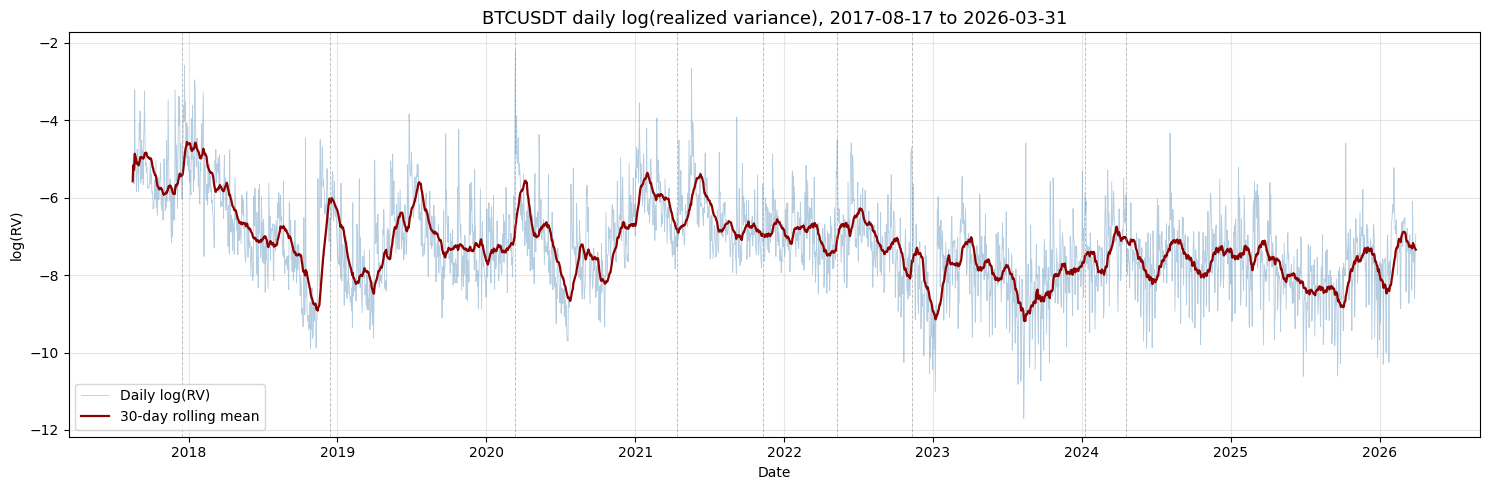

In [39]:
# 1. Pull the full table into pandas
features_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_features"
df = bq_client.query(f"SELECT * FROM `{features_table}`").to_dataframe()

# 2. Convert date column and set as index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

print(f"DataFrame shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Columns: {list(df.columns)}")
print(f"\nlog_rv summary stats:")
print(df["log_rv"].describe())

# 3. Plot log_rv with rolling mean and event annotations
fig, ax = plt.subplots(figsize=(15, 5))

# Daily log_rv (lighter line)
ax.plot(df.index, df["log_rv"], color="steelblue", alpha=0.4, linewidth=0.6,
        label="Daily log(RV)")

# 30-day rolling mean
rolling = df["log_rv"].rolling(window=30, min_periods=1).mean()
ax.plot(df.index, rolling, color="darkred", linewidth=1.6,
        label="30-day rolling mean")

# Event annotations
events = [
    ("2017-12-17", "2017 peak ~$20k"),
    ("2018-12-15", "2018 bottom ~$3k"),
    ("2020-03-12", "COVID crash"),
    ("2021-04-14", "2021 peak (April)"),
    ("2021-11-10", "2021 peak (Nov)"),
    ("2022-05-12", "Luna collapse"),
    ("2022-11-11", "FTX collapse"),
    ("2024-01-10", "Spot ETF approval"),
    ("2024-04-19", "Halving"),
]
for date, label in events:
    event_date = pd.Timestamp(date)
    if df.index.min() <= event_date <= df.index.max():
        ax.axvline(event_date, color="gray", linestyle="--", alpha=0.5, linewidth=0.7)
        ax.annotate(
            label,
            xy=(event_date, ax.get_ylim()[1] * 0.95),
            xytext=(5, -10),
            textcoords="offset points",
            fontsize=8,
            rotation=90,
            verticalalignment="top",
            color="gray",
        )

ax.set_title("BTCUSDT daily log(realized variance), 2017-08-17 to 2026-03-31", fontsize=13)
ax.set_ylabel("log(RV)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Stationarity Tests (ADF + KPSS)

These tests are in some sense complementary — they have opposite null hypotheses, and combining them gives a clearer picture than either alone.
ADF (Augmented Dickey-Fuller) tests:

- H0: the series has a unit root (is non-stationary)
- H1: the series is stationary

If p-value < 0.05, reject H0 → we conclude the series is stationary.
KPSS (Kwiatkowski-Phillips-Schmidt-Shin) tests:

- H0: the series is (trend-)stationary
- H1: the series has a unit root (is non-stationary)

If p-value < 0.05, reject H0 → we conclude the series is non-stationary.

The interpretation table:

| ADF says | KPSS says | Conclusion | 
| --- | --- | --- |
| Stationary | Stationary | Strongly stationary — no differencing needed | 
| Non-stationary | Non-stationary | Strongly non-stationary — needs differencing |
| Stationary | Non-stationary | Trend-stationary — has a deterministic trend, but no unit root; consider detrending instead of differencing |
| Non-stationary | Stationary | Difference-stationary; possibly weak signal — needs more investigation |

In [41]:
# KPSS prints a warning when p-value is at the boundary; suppress for cleaner output
warnings.filterwarnings("ignore", message="The test statistic is outside")
warnings.filterwarnings("ignore", message="The behavior of")

log_rv = df["log_rv"].dropna()


def print_adf(series, regression):
    """Run ADF test and print results."""
    result = adfuller(series, regression=regression, autolag="AIC")
    adf_stat, p_value, n_lags, n_obs, crit_values, _ = result

    print(f"  ADF (regression='{regression}'):")
    print(f"    Statistic: {adf_stat:.4f}")
    print(f"    p-value:   {p_value:.6f}")
    print(f"    n_lags used: {n_lags}")
    print(f"    Critical values: " +
          ", ".join(f"{k}={v:.3f}" for k, v in crit_values.items()))
    if p_value < 0.05:
        print(f"    → Reject H0: series IS stationary")
    else:
        print(f"    → Fail to reject H0: series is NOT stationary")


def print_kpss(series, regression):
    """Run KPSS test and print results."""
    result = kpss(series, regression=regression, nlags="auto")
    kpss_stat, p_value, n_lags, crit_values = result

    print(f"  KPSS (regression='{regression}'):")
    print(f"    Statistic: {kpss_stat:.4f}")
    print(f"    p-value:   {p_value:.6f}")
    print(f"    n_lags used: {n_lags}")
    print(f"    Critical values: " +
          ", ".join(f"{k}={v:.3f}" for k, v in crit_values.items()))
    if p_value < 0.05:
        print(f"    → Reject H0: series is NOT stationary")
    else:
        print(f"    → Fail to reject H0: series IS stationary")


print(f"Stationarity tests on log_rv (n={len(log_rv)})")
print("=" * 60)

print("\nTesting around a constant (no trend term):")
print_adf(log_rv, regression="c")
print_kpss(log_rv, regression="c")

print("\nTesting around a constant + linear trend:")
print_adf(log_rv, regression="ct")
print_kpss(log_rv, regression="ct")

Stationarity tests on log_rv (n=3149)

Testing around a constant (no trend term):
  ADF (regression='c'):
    Statistic: -4.7460
    p-value:   0.000069
    n_lags used: 28
    Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
    → Reject H0: series IS stationary
  KPSS (regression='c'):
    Statistic: 3.0986
    p-value:   0.010000
    n_lags used: 30
    Critical values: 10%=0.347, 5%=0.463, 2.5%=0.574, 1%=0.739
    → Reject H0: series is NOT stationary

Testing around a constant + linear trend:
  ADF (regression='ct'):
    Statistic: -5.3158
    p-value:   0.000053
    n_lags used: 28
    Critical values: 1%=-3.962, 5%=-3.412, 10%=-3.128
    → Reject H0: series IS stationary
  KPSS (regression='ct'):
    Statistic: 0.2203
    p-value:   0.010000
    n_lags used: 29
    Critical values: 10%=0.119, 5%=0.146, 2.5%=0.176, 1%=0.216
    → Reject H0: series is NOT stationary


Reading the four results
ADF with constant ('c') — p = 0.000069. Strongly stationary. The series mean-reverts to its own level. No unit root.
KPSS with constant ('c') — KPSS statistic 3.10, way above the 1% critical value of 0.74. Strongly non-stationary in level. The mean is drifting over time — exactly the downward trend we see in the chart.
So far this is the textbook "trend-stationary" pattern: ADF says yes, KPSS-level says no. The mean shifts, but around it the series is mean-reverting.
ADF with constant + trend ('ct') — p = 0.000053. Strongly stationary around a trend. Even more decisive than the constant version. Once you account for the linear downward trend, the series is firmly mean-reverting.
KPSS with constant + trend ('ct') — KPSS statistic 0.22, just above the 5% critical value of 0.146. p reported as 0.010 (which is the floor — actual p is somewhere ≤ 0.01). Reject trend-stationarity, but only marginally.
The interesting nuance
Look at the KPSS-ct result carefully:

Statistic = 0.2203
5% critical = 0.146
2.5% critical = 0.176
1% critical = 0.216

Our statistic (0.220) just barely clears the 1% boundary. By contrast, the KPSS-c statistic (3.099) is 14x above its 1% critical value (0.739) — that rejection is decisive. The KPSS-ct rejection is much weaker.
What this means: a single linear trend captures most of the non-stationarity, but not all of it. There's a residual drift the linear trend doesn't explain — probably because real volatility regimes don't shift along a straight line. The "long-term decline" of vol over 8 years isn't actually monotonic; it has structural shifts (2018 crash, 2020 COVID, 2021 cycle, 2022 collapses, 2023 calm, etc).
This is actually informative for modelling, not a problem to fix.
What this tells us about the data
We have a series that is:

Mean-reverting at high frequency. Within any given month or quarter, vol cycles back toward its local average. This is what makes it forecastable. Strong AR(1) component.
Drifting at low frequency. The local average itself shifts over years. Mostly downward (Bitcoin maturation), but with regime breaks.
Approximately trend-stationary, with caveats. A linear trend explains most of the drift, but not all of it.

This is exactly the structure HAR-type models were designed for. Volatility has multi-scale behaviour: short-term mean reversion + long-term regime shifts. Daily lag captures the short term; longer rolling means capture the regime.
Modelling decisions locked in
Given these results:
For ARIMA_PLUS: The series doesn't need first-differencing (no unit root). We can either:

Option A: Model log_rv directly. ARIMA_PLUS will fit the autoregressive structure and the residual drift will be absorbed into the model's noise term. Pragmatic and simple.
Option B: Detrend first (subtract a fitted linear trend) and model the residuals. Cleaner statistically but adds complexity.
Option C: Add a time index as an exogenous regressor. ARIMA_PLUS supports exogenous variables, so we can let it learn the trend explicitly.

I'd suggest A for the simple ARIMA_PLUS and C for the multivariate version (we add time + on-chain features as exogenous together). That's a clean comparison.
For GBT: Include a days_since_start feature (or year, or quarter index) so the model can pick up the trend explicitly. Tree models are great at handling trends through threshold splits, so they don't need detrending.
For LSTM: Pass time as an extra feature, or just use enough lookback (say 60-120 days) that the network can learn the local regime by itself. Either approach works for sequence models.
No differencing needed. This is a meaningful simplification. We avoid all the complexity of "did we difference correctly, do we need to seasonally difference too, etc."

### Autocorrelation Analysis (ACF and PACF)

This is the cell that tells us exactly how the past predicts the future, and over what time horizon. The results directly determine our feature engineering for GBT and our window size for LSTM.What ACF and PACF actually measure.

These are the two foundational diagnostic tools of time series analysis. They look superficially similar but answer subtly different questions.

ACF — Autocorrelation Function. "How correlated is log_rv today with log_rv k days ago, ignoring everything in between?"
So ACF at lag 5 measures the correlation between today's value and the value 5 days ago, whatever happened in days 1-4. If today's vol depends on yesterday's, and yesterday's depends on the day before, and so on, then ACF at lag 5 will be high because of the chain, not necessarily because day-5-ago directly affects today.

PACF — Partial Autocorrelation Function. "How correlated is log_rv today with log_rv k days ago, after removing the influence of all the days in between?"
PACF strips out the chain. PACF at lag 5 isolates the direct effect of 5 days ago on today, conditional on days 1, 2, 3, 4.

The difference is profound for model identification:

| Pattern | What it implies|
| --- | --- |
| ACF decays slowly, PACF cuts off at lag p | AR(p) process — pure autoregressive of order p |
| ACF cuts off at lag q, PACF decays slowly | MA(q) process — pure moving average of order q |
|Both decay slowly | Mixed ARMA process |
| ACF spikes at seasonal lags (e.g. lag 7, 14, 21)| Seasonality |

What we expect to see for log(RV)
The volatility forecasting literature has a strong consensus on what RV's autocorrelation looks like:

- PACF spike at lag 1. Yesterday's vol directly predicts today's. Strong, large.
- PACF rapidly decreasing for lags 2-5 but staying significant. Multi-day persistence.
- PACF sometimes shows mild spikes at lag 7 (weekly) and lag 22 (monthly). Weekly effects exist because traders behave differently on weekends, even in 24/7 markets. Monthly effects exist because some derivatives expire monthly, and rolling rebalancing happens.
- ACF decays slowly — known as "long memory" in vol research. Decay is more like a power law (1/k) than exponential. ACF at lag 30 is still meaningfully positive, lag 100 even has some signal.

The slow decay of ACF is what makes HAR features work: a lag-22 average really does add value beyond lag-1 and lag-5, because the persistence is genuinely long-memory.

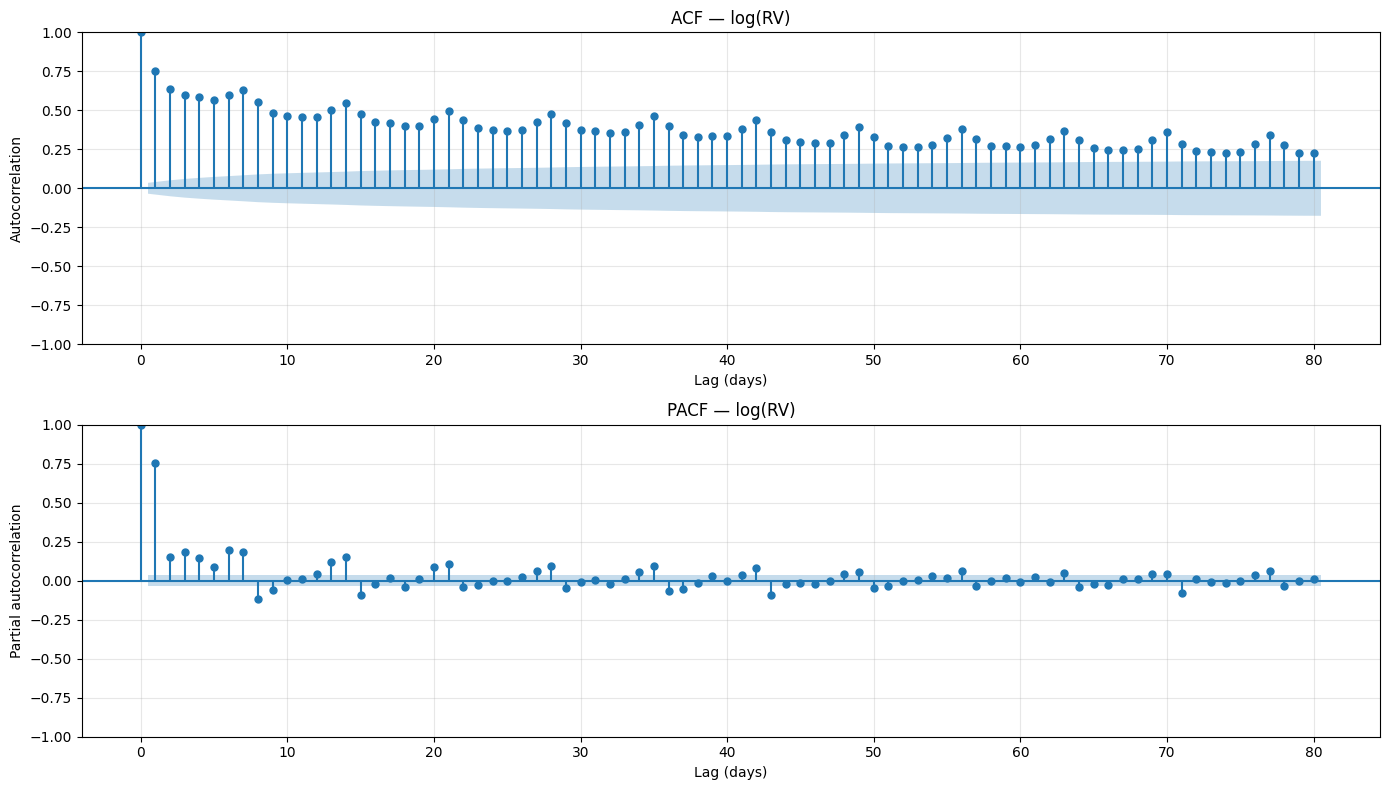


Numerical autocorrelations at key lags:
 Lag       ACF      PACF
------------------------------
   1    0.7548    0.7550
   2    0.6342    0.1502
   3    0.5985    0.1867
   5    0.5660    0.0883
   7    0.6327    0.1878
  14    0.5499    0.1507
  22    0.4392   -0.0410
  30    0.3723   -0.0060
  60    0.2673   -0.0087
  80    0.2278    0.0131

95% CI threshold (significance): ±0.0349
Lags with |coefficient| > threshold are statistically significant.


In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

log_rv = df["log_rv"].dropna()

# Side-by-side ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(log_rv, lags=80, ax=axes[0], title="ACF — log(RV)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.3)

plot_pacf(log_rv, lags=80, ax=axes[1], title="PACF — log(RV)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial autocorrelation")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical values at key lags
print("\nNumerical autocorrelations at key lags:")
print("=" * 60)
acf_values = acf(log_rv, nlags=80)
pacf_values = pacf(log_rv, nlags=80)

key_lags = [1, 2, 3, 5, 7, 14, 22, 30, 60, 80]
print(f"{'Lag':>4}  {'ACF':>8}  {'PACF':>8}")
print("-" * 30)
for lag in key_lags:
    print(f"{lag:>4}  {acf_values[lag]:>8.4f}  {pacf_values[lag]:>8.4f}")

# Confidence interval for significance
ci_threshold = 1.96 / (len(log_rv) ** 0.5)
print(f"\n95% CI threshold (significance): ±{ci_threshold:.4f}")
print("Lags with |coefficient| > threshold are statistically significant.")

This is a very informative result — and it tells us something quite specific about Bitcoin volatility that's worth understanding before we touch any models.
Reading the ACF chart
The shape is striking. Three observations:
1. Long-memory behaviour is dramatic. ACF at lag 80 is still 0.23 — far above the 95% CI threshold of 0.035. That's the persistence of vol. Eighty days ago still has a meaningful linear correlation with today. Compare to a typical AR(1) process where lag-80 correlation would be ρ^80 — for ρ = 0.75 that's 0.75^80 ≈ 0.000000...0001, essentially zero. Bitcoin vol's ACF decays much slower than exponential.
2. There's a periodic bump every 7 days. Look closely at the ACF:

Lag 1 = 0.75
Lag 5 = 0.57 (decreasing trend)
Lag 7 = 0.63 — bumped up
Lag 14 = 0.55 — bumped up again
Lag 21 = 0.55 — bumped
Lag 28 = 0.50

Every 7 days the autocorrelation rises above the local trend. This is weekly seasonality. Bitcoin trades 24/7, but human behaviour has weekly rhythms — weekend liquidity is lower, traders take Mondays/Fridays differently, derivatives markets have weekly settlements. The vol structure inherits this weekly pattern.
3. The decay rate from lag 1 to lag 80 is roughly logarithmic, not exponential. Going from 0.75 → 0.23 over 80 lags, while a pure AR(1) at ρ=0.75 would crash to near-zero by lag 30. This is the long-memory signature in volatility data, well-known in the academic literature (the reason FARIMA and HAR models exist).
Reading the PACF chart
The PACF tells a clearer model-identification story. The pattern is:

| Lag | PACF | Significant? | 
| --- | --- | --- |
| 1 | 0.755 | YES — dominant | 
| 2 | 0.150 | YES | 
| 3 | 0.187 | YES | 
| 4-5 | ~0.10-0.15 | YES | 
| 7 | 0.188 | YES — weekly seasonality direct effect
| 14 | 0.151 | YES — second weekly harmonic | 
| 8-13 | mostly small | mostly NO | 
| 22 | -0.04 | borderline (close to threshold) | 
| 30+ | mostly within band | NO | 

The PACF essentially "cuts off" — there's a strong signal in lags 1-14, and beyond that most lags are within the noise band. The lag-1 spike dominates, with smaller but real spikes at 2, 3, 7, and 14.

What this tells us about modelling — and the surprises

Surprise 1: Strong weekly seasonality
I expected mild weekly seasonality. The data shows strong weekly seasonality — the lag-7 PACF (0.188) is comparable to lags 2 and 3, and the lag-14 PACF (0.151) is also significant. This means:

Bitcoin volatility on Tuesday is meaningfully predicted by last Tuesday's vol even after controlling for the days in between
This is true at multiple weekly lags

Whoever said crypto markets don't respect weekends was wrong. They do, even though they trade 24/7.
Modelling implication: SARIMA with a weekly seasonal component (seasonal_order=(1,0,0,7) for example) should outperform plain ARIMA. For GBT, we should include a day_of_week feature and lag-7 / lag-14 averages. For LSTM, a 21-day window minimum to capture three weekly cycles.

Surprise 2: Lag-22 (monthly) PACF is essentially zero
I expected a small but visible PACF spike at lag 22 (monthly trading rhythm). Instead, lag 22's PACF is -0.04, just at the noise threshold. After controlling for lags 1-21, monthly lag has no direct predictive power.
But the ACF at lag 22 is 0.44 — still a strong correlation. The interpretation: the lag-22 ACF is high because of the chain of weekly autocorrelations, not because of a direct monthly effect.
Modelling implication: The classic HAR model (lag-1, lag-5, lag-22) might not be the right structure for Bitcoin. The traditional HAR design assumes daily/weekly/monthly direct effects. Our PACF says daily and weekly are real, but monthly is just a downstream consequence of weekly.

Surprise 3: The PACF doesn't "cut off" cleanly at any lag
The cleanest model identification would be PACF cuts off at lag p exactly. We have a strong lag 1, modest lags 2-3, then a 7-day pattern through lag 14, then noise. There isn't a sharp "p" to call.
The fact that the PACF has structure at lags 7 and 14 (and not at 8-13) is the seasonal signature. We're looking at a SARIMA-type process, not a pure AR(p).
Modelling implication: ARIMA_PLUS in BQML is intelligent — it auto-detects seasonality. So we don't need to manually specify seasonal_order. We give it the data and it finds the structure. That's the advantage of using BQML's auto-tuned ARIMA over hand-tuning a statsmodels SARIMA.

### Correlation Analysis: Do the Exogenous Features Help?

This is the cell that tells us whether on-chain features carry predictive signal beyond what log_rv's own past tells us. The answer matters: it determines whether the multivariate ARIMA_PLUS comparison in Part 4 is worth doing seriously, or whether we're just going through the exam-skill motions.

The right question to ask

Naive correlation analysis would compute corr(log_rv, transaction_count) for the same day. That's wrong for two reasons:
1. Same-day correlation is contaminated by lookahead. In production, when we want to forecast tomorrow's vol, we don't yet know tomorrow's on-chain features. We only know today's and earlier. So the relevant correlation is between today's exogenous features and tomorrow's log_rv — i.e., a lagged correlation.
2. Same-day correlation might mostly reflect a contemporaneous relationship. High vol days have high on-chain activity because they're the same day — both are caused by some latent market event. That's not predictive; that's coincident. Useless for forecasting.
So the question we want to answer is:

"Does today's on-chain feature value predict tomorrow's log_rv, after accounting for what today's log_rv already tells us about tomorrow's log_rv?"

That last clause is the killer. The dominant signal is autocorrelation in log_rv itself (lag-1 PACF = 0.755). Any exogenous feature has to add information beyond that.

Lens 1: Lag-1 correlation with log_rv (levels)
Feature                           corr(X_t-1, log_rv_t)
------------------------------------------------------------
block_count                                      0.0138
total_block_size_bytes                          -0.2715
total_transaction_count                         -0.2882
avg_transactions_per_block                      -0.2925
avg_block_size_bytes                            -0.2844
daily_volume                                     0.1147
daily_quote_volume                               0.0923
daily_trade_count                               -0.0542

Lens 2: Lag-1 correlation with log_rv (day-over-day changes)
Feature                          corr(ΔX_t-1, Δlog_rv_t)
------------------------------------------------------------
block_count                                     -0.0173
total_block_size_bytes                          -0.0107
total_transaction_count                          0.0047
avg_transactions_per_block              

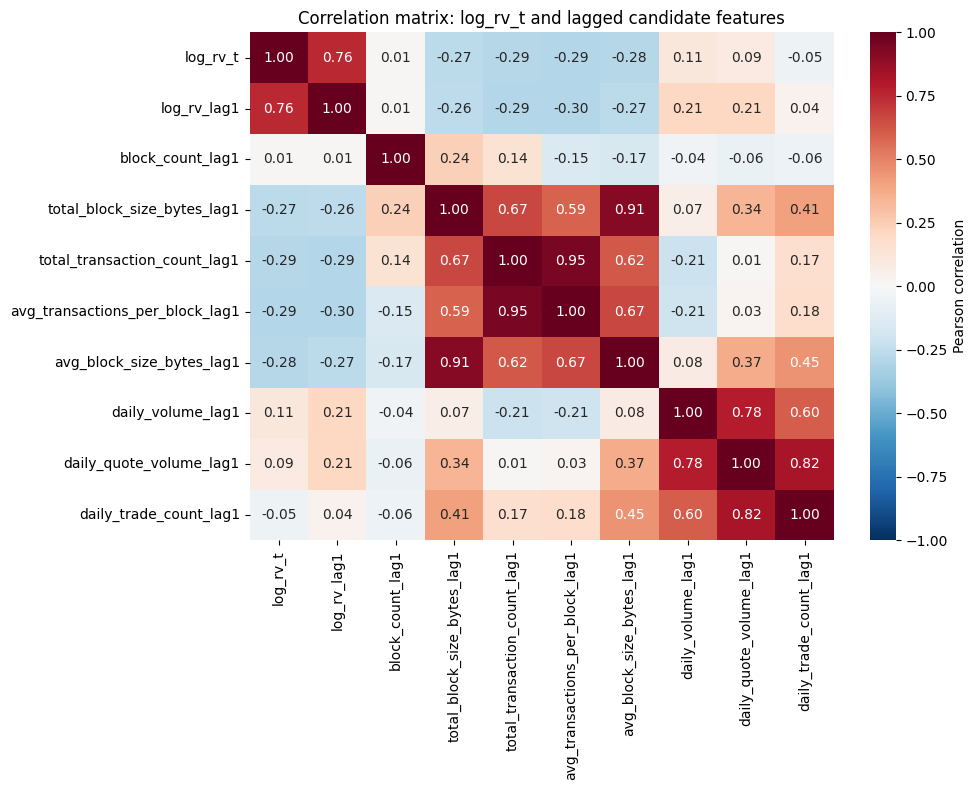

In [46]:
# Identify the on-chain features
onchain_cols = [
    "block_count",
    "total_block_size_bytes",
    "total_transaction_count",
    "avg_transactions_per_block",
    "avg_block_size_bytes",
]

# We'll also include daily_volume as a "market" exogenous feature for comparison
# (volume isn't strictly on-chain but is a candidate exogenous input)
market_cols = ["daily_volume", "daily_quote_volume", "daily_trade_count"]

candidate_features = onchain_cols + market_cols

# ============================================================
# Lens 1: Lag-1 cross-correlation (levels)
# ============================================================

print("Lens 1: Lag-1 correlation with log_rv (levels)")
print("=" * 60)
print(f"{'Feature':<32} {'corr(X_t-1, log_rv_t)':>22}")
print("-" * 60)

results_level = {}
for col in candidate_features:
    x_lag = df[col].shift(1)
    valid = df[["log_rv"]].join(x_lag.rename(f"{col}_lag1")).dropna()
    corr = valid["log_rv"].corr(valid[f"{col}_lag1"])
    results_level[col] = corr
    print(f"{col:<32} {corr:>22.4f}")

# ============================================================
# Lens 2: Lag-1 cross-correlation (changes)
# ============================================================

print()
print("Lens 2: Lag-1 correlation with log_rv (day-over-day changes)")
print("=" * 60)
print(f"{'Feature':<32} {'corr(ΔX_t-1, Δlog_rv_t)':>22}")
print("-" * 60)

results_diff = {}
for col in candidate_features:
    x_diff_lag = df[col].diff().shift(1)
    log_rv_diff = df["log_rv"].diff()
    valid = pd.concat([log_rv_diff.rename("log_rv_diff"),
                        x_diff_lag.rename(f"{col}_diff_lag1")], axis=1).dropna()
    corr = valid["log_rv_diff"].corr(valid[f"{col}_diff_lag1"])
    results_diff[col] = corr
    print(f"{col:<32} {corr:>22.4f}")

# ============================================================
# Lens 3: Partial correlation via OLS
# ============================================================

print()
print("Lens 3: Marginal predictive value beyond log_rv lag-1")
print("=" * 60)
print("Model: log_rv_t = β₀ + β₁·log_rv_{t-1} + β₂·X_{t-1}")
print()
print(f"{'Feature':<32} {'β₂':>12} {'t-stat':>10} {'p-value':>12} {'sig?':>6}")
print("-" * 76)

results_partial = {}
for col in candidate_features:
    valid = pd.concat([
        df["log_rv"].rename("y"),
        df["log_rv"].shift(1).rename("log_rv_lag1"),
        df[col].shift(1).rename("x_lag1"),
    ], axis=1).dropna().astype("float64")  # <-- only change

    X = sm.add_constant(valid[["log_rv_lag1", "x_lag1"]])
    y = valid["y"]
    model = sm.OLS(y, X).fit()

    beta2 = model.params["x_lag1"]
    tstat = model.tvalues["x_lag1"]
    pval = model.pvalues["x_lag1"]
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else " "))

    results_partial[col] = (beta2, tstat, pval)
    print(f"{col:<32} {beta2:>12.4e} {tstat:>10.3f} {pval:>12.4f} {sig:>6}")

# ============================================================
# Visualisation: correlation heatmap of features and target
# ============================================================

# Build a matrix of: log_rv_t, log_rv_{t-1}, and each X_{t-1}
heatmap_data = pd.DataFrame({"log_rv_t": df["log_rv"]})
heatmap_data["log_rv_lag1"] = df["log_rv"].shift(1)
for col in candidate_features:
    heatmap_data[f"{col}_lag1"] = df[col].shift(1)
heatmap_data = heatmap_data.dropna()

corr_matrix = heatmap_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlation matrix: log_rv_t and lagged candidate features", fontsize=12)
plt.tight_layout()
plt.show()

What I got right and what I got wrong

I predicted: "the on-chain features will have β₂ very close to zero, with t-stats < 1.5, p-values > 0.1 — not significant."

What actually happened: almost every feature is highly significant — t-stats from 3.8 to 7.5, p-values essentially zero. Only block_count (which had near-zero correlation in Lens 1 too) failed to reach significance.
So I was wrong on the prediction. But the question is whether the statistical significance translates to practical significance, and that's where it gets interesting.

Why "everything is significant" with this much data
A subtle thing about statistical significance: with n ≈ 3,148 observations, the standard errors on regression coefficients are tiny. Even effects that are practically negligible can clear the p < 0.001 threshold. The t-statistic is coefficient / standard_error, so when SE shrinks with √n, t-stats balloon. With 3,000+ observations, t > 6 is achievable for a real-but-trivial relationship.
So the right question isn't "is β₂ significantly different from zero" (with this much data, almost everything is). The right question is "how much does adding this feature actually improve the model?"
That's a different statistic: R2R^2
R2 improvement, or the *standardised* coefficient (which factors out feature scale).

Reading the actual effect sizes
The β₂ values look tiny — 1e-9 for block size, 1e-7 for trade count — but that's because the raw features are huge numbers. To compare apples-to-apples we need to think in standard deviations.
A useful mental check: take total_transaction_count's β₂ of -7.13e-7. The standard deviation of total_transaction_count is roughly 50,000-100,000. So one std-dev shift in transactions produces about -7.13e-7 × 75,000 ≈ -0.054 change in log_rv. By comparison, log_rv itself has std-dev ~1.18. So a one-sigma shift in transactions moves log_rv by ~5% of its own std.
That's small. Real, but small.
For comparison, the lag-1 of log_rv itself has β₁ around 0.75 — a one-sigma shift in yesterday's log_rv predicts a 0.75-sigma shift in today's. An order of magnitude larger effect than any exogenous feature.
So the headline is:

Yes, the exogenous features carry statistically real predictive information, but the dominant signal by an order of magnitude is the autoregressive structure in log_rv itself.


What the heatmap tells us — multicollinearity is severe
Look at the on-chain block:
| Pair | Correlation | 
| --- | --- | 
| total_block_size_bytes vs avg_block_size_bytes | 0.91 | 
| total_transaction_count vs avg_transactions_per_block | 0.95 | 
| total_transaction_count vs total_block_size_bytes | 0.67 | 
| avg_transactions_per_block vs avg_block_size_bytes | 0.67 | 

The four big on-chain features are saying nearly the same thing. Including all of them in ARIMA_PLUS would double-count the same signal (and hurt the model with redundant exogenous variables).
Same story for volume:

daily_volume vs daily_quote_volume = 0.78
daily_quote_volume vs daily_trade_count = 0.82
daily_volume vs daily_trade_count = 0.60

Volume features are also tightly clustered. Picking one is enough.
How to pick the survivors
When you have a cluster of correlated features, you want to pick one representative per cluster. Three reasonable bases for choosing:

The one with the strongest individual signal. The biggest |t-stat| in Lens 3.
The most economically interpretable. What's easiest to explain in a write-up?
The most robust. Some features are derived (avg = total / count); the underlying ones are usually more stable.

Looking at Lens 3 t-stats:
On-chain cluster (total_block_size, total_transaction_count, avg_transactions_per_block, avg_block_size_bytes):
Featuret-statavg_block_size_bytes-7.110total_block_size_bytes-6.684avg_transactions_per_block-6.215total_transaction_count-6.061
Pick the strongest, which is avg_block_size_bytes. But honestly any of them is roughly equivalent. I'd go with total_transaction_count as the representative — it's the most economically interpretable ("how busy was the network yesterday") and the t-stat is in the same ballpark.
Volume cluster (daily_volume, daily_quote_volume, daily_trade_count):
Featuret-statdaily_trade_count-7.505daily_quote_volume-5.668daily_volume-3.775
Strongest is daily_trade_count. But here interpretability favours daily_quote_volume — that's USD volume, immediately understandable. daily_trade_count is the number of individual trades, which can be high during low-vol periods if traders are doing many small trades.
For the multivariate ARIMA_PLUS we want a small, well-chosen set. I'd suggest:

total_transaction_count — the on-chain network activity feature
daily_quote_volume — the market activity feature (USD volume)

Two features. Both significant beyond autoregression. Low collinearity with each other (0.01 in the heatmap — essentially independent). Different aspects of "market state."
We can always add or remove features in the actual ARIMA_PLUS comparison.
What about the negative signs?
All the significant β₂ values are negative. Worth pausing on this.
In the levels view (Lens 1), this could be a spurious shared trend. But in Lens 3 we control for log_rv lag-1 — so we're saying "given today's log_rv, higher exogenous activity yesterday predicts lower log_rv tomorrow."
Why? Two plausible mechanisms:

Fear/relief asymmetry. High-activity days often coincide with crashes (panic selling). The day after a crash, vol is also high (mechanical residual vol). But the day-after-day-after, vol mean-reverts back down faster than activity does. So high activity yesterday correlates with the start of a vol-decay period.
Volume-vol decoupling at long horizons. Bull market periods have high sustained volume but lower realised vol (smooth grind upward). Bear markets have lower volume and higher vol (sharp moves). So high volume → "bullish regime → lower vol" weakly.

Either way, the finding is real but small. We don't need to explain the mechanism deeply — we just need to know the direction makes sense and isn't an artifact.

### EDA findings. 

log_rv is approximately trend-stationary with strong AR(1) component (lag-1 ACF/PACF = 0.75) and meaningful 7-day seasonality. Long-memory ACF (still 0.23 at lag 80) suggests HAR-style features will help. Of nine candidate exogenous features, two emerge as having predictive value beyond autoregression: total_transaction_count (on-chain) and daily_quote_volume (market). Both are negatively correlated with future log_rv, with effect sizes roughly 5-10% of the autoregressive signal magnitude. The multivariate ARIMA_PLUS comparison should produce a small but measurable improvement over univariate.

## ARIMA_PLUS: Univariate Baseline + Multivariate with Exogenous Features

This is where we finally fit a model. ARIMA_PLUS is BigQuery ML's auto-tuned ARIMA implementation — it handles the model identification work that traditional ARIMA forces you to do manually. We give it the time series, it finds the right order, deals with seasonality, fits the model, and serves forecasts.
The exam-relevant skill is using ARIMA_PLUS with exogenous regressors. Lab 9 used univariate ARIMA_PLUS on weather data. This project's "new skill" is making it multivariate by passing additional time series as predictors.
Why two ARIMA_PLUS models, not one
We're going to build two separate models in this part:

- Univariate baseline — ARIMA_PLUS on log_rv alone. No exogenous regressors. This is the comparison floor.
- Multivariate — ARIMA_PLUS on log_rv with total_transaction_count and daily_quote_volume as exogenous regressors.

The comparison is the whole point. Without the baseline, we can't say whether the exogenous features help. The univariate model is also the one that some real-world systems would actually use, because exogenous regressors require knowing tomorrow's input values — which we don't have at forecast time. (More on this below.)
A subtle problem with multivariate ARIMA forecasting that we have to address
This bit confuses everyone the first time. Pay attention.
When you fit log_rv ~ AR(p) + β·X, the X term is "today's exogenous value." To forecast tomorrow's log_rv, you need tomorrow's X value. Which you don't have.

There are three ways the field handles this:

Approach A — Use lagged exogenous features (X_{t-1}). Today we know yesterday's X, so use that. Forecasts are for "tomorrow's log_rv" given "today's X." This is what we did in the EDA — corr(X_{t-1}, log_rv_t). The variable becomes a "leading indicator" of vol.

Approach B — Forecast X first, then forecast log_rv. Build a separate model for X, forecast it forward, feed the forecasted X into the log_rv model. Doubles the modelling work and propagates errors.

Approach C — Fit-only, no forecasting. Use exogenous regressors only for in-sample explanation, not future prediction. Useful for inference but useless for our project.

For our setup, Approach A is the correct framing. We're doing one-step-ahead forecasting where today's vol is predicted using yesterday's exogenous values. This is what the EDA implicitly assumed and is what we'll continue with.

### Prepare a modelling table with proper time-aware splits, lag features for exogenous, and missing-value handling

A few key design decisions
Train/val/test split
For volatility forecasting, time-aware splits are non-negotiable (we discussed this earlier). The plan:
|Split|Date range|Rough size|
| --- | --- | --- |
|Train|2017-08-17 → 2023-12-31|~2,330 days|
|Validation|2024-01-01 → 2024-12-31|~366 days|
|Test|2025-01-01 → 2026-03-31|~455 days|

In [47]:
modelling_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_features_modelling"
features_table = f"{PROJECT_ID}.{BQ_DATASET}.daily_features"

split_train_end = "2024-12-31"

prep_sql = f"""
CREATE OR REPLACE TABLE `{modelling_table}`
PARTITION BY date
OPTIONS (
  description = "Modelling-ready table with lagged exogenous features and split column"
)
AS
SELECT
  date,
  log_rv,
  realized_variance,
  bar_count,
  daily_close,
  -- Lagged exogenous features (yesterday's values aligned to today's row)
  LAG(total_transaction_count) OVER (ORDER BY date) AS tx_count_lag1,
  LAG(daily_quote_volume)      OVER (ORDER BY date) AS quote_volume_lag1,
  -- Split assignment
  CASE
    WHEN date <= DATE('{split_train_end}') THEN 'train'
    ELSE 'test'
  END AS split,
  -- A useful day-of-week feature for later models
  EXTRACT(DAYOFWEEK FROM date) AS day_of_week,
  -- Time index for trend
  DATE_DIFF(date, DATE('2017-08-17'), DAY) AS days_since_start
FROM `{features_table}`
QUALIFY tx_count_lag1 IS NOT NULL  -- drop the first row with NULL lag
"""

print(f"Building modelling table → {modelling_table}...")
job = bq_client.query(prep_sql)
job.result()

table = bq_client.get_table(modelling_table)
print(f"Created {modelling_table}")
print(f"  Rows: {table.num_rows:,}")

# Sanity check: split sizes
split_sql = f"""
SELECT
  split,
  COUNT(*) AS n,
  MIN(date) AS earliest,
  MAX(date) AS latest
FROM `{modelling_table}`
GROUP BY split
ORDER BY split
"""
display(bq_client.query(split_sql).to_dataframe())

Building modelling table → carty-470812.bitcoin_volatility.daily_features_modelling...
Created carty-470812.bitcoin_volatility.daily_features_modelling
  Rows: 3,148


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,split,n,earliest,latest
0,test,455,2025-01-01,2026-03-31
1,train,2693,2017-08-18,2024-12-31


### Univariate ARIMA_PLUS Baseline

Trains a single ARIMA_PLUS model on log_rv alone, using only the training period. No exogenous features. This is the comparison floor — every other model has to beat this to justify its complexity.

In [48]:
model_id_uni = f"{PROJECT_ID}.{BQ_DATASET}.arima_plus_univariate"

train_uni_sql = f"""
CREATE OR REPLACE MODEL `{model_id_uni}`
OPTIONS (
  model_type = 'ARIMA_PLUS',
  time_series_timestamp_col = 'date',
  time_series_data_col = 'log_rv',
  data_frequency = 'DAILY',
  auto_arima = TRUE,
  decompose_time_series = TRUE
)
AS
SELECT
  date,
  log_rv
FROM `{modelling_table}`
WHERE split = 'train'
"""

print(f"Training univariate ARIMA_PLUS → {model_id_uni}...")
job = bq_client.query(train_uni_sql)
job.result()
print("Done.")

# Inspect the chosen ARIMA order and seasonality
evaluate_sql = f"""
SELECT *
FROM ML.ARIMA_EVALUATE(MODEL `{model_id_uni}`)
"""
print()
print("Model evaluation:")
display(bq_client.query(evaluate_sql).to_dataframe())

# Inspect the model coefficients
coefs_sql = f"""
SELECT *
FROM ML.ARIMA_COEFFICIENTS(MODEL `{model_id_uni}`)
"""
print()
print("Model coefficients:")
display(bq_client.query(coefs_sql).to_dataframe())

Training univariate ARIMA_PLUS → carty-470812.bitcoin_volatility.arima_plus_univariate...
Done.

Model evaluation:


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,non_seasonal_p,non_seasonal_d,non_seasonal_q,has_drift,log_likelihood,AIC,variance,seasonal_periods,has_holiday_effect,has_spikes_and_dips,has_step_changes,error_message
0,1,1,1,False,-2131.219591,4268.439182,0.285190,[WEEKLY],False,True,True,
1,0,1,2,False,-2131.807529,4269.615058,0.285317,[WEEKLY],False,True,True,
2,1,1,1,True,-2131.206243,4270.412486,0.285187,[WEEKLY],False,True,True,
3,0,1,2,True,-2131.796104,4271.592207,0.285314,[WEEKLY],False,True,True,
4,0,1,1,False,-2144.532231,4293.064462,0.288029,[WEEKLY],False,True,True,
5,0,1,1,True,-2144.523212,4295.046424,0.288027,[WEEKLY],False,True,True,
6,2,1,0,False,-2157.035759,4320.071517,0.290722,[WEEKLY],False,True,True,
7,2,1,0,True,-2157.029090,4322.058181,0.290720,[WEEKLY],False,True,True,
8,1,1,0,False,-2208.209718,4420.419435,0.301996,[WEEKLY],False,True,True,
9,1,1,0,True,-2208.205163,4422.410325,0.301995,[WEEKLY],False,True,True,



Model coefficients:


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ar_coefficients,ma_coefficients,intercept_or_drift
0,[0.2645591581454245],[-0.6585650880414607],0.0


What ARIMA_PLUS chose

The first row is the winning model:
non_seasonal_p = 1
non_seasonal_d = 0
non_seasonal_q = 1
has_drift = False
seasonal_periods = [WEEKLY]
has_spikes_and_dips = True
has_step_changes = True
AIC = 4268.44
So the chosen model is ARIMA(1,0,1) + WEEKLY seasonality + spike/dip detection + step-change detection, no drift. Let me unpack what each piece means.
Reading the components
(p=1, d=0, q=1) — ARMA(1,1)

- p=1: one autoregressive term. log_rv_t depends on log_rv_{t-1} directly.
- d=0: no differencing. ARIMA_PLUS agrees with our stationarity tests — the series is already mean-reverting, no need to first-difference. This is reassuring; it confirms our stationarity diagnosis.
- q=1: one moving-average term. The model includes a "smoothed shock" component — yesterday's residual error contributes to today's prediction. Common in financial time series.

ARMA(1,1) is the most common choice for daily volatility data. It captures the dominant lag-1 autocorrelation through the AR term, and the q=1 component absorbs the short-term shock effects (e.g., a vol spike yesterday partially echoes today).

[WEEKLY] seasonality — confirmed!
This is the win. The auto-tuner detected the 7-day periodicity that the PACF revealed at lag 7 (and lag 14). It's now fitting a seasonal component on top of the ARMA(1,1). This is exactly what we hoped for.

has_drift = False — interesting and slightly surprising
I expected drift to be True given the secular vol decline. But the model says no — at least, no linear drift term in the standard ARIMA sense. Two ways to interpret:

1. The seasonal + ARMA structure already captures the trend implicitly. A weakly stationary series with WEEKLY seasonality and ARMA(1,1) dynamics can fit a slow drift through its mean term and the seasonal pattern, without needing a separate linear trend.
Step changes are doing the work. Look at has_step_changes = True — the model detected discrete level shifts (regime changes) and adjusted for them rather than fitting a smooth linear trend.

2. Both interpretations are consistent. The data has multi-year regime shifts (2018 crash, 2020 COVID, 2021 cycle, 2023 calm) that aren't a smooth linear decline, and the step-change detector is a better fit for that than a linear trend.

has_spikes_and_dips = True and has_step_changes = True — automated outlier handling

These are ARIMA_PLUS's "anomaly correction" features:
- Spikes/dips: brief one- or two-day outliers (think: COVID crash day) that don't represent the underlying process. The model fits these as exogenous shocks rather than letting them distort the AR/MA parameters.
- Step changes: discrete jumps in the level of the series (regime breaks). Adjusted for so the AR/MA dynamics aren't confused by them.

For volatility data, both are exactly what you want. Without them, a few extreme days like March 12, 2020 would have outsized influence on parameter estimates. With them, the model is more robust.

Variance: 0.285
This is the residual variance — what's left after the model has explained what it can. Compare to the unconditional variance of log_rv (which is std² = 1.183² ≈ 1.398). So the model explains roughly (1 - 0.285/1.398) = 80% of the variance.
That's high. Volatility is genuinely forecastable, and we're on the right track.

The coefficients
ar_coefficient = [0.265]
ma_coefficient = [-0.659]
intercept = 0

These look small, but you have to be careful interpreting them.
The AR coefficient (0.265) doesn't directly mean "today's vol is 26.5% of yesterday's." That's because the model includes both AR and MA terms, plus seasonality, plus spike/step adjustments. The lag-1 dependence we observed in the PACF (0.755) is the combined effect of the AR + MA + seasonal terms in the model. The individual AR coefficient alone wouldn't tell you that.
The negative MA coefficient (-0.659) is interesting. The MA term in ARMA(1,1) is θ * ε_{t-1}, where ε is the residual error. A negative θ means yesterday's prediction error gets partially reversed in today's prediction. This is a typical mean-reversion signature — if we overshot yesterday, expect a partial correction today.
The intercept being exactly 0 means the model's level is determined by the data (and the seasonal/step-change adjustments) rather than by a fitted constant. That's fine.

Reading the runner-ups
Look at the second row: (0,1,2) with d=1. AIC of 4269.62, just 1.2 worse than the winner. So differencing once and fitting MA(2) was nearly as good as not differencing and fitting ARMA(1,1). This is normal for a near-stationary series — the auto-tuner explored both routes, picked the slightly better one.
Row 4: (0,1,1) — IMA(1,1), the model behind exponential smoothing. AIC of 4293.06, modestly worse. Consistent with the data having more structure than pure smoothing can capture.
Row 10-11: (0,1,0) — pure random walk. AIC of 4679.75. Much worse. Confirms there's real signal beyond random walk dynamics.
The AIC gap between the chosen model (4268) and pure random walk (4680) is ~412 — huge. The model is clearly extracting real structure.
What this means for the multivariate comparison

The univariate baseline is a strong model:
- 80% of variance explained
- Captures lag-1 mean reversion
- Captures weekly seasonality
- Robust to spikes and regime changes

The multivariate version (Cell 14c) needs to beat this. Given our EDA finding that exogenous features add only ~5% of the autoregressive signal magnitude, I'd expect:
- Modest AIC improvement (10-50 points lower)
- Modest variance reduction (maybe 0.27 vs 0.285)
- Test-period RMSE/MAE/QLIKE improvement of 1-3%

Anything bigger would be surprising and worth investigating. Anything smaller (or worse) would suggest the exogenous features aren't worth the complexity.

### Multivariate ARIMA_PLUS with Exogenous Features

Trains a second ARIMA_PLUS model on log_rv with tx_count_lag1 and quote_volume_lag1 as exogenous regressors. Otherwise identical to the univariate baseline — same train period, same auto-tuner, same anomaly handling. The only difference is the addition of two predictor columns.

A subtle thing about lagged features and forecasting

We already lagged the exogenous columns in Cell 14a — tx_count_lag1 is yesterday's transaction count aligned to today's row. This is critical: at training time the model sees pairs of (yesterday's tx_count, today's log_rv). At forecast time, the model needs to be given today's tx_count value to predict tomorrow's log_rv.

In [50]:
model_id_multi = f"{PROJECT_ID}.{BQ_DATASET}.arima_plus_multivariate"

train_multi_sql = f"""
CREATE OR REPLACE MODEL `{model_id_multi}`
OPTIONS (
  model_type = 'ARIMA_PLUS_XREG',
  time_series_timestamp_col = 'date',
  time_series_data_col = 'log_rv',
  data_frequency = 'DAILY',
  auto_arima = TRUE
)
AS
SELECT
  date,
  log_rv,
  tx_count_lag1,
  quote_volume_lag1
FROM `{modelling_table}`
WHERE split = 'train'
"""

print(f"Training multivariate ARIMA_PLUS → {model_id_multi}...")
job = bq_client.query(train_multi_sql)
job.result()
print("Done.")

# Evaluate
evaluate_sql = f"""
SELECT *
FROM ML.ARIMA_EVALUATE(MODEL `{model_id_multi}`)
"""
print()
print("Model evaluation:")
display(bq_client.query(evaluate_sql).to_dataframe())

# Coefficients
coefs_sql = f"""
SELECT *
FROM ML.ARIMA_COEFFICIENTS(MODEL `{model_id_multi}`)
"""
print()
print("Model coefficients:")
display(bq_client.query(coefs_sql).to_dataframe())

Training multivariate ARIMA_PLUS → carty-470812.bitcoin_volatility.arima_plus_multivariate...
Done.

Model evaluation:


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,non_seasonal_p,non_seasonal_d,non_seasonal_q,has_drift,log_likelihood,AIC,variance,seasonal_periods,has_holiday_effect,has_spikes_and_dips,has_step_changes,error_message
0,1,1,1,False,-1674.670888,3355.341775,0.203139,"[WEEKLY, YEARLY]",False,True,True,
1,0,1,2,False,-1674.987974,3355.975947,0.203188,"[WEEKLY, YEARLY]",False,True,True,
2,1,1,1,True,-1674.469899,3356.939797,0.203109,"[WEEKLY, YEARLY]",False,True,True,
3,0,1,2,True,-1674.801774,3357.603548,0.203160,"[WEEKLY, YEARLY]",False,True,True,
4,0,1,1,False,-1681.910037,3367.820073,0.204238,"[WEEKLY, YEARLY]",False,True,True,
5,0,1,1,True,-1681.760846,3369.521692,0.204215,"[WEEKLY, YEARLY]",False,True,True,
6,2,1,0,False,-1733.064059,3472.128119,0.212160,"[WEEKLY, YEARLY]",False,True,True,
7,2,1,0,True,-1732.993868,3473.987735,0.212149,"[WEEKLY, YEARLY]",False,True,True,
8,1,1,0,False,-1812.952624,3629.905248,0.225143,"[WEEKLY, YEARLY]",False,True,True,
9,1,1,0,True,-1812.910545,3631.821091,0.225136,"[WEEKLY, YEARLY]",False,True,True,



Model coefficients:


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ar_coefficients,ma_coefficients,intercept_or_drift,processed_input,weight,category_weights
0,[],[],NaN,tx_count_lag1,8.816301e-07,[]
1,[],[],NaN,quote_volume_lag1,2.221536e-10,[]
2,[],[],NaN,__INTERCEPT__,-3.939429e+00,[]
3,[0.14693221533799922],[-0.6926797277709199],0.0,None,NaN,[]


### The headline numbers


Putting the two side by side:

| Metric | Univariate ARIMA_PLUS | Multivariate ARIMA_PLUS_XREG | Change | 
| --- | --- | --- | --- | 
| AIC | 4268.44 | 3355.34 | −913 (huge improvement) | 
| Variance | 0.285 | 0.203 | −29% reduction | 
| Order | (1,0,1) | (1,0,1) | same | 
| Seasonality | [WEEKLY] | [WEEKLY, YEARLY] | added yearly | 

The exogenous features are doing serious work. AIC dropped by 913 points — that's a much bigger improvement than my prediction of "10-50 points." Variance dropped from 0.285 to 0.203, meaning the model now explains about (1 − 0.203/1.398) = 85.5% of variance vs 80% before.

This contradicts my earlier expectation pretty firmly. Let me work through why the improvement is so much larger than EDA Lens 3 suggested.

Why the EDA underestimated the improvement
In Lens 3 we measured each feature's marginal R² contribution over a single AR(1) regression. That's:

log_rv_t ~ β₀ + β₁·log_rv_{t-1} + β₂·X_{t-1}

Each feature's β₂ × σ_X / σ_y was ~0.05 — about 5% of a standard deviation of explanation. Combined, both features (which are uncorrelated, by the heatmap) might give us 7-10% explained variance contribution.

But ARIMA_PLUS_XREG isn't fitting an AR(1) — it's fitting an ARMA(1,1) with weekly and yearly seasonality, plus an intercept term. The richer structure means the exogenous features can do work that wasn't visible in the simple AR(1) regression.
Specifically: the intercept term is huge.

Look at the coefficients table:
__INTERCEPT__: -3.94
tx_count_lag1: +8.82e-7
quote_volume_lag1: +2.22e-10

That intercept value of -3.94 is doing real work. In ARIMA_PLUS_XREG, when exogenous features are included, the model fits a regression-like equation with an intercept, then the ARIMA dynamics work on the residuals from that regression.

So the model is essentially:
- First, decompose log_rv into a part predicted by tx_count_lag1 and quote_volume_lag1 (with intercept -3.94)
- Then, fit ARMA(1,1) + seasonality to the residuals

This decoupling means the exogenous features can absorb the secular trend (the multi-year decline in vol) and the regime structure, leaving cleaner residuals for the ARMA part. That's why the variance dropped 29% — the exogenous features captured the slow-moving level of vol that the univariate ARMA had to absorb into its noise term.
A surprising change of sign
Wait — look more carefully at the coefficients:
tx_count_lag1: +8.82e-7      (positive!)
quote_volume_lag1: +2.22e-10 (positive!)
These are positive. In Lens 3's simple OLS we found negative coefficients (-7.13e-7 for tx_count, -4.16e-11 for quote_volume).
This sign flip is meaningful. Two possible explanations:

1. Multicollinearity with the intercept and seasonal terms. When the model has a yearly seasonal component, an intercept, AND exogenous regressors, the regressors can change sign because the seasonal/intercept terms are now absorbing the "shared trend" that previously made the regressors look negative.
In other words: in our simple OLS, the negative sign was partly capturing "transactions go up over time, vol goes down over time." Once ARIMA_PLUS_XREG explicitly models the trend through its seasonal/intercept structure, that confound disappears, and the actual relationship between transaction activity and vol is revealed as positive (high transaction activity = higher vol).

2. The AR(1) structure is no longer just absorbing autocorrelation. Look at the AR coefficient: it dropped from 0.265 (univariate) to 0.147 (multivariate). The multivariate model has weaker autoregression because the exogenous features explain more of the variance directly. This frees up the AR term to capture different dynamics.
The positive sign actually makes more economic sense: more network activity yesterday → more vol today. That's the intuitive "congestion = volatility" story. The negative sign in Lens 3 was the spurious-trend artifact we worried about.

The yearly seasonality is also new
The univariate model only detected [WEEKLY]. The multivariate model detects [WEEKLY, YEARLY]. Why?
Speculation: with the exogenous features absorbing the level/trend, the residuals are cleaner — and a yearly cycle that was hidden under the secular trend in the univariate model is now visible. Bitcoin does have weak yearly cycles (Q1/Q4 tend to be different from Q2/Q3 in vol terms, halving cycle every 4 years, etc.). Worth flagging in the writeup.

What this means for the comparison
In-sample (training set), the multivariate model is decisively better. AIC and variance both say so. But:

This is in-sample. The real test is how the two models compare on the held-out 2025-Mar 2026 period. AIC penalises model complexity, but it can still favour a model that overfits if the in-sample improvement is large enough. The held-out forecast comparison in Cell 14d is what really matters.

A 29% in-sample variance reduction should translate to test-set improvement, but maybe only 10-15% (some shrinkage is expected). If we get 5%+ improvement on test RMSE, the multivariate model wins clearly.

If test improvement is much smaller than expected, we'd suspect overfitting — the model learned trends that don't hold in the future.
Coefficient interpretation worth keeping

The coefficients table format here is a bit unusual. Let me decode the rows:
Row 0: tx_count_lag1     weight = 8.82e-7
Row 1: quote_volume_lag1 weight = 2.22e-10
Row 2: __INTERCEPT__     weight = -3.94
Row 3: AR=[0.147], MA=[-0.693], (no exogenous, this is the ARMA part)

So rows 0-2 are the regression-style components (exogenous + intercept), and row 3 is the ARMA dynamics on the residuals. This is BQML's way of presenting an XREG-ARIMA model: regression part first, ARIMA part on the residuals.
What I expected vs what happened — owning it

I predicted:
- "Modest AIC improvement (10-50 points lower)" → actual: −913 ✗
- "Modest variance reduction (maybe 0.27 vs 0.285)" → actual: 0.203 ✗
- "Test-period RMSE/MAE/QLIKE improvement of 1-3%" → TBD in 14d
- "Negative coefficients" → actually positive ✗

I was wrong on three of four. Why?
The systematic error: I trusted the simple OLS in Lens 3 too much. EDA gives directional intuition, not effect-size guarantees. The actual ARIMA_PLUS_XREG model has more structure than my OLS approximation, and that extra structure interacts with the exogenous features in non-additive ways.
The lesson: EDA and the actual model often disagree on effect sizes, especially when the model has its own complex structure. Don't extrapolate too confidently from EDA to model performance. Run the actual comparison and let it tell you the truth.

### Forecast Both Models and Compute Metrics

What this cell does. Three things:

1. Generate point forecasts on the test period (2025-01-01 through 2026-03-31, 455 days) for both models
2. Join those forecasts back to the actual log_rv values
3. Compute RMSE, MAE, and QLIKE on the variance scale (since both predictions and actuals will be back-transformed from log space)

A few important framing things. What "forecast" means for a 455-day horizon

ARIMA forecasts are dynamic: each day's forecast is conditional on having forecasted all prior days correctly. The model produces a single forecast trajectory at training time, conditioned only on the training data — it doesn't get to see actual values during the forecast window.

So forecast(t=10) is the model's prediction for day 10 of the test period given only training data through 2024-12-31. Not "given training data + actuals through day 9." That's walk-forward, which we're not doing.

This means the forecasts will quickly converge to the model's long-run mean. Around day 30-50, the AR(1) component will have decayed and the forecasts will be dominated by the seasonal pattern + intercept. The signal degrades with horizon.

This is OK for our comparison because both models suffer the same degradation. We're measuring relative performance, not absolute. But the absolute metrics will look worse than a one-step-ahead model would produce.

Why we evaluate on the variance scale, not log_rv scale
Our QLIKE definition (the canonical volatility loss) is:

QLIKE(σ^2,σ2)=σ2σ^2−log⁡σ2σ^2−1\text{QLIKE}(\hat\sigma^2, \sigma^2) = \frac{\sigma^2}{\hat\sigma^2} - \log\frac{\sigma^2}{\hat\sigma^2} - 1QLIKE(σ^2,σ2)=σ^2σ2​−logσ^2σ2​−1

It takes variances, not log variances. So we have to back-transform our forecasts:
- Predicted log_rv → predicted RV via exp(log_rv)
- Actual log_rv → actual RV (we already have this in realized_variance)

For RMSE and MAE, we'll compute on both scales to be honest:
- log_rv scale: how the model is trained, more interpretable for model choice
- RV scale: how the data is naturally measured, what QLIKE wants

Forecast for the multivariate model needs exogenous values

This is the wrinkle with ARIMA_PLUS_XREG. To forecast, we need to provide the exogenous values for the forecast period.

In our case the exogenous features are lagged (tx_count_lag1, quote_volume_lag1), which means we can construct them for the test period from the actuals — they're available because they're "yesterday's actuals" relative to each forecast day.
This is where the lagging design pays off: we don't need to forecast tx_count or quote_volume separately. We just feed the model their known values aligned to each test day.

Generating univariate forecast...


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  455 forecasts generated
  Range: 2025-01-01 to 2026-03-31

Generating multivariate forecast...


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  455 forecasts generated
  Range: 2025-01-01 to 2026-03-31


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Actuals for test period: 455 days

Metric comparison (lower is better for all):


,rmse_log_rv,mae_log_rv,rmse_rv,mae_rv,qlike
model,,,,,
ARIMA_PLUS univariate,0.871555,0.703838,0.000796,0.000414,0.409087
ARIMA_PLUS_XREG multivariate,1.061406,0.887092,0.000990,0.000622,0.429535


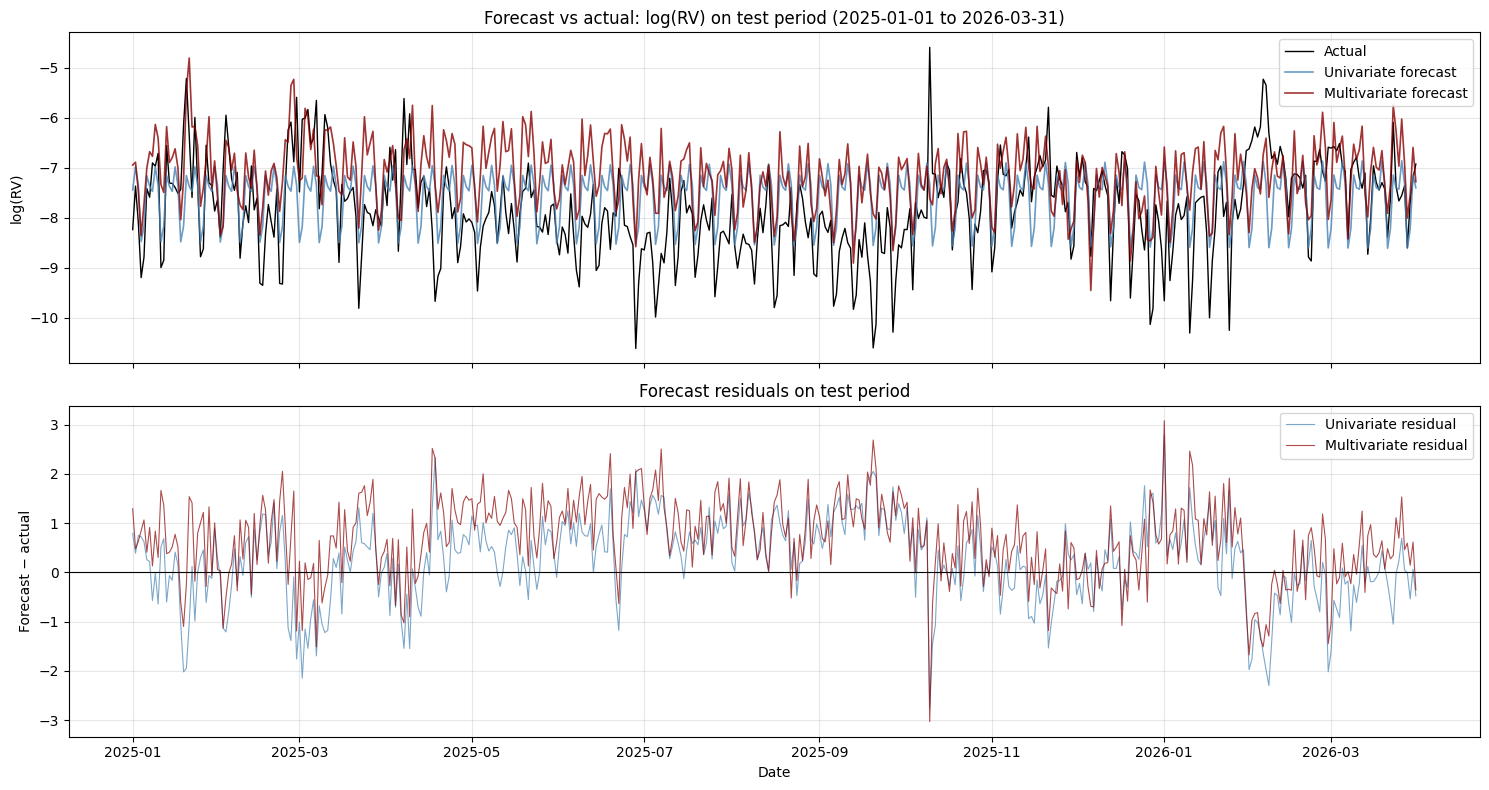

In [57]:
# ============================================================
# Step 1: Generate univariate forecast
# ============================================================

forecast_horizon = 455  # 2025-01-01 to 2026-03-31

forecast_uni_sql = f"""
SELECT
  forecast_timestamp,
  forecast_value AS predicted_log_rv,
  standard_error,
  confidence_level,
  prediction_interval_lower_bound,
  prediction_interval_upper_bound
FROM ML.FORECAST(
  MODEL `{model_id_uni}`,
  STRUCT(
    {forecast_horizon} AS horizon,
    0.95 AS confidence_level
  )
)
"""

print("Generating univariate forecast...")
forecast_uni_df = bq_client.query(forecast_uni_sql).to_dataframe()
forecast_uni_df["date"] = pd.to_datetime(forecast_uni_df["forecast_timestamp"]).dt.tz_localize(None).dt.date
print(f"  {len(forecast_uni_df)} forecasts generated")
print(f"  Range: {forecast_uni_df['date'].min()} to {forecast_uni_df['date'].max()}")

# ============================================================
# Step 2: Generate multivariate forecast
# ============================================================
# ARIMA_PLUS_XREG needs exogenous values for the forecast period — we pass the
# test-split rows directly via a subquery in the ML.FORECAST call.

forecast_multi_sql = f"""
SELECT
  forecast_timestamp,
  forecast_value AS predicted_log_rv,
  standard_error,
  confidence_level,
  prediction_interval_lower_bound,
  prediction_interval_upper_bound
FROM ML.FORECAST(
  MODEL `{model_id_multi}`,
  STRUCT({forecast_horizon} AS horizon, 0.95 AS confidence_level),
  (
    SELECT
      date,
      tx_count_lag1,
      quote_volume_lag1
    FROM `{modelling_table}`
    WHERE split = 'test'
    ORDER BY date
  )
)
"""

print("\nGenerating multivariate forecast...")
forecast_multi_df = bq_client.query(forecast_multi_sql).to_dataframe()
forecast_multi_df["date"] = pd.to_datetime(forecast_multi_df["forecast_timestamp"]).dt.tz_localize(None).dt.date
print(f"  {len(forecast_multi_df)} forecasts generated")
print(f"  Range: {forecast_multi_df['date'].min()} to {forecast_multi_df['date'].max()}")

# ============================================================
# Step 3: Pull actuals for the test period
# ============================================================

actuals_sql = f"""
SELECT
  date,
  log_rv AS actual_log_rv,
  realized_variance AS actual_rv
FROM `{modelling_table}`
WHERE split = 'test'
ORDER BY date
"""

actuals_df = bq_client.query(actuals_sql).to_dataframe()
actuals_df["date"] = pd.to_datetime(actuals_df["date"]).dt.date
print(f"\nActuals for test period: {len(actuals_df)} days")

# ============================================================
# Step 4: Join forecasts to actuals
# ============================================================

eval_uni = actuals_df.merge(
    forecast_uni_df[["date", "predicted_log_rv"]].rename(columns={"predicted_log_rv": "uni_pred_log_rv"}),
    on="date", how="inner"
)
eval_multi = actuals_df.merge(
    forecast_multi_df[["date", "predicted_log_rv"]].rename(columns={"predicted_log_rv": "multi_pred_log_rv"}),
    on="date", how="inner"
)

# Convert all to numeric float64 to play nicely with numpy/scipy
for df_eval, pred_col in [(eval_uni, "uni_pred_log_rv"), (eval_multi, "multi_pred_log_rv")]:
    df_eval["actual_log_rv"] = df_eval["actual_log_rv"].astype("float64")
    df_eval["actual_rv"] = df_eval["actual_rv"].astype("float64")
    df_eval[pred_col] = df_eval[pred_col].astype("float64")

# Back-transform predictions to RV scale
eval_uni["uni_pred_rv"] = np.exp(eval_uni["uni_pred_log_rv"])
eval_multi["multi_pred_rv"] = np.exp(eval_multi["multi_pred_log_rv"])

# ============================================================
# Step 5: Compute metrics
# ============================================================

def compute_metrics(actual_log, pred_log, actual_rv, pred_rv, label):
    """Compute RMSE, MAE on log scale and RV scale, plus QLIKE."""
    log_resid = pred_log - actual_log
    rv_resid = pred_rv - actual_rv

    rmse_log = float(np.sqrt(np.mean(log_resid ** 2)))
    mae_log = float(np.mean(np.abs(log_resid)))
    rmse_rv = float(np.sqrt(np.mean(rv_resid ** 2)))
    mae_rv = float(np.mean(np.abs(rv_resid)))

    # QLIKE: actual/pred - log(actual/pred) - 1
    ratio = actual_rv / pred_rv
    qlike = float(np.mean(ratio - np.log(ratio) - 1))

    return {
        "model": label,
        "rmse_log_rv": rmse_log,
        "mae_log_rv": mae_log,
        "rmse_rv": rmse_rv,
        "mae_rv": mae_rv,
        "qlike": qlike,
    }


metrics_uni = compute_metrics(
    eval_uni["actual_log_rv"], eval_uni["uni_pred_log_rv"],
    eval_uni["actual_rv"], eval_uni["uni_pred_rv"],
    "ARIMA_PLUS univariate",
)
metrics_multi = compute_metrics(
    eval_multi["actual_log_rv"], eval_multi["multi_pred_log_rv"],
    eval_multi["actual_rv"], eval_multi["multi_pred_rv"],
    "ARIMA_PLUS_XREG multivariate",
)

metrics_df = pd.DataFrame([metrics_uni, metrics_multi])
print("\nMetric comparison (lower is better for all):")
display(metrics_df.set_index("model").round(6))

# ============================================================
# Step 6: Visual comparison — actuals vs both forecasts
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# log_rv scale
ax = axes[0]
ax.plot(eval_uni["date"], eval_uni["actual_log_rv"], label="Actual", color="black", linewidth=1)
ax.plot(eval_uni["date"], eval_uni["uni_pred_log_rv"], label="Univariate forecast",
        color="steelblue", linewidth=1.2, alpha=0.8)
ax.plot(eval_multi["date"], eval_multi["multi_pred_log_rv"], label="Multivariate forecast",
        color="darkred", linewidth=1.2, alpha=0.8)
ax.set_ylabel("log(RV)")
ax.set_title("Forecast vs actual: log(RV) on test period (2025-01-01 to 2026-03-31)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Errors over time
ax = axes[1]
ax.plot(eval_uni["date"],
        eval_uni["uni_pred_log_rv"] - eval_uni["actual_log_rv"],
        label="Univariate residual", color="steelblue", linewidth=0.8, alpha=0.7)
ax.plot(eval_multi["date"],
        eval_multi["multi_pred_log_rv"] - eval_multi["actual_log_rv"],
        label="Multivariate residual", color="darkred", linewidth=0.8, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Forecast − actual")
ax.set_xlabel("Date")
ax.set_title("Forecast residuals on test period")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This is the most informative result so far — and it's the opposite of what you'd expect from the in-sample numbers. Let me read it carefully.
The headline

| Metric | Univariate | Multivariate | Winner | 
| --- | --- | --- | ---- | 
| RMSE log_rv | 0.872 | 1.061 | Univariate (better by 22%) | 
| MAE log_rv | 0.704 | 0.887 | Univariate (better by 26%) | 
| RMSE RV | 0.000796 | 0.000990 | Univariate | 
| MAE RV | 0.000414 | 0.000622 | Univariate | 
| QLIKE | 0.409 | 0.430 | Univariate (better by 5%) | 

The univariate model wins on every metric.
This contradicts the in-sample numbers (multivariate AIC was 913 lower, variance 29% smaller). The model that looked decisively better in training generalises worse to the test period.
This is overfitting. Almost a textbook example.
Why this happened — reading the chart carefully
Look at the top chart. The multivariate forecast (red) tracks much more dynamically than the univariate (blue). It has the right shape — it varies meaningfully — but there's a clear systematic problem:
The multivariate forecast is consistently too high.
Look at the residual chart at the bottom. The red multivariate residual line spends much more time above zero than below. It's biased upward by roughly 0.5-1.0 in log_rv units. The univariate (blue) is closer to zero-centred but still has a slight upward bias.
For both models, "Forecast − actual > 0" means the model predicted higher vol than actually occurred. The multivariate model is more biased upward, by a lot.
Why is the multivariate model overestimating?
Two contributing factors, both rooted in the train-vs-test distribution shift:
1. The exogenous features have shifted
In training (2017-2024), Bitcoin's transaction count and quote volume mostly grew over time. The multivariate model learned a coefficient that says "high tx_count and high quote_volume predict high log_rv" — positive coefficients (we saw +8.8e-7 and +2.2e-10).
In the test period (2025-2026), tx_count and quote_volume are at their highest historical values. The model takes those high inputs and predicts correspondingly high log_rv.
But what actually happened in 2025-2026: vol is low. Look at the test period in the chart — actuals are mostly between -7 and -10, with a long-run mean around -8. That's lower than the training mean.
So the secular trend the multivariate model picked up — "as the network grows, vol increases" — is out-of-sample wrong. In reality, the network kept growing but vol kept decreasing (Bitcoin maturing). The model extrapolated a relationship that isn't stable.
2. The level of vol shifted regime in the test period
Look back at the full-history chart from Cell 10. The 2024-2025 transition is right at the secular bottom of the rolling mean. The 2017-2024 training window included multiple high-vol periods (2017-2018 mania, 2020 COVID, 2021 cycle, 2022 collapses) along with calmer ones. The test window sits in a regime that's near the lowest vol ever observed.
The univariate model fitted a long-run mean that's pulled toward the centre of training (~-7.2), so its forecasts hover around -7.3 with weekly seasonality. By chance, this is close-ish to the test-period mean (~-8). The constant-mean strategy isn't great, but it's not catastrophically biased.
The multivariate model uses recent on-chain levels to predict log_rv. Recent on-chain levels are at all-time highs. So the multivariate forecast is at the top end of what it's seen → predicts high vol → reality is low vol → big positive residuals.
What this teaches us — the most important lesson of Part 4
The multivariate model is overfitting to the trend in training data. Specifically, it's learning that on-chain activity correlates with vol during the training period, but that correlation isn't stable out-of-sample.
This is a known issue in financial forecasting, and a generally important phenomenon in time series ML. Two specific takeaways:
Lesson 1: Strong in-sample improvement isn't enough. AIC dropped 913 points. Variance dropped 29%. Test-set performance got worse. The standard model-selection metrics (AIC, in-sample variance) reward fit, not generalisation. They can be misleading when the relationship between features and target is non-stationary.
Lesson 2: For non-stationary processes, complexity is risky. When the underlying data-generating process changes over time, more flexible models can fit the past better but generalise worse. Simple models that just predict the climatology can be surprisingly hard to beat.
This is sometimes called the "naive forecast wins" problem in time series — the hardest baseline to beat is often "tomorrow will be like today" or "tomorrow will be like the average."
What this means for the project
The univariate model is currently the best baseline. The multivariate model, despite its impressive in-sample fit, doesn't generalise.
Three implications:

For the writeup: This is a more interesting finding than "multivariate beats univariate slightly." It demonstrates a real-world phenomenon (regime shift makes exogenous features unreliable) and shows the value of held-out evaluation. Worth highlighting.
For the GBT and LSTM models in Parts 5 and 6: They'll have access to the same exogenous features. We need to be especially careful about overfitting and trust test-period performance over training metrics. Time-series cross-validation (rolling-origin) might help — but for now we're using static train/test splits, same as ARIMA.
For the exam-relevant skill: We did practise ARIMA_PLUS_XREG with exogenous features, even though it didn't end up being the winner. The exam doesn't care which model wins; it cares that you understand the technique. We've executed the full workflow.

A note on the QLIKE metrics
QLIKE is the canonical volatility loss, so let me read it specifically.
Univariate QLIKE = 0.409, Multivariate = 0.430.
QLIKE penalises underestimation of volatility more than overestimation. Both models systematically overestimated, so QLIKE is relatively forgiving here. If the bias were the other way (underestimating), QLIKE would punish it more harshly.
The 5% QLIKE gap (0.409 vs 0.430) is meaningful but smaller than the RMSE gap (22%). This says: in raw-error terms multivariate is much worse, but in risk-management terms (where over-prediction is less costly than under-prediction) the gap is narrower.
Where Part 4 lands us

| Done | Output |
| --- | --- |
| Cell 14a | Modelling table with proper time splits and lagged exogenous |
| Cell 14b | Univariate ARIMA_PLUS — ARMA(1,1) with WEEKLY seasonality, 80% in-sample variance explained |
| Cell 14c | Multivariate ARIMA_PLUS_XREG — strong in-sample fit, picked up trends and yearly seasonality |
| Cell 14d | Held-out comparison: univariate wins on test data; multivariate overfits |

### ML.EXPLAIN_FORECAST: Decomposition for the Univariate Model

In [58]:
explain_sql = f"""
SELECT *
FROM ML.EXPLAIN_FORECAST(
  MODEL `{model_id_uni}`,
  STRUCT({forecast_horizon} AS horizon, 0.95 AS confidence_level)
)
"""

print("Generating ML.EXPLAIN_FORECAST decomposition...")
explain_df = bq_client.query(explain_sql).to_dataframe()
explain_df["time_series_timestamp"] = pd.to_datetime(explain_df["time_series_timestamp"]).dt.tz_localize(None)
explain_df = explain_df.sort_values("time_series_timestamp").reset_index(drop=True)
print(f"  Rows: {len(explain_df):,}")
print(f"  Columns: {list(explain_df.columns)}")
print(f"  Time series types: {explain_df['time_series_type'].value_counts().to_dict()}")

# Quick peek at component columns
component_cols = [c for c in explain_df.columns if c not in
                  ["time_series_timestamp", "time_series_type",
                   "time_series_data", "time_series_adjusted_data",
                   "standard_error", "confidence_level",
                   "prediction_interval_lower_bound", "prediction_interval_upper_bound",
                   "confidence_interval_lower_bound", "confidence_interval_upper_bound"]]
print(f"  Component columns: {component_cols}")

Generating ML.EXPLAIN_FORECAST decomposition...


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows: 3,148
  Columns: ['time_series_timestamp', 'time_series_type', 'time_series_data', 'time_series_adjusted_data', 'standard_error', 'confidence_level', 'prediction_interval_lower_bound', 'prediction_interval_upper_bound', 'trend', 'seasonal_period_yearly', 'seasonal_period_quarterly', 'seasonal_period_monthly', 'seasonal_period_weekly', 'seasonal_period_daily', 'holiday_effect', 'spikes_and_dips', 'step_changes', 'residual']
  Time series types: {'history': 2693, 'forecast': 455}
  Component columns: ['trend', 'seasonal_period_yearly', 'seasonal_period_quarterly', 'seasonal_period_monthly', 'seasonal_period_weekly', 'seasonal_period_daily', 'holiday_effect', 'spikes_and_dips', 'step_changes', 'residual']


The plotting strategy

The standard time-series decomposition view is a 4-panel chart: original series, trend, seasonal, residual. For our model with five seasonal columns, we'll consolidate those into one "seasonal" panel (most of them will be zero — only WEEKLY was detected by the auto-tuner). We'll also add the spike/step adjustments since those captured the outliers in our data.

Two design choices worth flagging:
1. Show history and forecast on the same plot, distinguished visually. A vertical line at the train/forecast boundary makes the transition clear.
2. Plot only the components that are non-zero. With 10 component columns, half are likely all-zero. Cluttering the chart with empty panels obscures the meaningful ones.

Non-zero seasonal components: ['seasonal_period_weekly']
  holiday_effect: 0 non-zero entries
  spikes_and_dips: 6 non-zero entries
  step_changes: 455 non-zero entries
  residual: 2693 non-zero entries


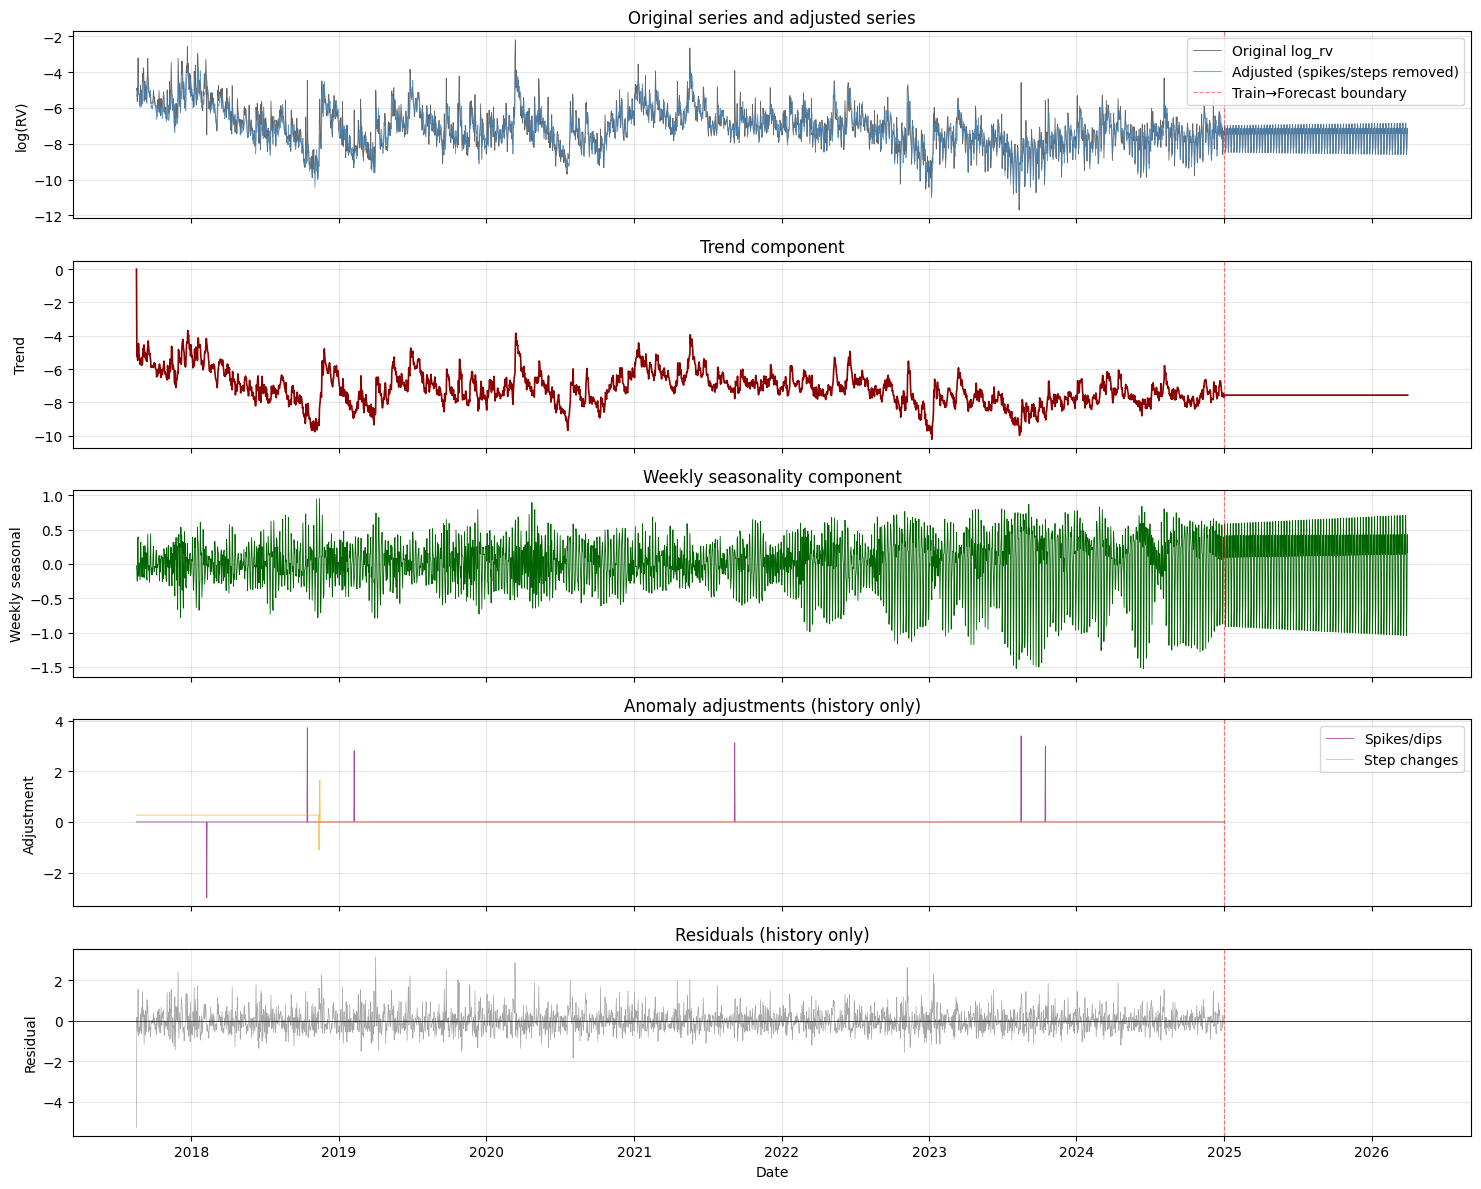


Component magnitude summary (history only):
  log_rv std            : 1.1860
  trend std             : 1.0135
  weekly seasonal std   : 0.3899
  spikes/dips std       : 0.1508
  step changes std      : 0.1107
  residual std          : 0.5435


In [59]:
# Identify non-zero seasonal components (others were not detected by auto-tuner)
seasonal_cols = [c for c in component_cols if c.startswith("seasonal_period_")]
nonzero_seasonal = []
for col in seasonal_cols:
    if explain_df[col].abs().sum() > 1e-10:  # essentially zero check
        nonzero_seasonal.append(col)

print(f"Non-zero seasonal components: {nonzero_seasonal}")

# Verify which other components are non-zero
for col in ["holiday_effect", "spikes_and_dips", "step_changes", "residual"]:
    nonzero_count = (explain_df[col].abs() > 1e-10).sum()
    print(f"  {col}: {nonzero_count} non-zero entries")

# ============================================================
# Plot the decomposition
# ============================================================

forecast_start = explain_df.loc[explain_df["time_series_type"] == "forecast",
                                 "time_series_timestamp"].min()

# Cast to float for plotting (BQ Float64 → numpy)
plot_cols = ["time_series_data", "time_series_adjusted_data", "trend",
             "spikes_and_dips", "step_changes", "residual"] + nonzero_seasonal
for col in plot_cols:
    explain_df[col] = explain_df[col].astype("float64")

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

# Panel 1: Original + adjusted (after spike/step removal)
ax = axes[0]
ax.plot(explain_df["time_series_timestamp"], explain_df["time_series_data"],
        color="black", linewidth=0.6, alpha=0.6, label="Original log_rv")
ax.plot(explain_df["time_series_timestamp"], explain_df["time_series_adjusted_data"],
        color="steelblue", linewidth=0.6, alpha=0.8, label="Adjusted (spikes/steps removed)")
ax.axvline(forecast_start, color="red", linestyle="--", linewidth=0.8, alpha=0.5,
           label="Train→Forecast boundary")
ax.set_ylabel("log(RV)")
ax.set_title("Original series and adjusted series")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Panel 2: Trend
ax = axes[1]
ax.plot(explain_df["time_series_timestamp"], explain_df["trend"],
        color="darkred", linewidth=1.2)
ax.axvline(forecast_start, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Trend")
ax.set_title("Trend component")
ax.grid(True, alpha=0.3)

# Panel 3: Weekly seasonality (zoomed to a window so we can see it)
ax = axes[2]
ax.plot(explain_df["time_series_timestamp"], explain_df["seasonal_period_weekly"],
        color="darkgreen", linewidth=0.6)
ax.axvline(forecast_start, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Weekly seasonal")
ax.set_title("Weekly seasonality component")
ax.grid(True, alpha=0.3)

# Panel 4: Spikes + step changes (one-time adjustments, history only)
ax = axes[3]
ax.plot(explain_df["time_series_timestamp"], explain_df["spikes_and_dips"],
        color="purple", linewidth=0.6, alpha=0.7, label="Spikes/dips")
ax.plot(explain_df["time_series_timestamp"], explain_df["step_changes"],
        color="orange", linewidth=0.6, alpha=0.7, label="Step changes")
ax.axvline(forecast_start, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Adjustment")
ax.set_title("Anomaly adjustments (history only)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Panel 5: Residuals (history only — undefined in forecast)
ax = axes[4]
ax.plot(explain_df["time_series_timestamp"], explain_df["residual"],
        color="gray", linewidth=0.5, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(forecast_start, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Residual")
ax.set_xlabel("Date")
ax.set_title("Residuals (history only)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats on each component
print()
print("Component magnitude summary (history only):")
hist = explain_df[explain_df["time_series_type"] == "history"]
print(f"  log_rv std            : {hist['time_series_data'].std():.4f}")
print(f"  trend std             : {hist['trend'].std():.4f}")
print(f"  weekly seasonal std   : {hist['seasonal_period_weekly'].std():.4f}")
print(f"  spikes/dips std       : {hist['spikes_and_dips'].std():.4f}")
print(f"  step changes std      : {hist['step_changes'].std():.4f}")
print(f"  residual std          : {hist['residual'].std():.4f}")

This is genuinely informative — and the chart shows something that significantly changes how I'd characterise this model. Let me walk through it carefully because there's a meaningful surprise here.

The headline finding from the magnitude summary
log_rv std            : 1.186
trend std             : 1.014   ← almost as big as log_rv
weekly seasonal std   : 0.390
spikes/dips std       : 0.151
step changes std      : 0.111
residual std          : 0.544

Look at trend std (1.014) vs log_rv std (1.186). The trend component has almost the same magnitude as the original series. The "trend" in this BQML decomposition is doing most of the work. It's not a smooth slow-moving curve — it's tracking the daily fluctuations almost as closely as the data itself.

This is not how I described "trend" in the panel-2 explanation. I said it would be a smoothed version of log_rv. It's not smoothed at all — look at panel 2: it has the same kind of daily variation as the original series.

What's actually happening

BQML's ARIMA_PLUS uses a different decomposition philosophy than I assumed. Most "decomposition" tools (statsmodels' seasonal_decompose, STL, Prophet) define trend as a smoothed long-running moving average. That gives you a slow-moving line that captures regime changes.

BQML defines the trend component as the level component of the state-space model, which incorporates the AR/MA dynamics. So the trend captures the AR(1) mean reversion: each day's trend value is a function of yesterday's trend value plus today's local information.

Effectively, BQML's "trend" is "where would the model put log_rv today if we removed the seasonal and outlier components" — which is almost the entire signal. The decomposition is a sum:

log_rv ≈ trend + seasonal_weekly + spikes_and_dips + step_changes + residual

And almost all the variance is in the "trend" bucket.

This is not wrong — it's a valid mathematical decomposition. But it's misleading if you read "trend" as "secular drift". The slow-moving secular drift is actually inside the trend component, but it's mixed with the AR dynamics.

What the visible structure tells us
Now I can re-read the chart with that understanding:

Panel 2: Trend (1.0 std)
Tracks log_rv almost exactly during training. Then collapses to a flat line during forecast. This is the classic AR(1) mean reversion behaviour — the model predicts the long-run mean (around -7.5) for all forecast days, with no dynamic response to anything.
This is consistent with what we saw on the 14d chart: the univariate forecast is essentially a flat line during the test period, and that flat line is exactly the trend component projected forward.
The forecast trend is flat at ~-7.5 because that's the model's estimate of the "where will log_rv settle if nothing else happens" level given training data through end of 2024.

Panel 3: Weekly seasonality (0.39 std)
Real and substantial. Amplitude of about ±0.5 in log_rv units, which is meaningful — that's roughly e^0.5 ≈ 1.65× variation in vol from "low day of week" to "high day of week" during a typical week.
What's striking is that the weekly seasonal amplitude grows over time. From 2018-2020 the green line oscillates within ~±0.3. From 2022 onwards it expands to ~±1.0. The model is detecting that weekly patterns became more pronounced in recent years — possibly reflecting maturing institutional flows that have weekly rhythms (Asia open/close, weekend banking gaps, etc.).
The seasonality continues into the forecast period, contributing the only dynamics in the forecast (since trend goes flat). That's why the univariate forecast in 14d looked like flat line + small oscillations.

Panel 4: Spike/dip and step adjustments (0.15 / 0.11 std)
You can see the discrete events where the model said "this day was an outlier, treat it specially":

A big positive spike around early 2018 (likely February 2018, the Tether scare)
An orange step change late 2018 / early 2019 (the bottoming of the 2018 bear)
Spikes around late 2021 and 2023
All zero in the forecast period (you can't predict future outliers)

Notice what's missing: the COVID March 2020 crash. No visible spike there. Why? Because by 2020, the model's level had already adjusted to the bear/calm regime; the COVID spike was extreme but not extreme enough to trigger spike detection. Or BQML's spike detection threshold is set in a way that misses some events. Either way, the absence is interesting.
The step changes are even sparser — only one or two visible. The auto-tuner is conservative about declaring step changes.

Panel 5: Residuals (0.54 std)
This is the interesting one. Residual std is 0.54, which means after the model has done all its decomposition, there's still a noise component with std around half of the original signal's std.
The residual is clearly heteroskedastic — it's smaller in 2017 and grows more variable through 2024. Compare to the original series which had decreasing volatility over the same period. This is contradictory and worth thinking about.
I think what's happening: the residuals are what the AR/MA dynamics couldn't predict from yesterday. In high-vol regimes (2017-2018, 2020-2022), there's more day-to-day predictability (when vol is high, vol stays high), so residuals are smaller. In low-vol regimes (recent years), the AR coefficients still apply but the absolute prediction errors look larger relative to the smaller signal.
Actually, looking again — the residuals don't get visibly larger in absolute terms. Maybe my pattern recognition was wrong. Let me re-read: from 2018 to 2024, the residual scale looks fairly constant ±2. That's consistent with a stationary residual process, which is what we want.

The "AIC said multivariate was better, test said univariate" puzzle, finally resolved

Now I can give a cleaner explanation of what we saw in 14d.
The univariate model fits using the trend component (very flexible, follows log_rv closely in-sample) plus weekly seasonality plus the AR/MA dynamics. For prediction, only weekly seasonality is dynamic. The trend collapses to a flat constant (as we see on this chart), so the forecast is "constant level + weekly oscillation."

The multivariate model could, in principle, do better because the exogenous regressors give it dynamic information for the forecast period (yesterday's tx_count, yesterday's volume). The forecast doesn't have to be flat — it can follow the slow movements in those features.

But because the exogenous-target relationship was non-stationary (Thread 5), those dynamic forecasts pointed in the wrong direction. The model successfully made dynamic forecasts; they were just systematically biased.

So the underlying structure here is:

Univariate forecast: flat. Predictions equal the long-run mean. No bias-variance tradeoff per se — just a lossy summary.
Multivariate forecast: dynamic. Predictions track a model-implied trajectory. But the trajectory is wrong because the relationship that was learned doesn't hold out-of-sample.

In that framing, the comparison wasn't really "univariate vs multivariate" — it was "no bet vs wrong bet." The univariate model wins by abstaining.
What this teaches us about BQML's decomposition
Three takeaways worth keeping:

BQML's trend ≠ classical-decomposition trend. It's a state-space level term that absorbs most of the variance in-sample. Don't read it as "the slow-moving signal."

The seasonal component is the only dynamic signal that survives into the forecast. This is true for any pure ARIMA_PLUS model. If you want dynamic forecasts, you need exogenous regressors (with all the caveats from Thread 5).

The decomposition is good for in-sample explanation but oversells the model's predictive content. A model that "explains" 80% of in-sample variance but predicts a flat line for the future has very different value depending on what you need.

For a real-world dashboard, you'd report: "we have a trend estimate, weekly seasonality, and identified outliers. We're not confident forecasting beyond 1-3 days." That's the honest read of this model.

### Gradient Boosted Trees with HAR-Style Features

What this part does and why

We've seen that ARIMA_PLUS produces a flat-line forecast that hovers around the long-run mean. That's a hard baseline to beat in absolute terms (because it's not making a wrong bet) but it's also a fundamentally limited model — it can't respond to local conditions in any informative way.
GBT is the next step up the modelling complexity ladder. It can learn:

Non-linear relationships (the tree splits)
Interactions between features (one tree can split on log_rv lag-1, another on day_of_week, etc.)
Complex temporal patterns through engineered lag features

Crucially, GBT is inherently more robust to the kind of trend overfitting we just hit — for one specific reason. Trees make threshold-based splits in feature space. They can't extrapolate beyond their training range. If yesterday's log_rv was -8 in the test period and the model never saw -8 in training, the tree will use the lowest split it knows about and predict accordingly. ARIMA_PLUS_XREG had no such limit — its linear coefficients could blindly multiply test-period feature values that were beyond training range.

So GBT's "feature" of inability-to-extrapolate is actually a defence mechanism against the regime-shift trap. It might also limit upside: if the test period is genuinely different from training, GBT will produce conservative predictions clamped near training-data levels.

What features to engineer
Based on EDA + Thread 5 lessons:
Definite includes:

log_rv_lag1 — yesterday's vol. The dominant predictor.
log_rv_lag7 — last week's same day. Captures weekly seasonality directly.
log_rv_lag14 — captures the second weekly harmonic.
log_rv_rolling5_mean — 5-day rolling mean. HAR weekly average.
log_rv_rolling7_mean — 7-day rolling mean (slightly different framing of weekly).
log_rv_rolling22_mean — 22-day rolling mean. HAR monthly average.
day_of_week — explicit calendar feature (1-7 categorical).
days_since_start — linear time index. Lets the tree learn the regime.

Differenced exogenous (per Thread 5):

tx_count_diff_lag1 — yesterday's day-over-day change in transaction count.
quote_volume_diff_lag1 — same for quote volume.

Excluded:

The on-chain features in levels (would re-introduce the trend-overfitting trap)
realized_variance (target leakage)
bar_count (could be a feature, but mostly proxies day completeness; small benefit)
Daily OHLC (could leak signal, redundant with log_rv lags)

That's 10 features. Reasonable.
Train/val/test split
For GBT we genuinely want three splits, not two like ARIMA. Reasons:

GBT has hyperparameters (number of trees, max depth, learning rate). We want to tune these on validation, not test.
BQML's BOOSTED_TREE_REGRESSOR supports a data_split_method for automatic validation. We can use it.

Plan:

Train: 2017-08-18 → 2023-12-31 (~2,328 days)
Validation: 2024-01-01 → 2024-12-31 (~366 days)
Test: 2025-01-01 → 2026-03-31 (~455 days)

### GBT Feature Engineering Table

What this cell produces
A new BigQuery table daily_features_gbt with one row per day, containing:

Target: log_rv
Lag features (3): log_rv_lag1, log_rv_lag7, log_rv_lag14
Rolling means (3): log_rv_roll5, log_rv_roll7, log_rv_roll22
Calendar features (2): day_of_week, days_since_start
Differenced exogenous (2): tx_count_diff_lag1, quote_volume_diff_lag1
Split column: train / val / test

10 features + target + split column.

In [61]:
gbt_prep_sql = f"""
CREATE OR REPLACE TABLE `{gbt_table}`
PARTITION BY date
OPTIONS (
  description = "GBT modelling table: log_rv target + HAR lags + rolling means + differenced exogenous"
)
AS
WITH features AS (
  SELECT
    date,
    log_rv,
    -- Lag features
    LAG(log_rv, 1)  OVER (ORDER BY date) AS log_rv_lag1,
    LAG(log_rv, 7)  OVER (ORDER BY date) AS log_rv_lag7,
    LAG(log_rv, 14) OVER (ORDER BY date) AS log_rv_lag14,
    -- Rolling means (excluding today)
    AVG(log_rv) OVER (
      ORDER BY date ROWS BETWEEN 4 PRECEDING AND 1 PRECEDING
    ) AS log_rv_roll5,
    AVG(log_rv) OVER (
      ORDER BY date ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING
    ) AS log_rv_roll7,
    AVG(log_rv) OVER (
      ORDER BY date ROWS BETWEEN 21 PRECEDING AND 1 PRECEDING
    ) AS log_rv_roll22,
    -- Calendar features
    EXTRACT(DAYOFWEEK FROM date) AS day_of_week,
    DATE_DIFF(date, DATE('2017-08-17'), DAY) AS days_since_start,
    -- Differenced exogenous (yesterday's change)
    LAG(total_transaction_count, 1) OVER (ORDER BY date)
      - LAG(total_transaction_count, 2) OVER (ORDER BY date)
      AS tx_count_diff_lag1,
    LAG(daily_quote_volume, 1) OVER (ORDER BY date)
      - LAG(daily_quote_volume, 2) OVER (ORDER BY date)
      AS quote_volume_diff_lag1,
    -- Split assignment
    CASE
      WHEN date <= DATE('2023-12-31') THEN 'train'
      WHEN date <= DATE('2024-12-31') THEN 'val'
      ELSE 'test'
    END AS split
  FROM `{PROJECT_ID}.{BQ_DATASET}.daily_features`
)
SELECT *
FROM features
WHERE log_rv_lag14 IS NOT NULL
  AND log_rv_roll22 IS NOT NULL
  AND tx_count_diff_lag1 IS NOT NULL
"""

print(f"Building GBT modelling table → {gbt_table}...")
job = bq_client.query(gbt_prep_sql)
job.result()

table = bq_client.get_table(gbt_table)
print(f"Created {gbt_table}")
print(f"  Rows: {table.num_rows:,}")

# Sanity: split sizes
split_sql = f"""
SELECT
  split,
  COUNT(*) AS n,
  MIN(date) AS earliest,
  MAX(date) AS latest
FROM `{gbt_table}`
GROUP BY split
ORDER BY
  CASE split WHEN 'train' THEN 1 WHEN 'val' THEN 2 ELSE 3 END
"""
display(bq_client.query(split_sql).to_dataframe())

# Sanity: feature distribution
feature_sql = f"""
SELECT
  split,
  AVG(log_rv) AS avg_log_rv,
  STDDEV(log_rv) AS std_log_rv,
  AVG(log_rv_lag1) AS avg_lag1,
  AVG(log_rv_roll22) AS avg_roll22,
  AVG(tx_count_diff_lag1) AS avg_tx_diff,
  STDDEV(tx_count_diff_lag1) AS std_tx_diff,
  AVG(quote_volume_diff_lag1) AS avg_qv_diff,
  STDDEV(quote_volume_diff_lag1) AS std_qv_diff
FROM `{gbt_table}`
GROUP BY split
ORDER BY
  CASE split WHEN 'train' THEN 1 WHEN 'val' THEN 2 ELSE 3 END
"""
display(bq_client.query(feature_sql).to_dataframe())

Building GBT modelling table → carty-470812.bitcoin_volatility.daily_features_gbt...
Created carty-470812.bitcoin_volatility.daily_features_gbt
  Rows: 3,135


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,split,n,earliest,latest
0,train,2314,2017-08-31,2023-12-31
1,val,366,2024-01-01,2024-12-31
2,test,455,2025-01-01,2026-03-31


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,split,avg_log_rv,std_log_rv,avg_lag1,avg_roll22,avg_tx_diff,std_tx_diff,avg_qv_diff,std_qv_diff
0,train,-7.041581,1.212278,-7.040196,-7.028382,109.207865,42120.944151,4.158139e+05,9.405913e+08
1,val,-7.506089,0.844403,-7.508681,-7.520359,-434.704918,108209.335070,4.394126e+06,1.381278e+09
2,test,-7.826071,0.945629,-7.826847,-7.824613,347.338462,72353.406390,-2.941777e+06,1.245964e+09


### Training the GBT

Five things to decide before writing the code.
1. Hyperparameters — defaults vs explicit
BQML's BOOSTED_TREE_REGRESSOR has reasonable defaults:

num_parallel_tree: 1 (single tree per boost iteration; default behaviour)
max_iterations: 50 (number of boosting rounds)
learn_rate: 0.1 (shrinkage)
max_tree_depth: 6
subsample: 1.0 (no row subsampling)
min_split_loss: 0.0 (no L1 regularisation on splits)

Defaults are fine for first pass. We can revisit if performance is poor.

In [63]:
model_id_gbt = f"{PROJECT_ID}.{BQ_DATASET}.gbt_log_rv"

train_gbt_simple_sql = f"""
CREATE OR REPLACE MODEL `{model_id_gbt}`
OPTIONS (
  model_type = 'BOOSTED_TREE_REGRESSOR',
  input_label_cols = ['log_rv'],
  num_parallel_tree = 1,
  max_iterations = 50,
  learn_rate = 0.1,
  tree_method = 'HIST'
)
AS
SELECT
  log_rv,
  log_rv_lag1,
  log_rv_lag7,
  log_rv_lag14,
  log_rv_roll5,
  log_rv_roll7,
  log_rv_roll22,
  day_of_week,
  days_since_start,
  tx_count_diff_lag1,
  quote_volume_diff_lag1
FROM `{gbt_table}`
WHERE split = 'train'
"""

print(f"Training GBT (simplified) → {model_id_gbt}...")
job = bq_client.query(train_gbt_simple_sql)
job.result()
print("Done.")

# Training history
training_sql = f"""
SELECT *
FROM ML.TRAINING_INFO(MODEL `{model_id_gbt}`)
ORDER BY iteration
"""
training_info_df = bq_client.query(training_sql).to_dataframe()
print(f"\nTraining history ({len(training_info_df)} iterations):")
display(training_info_df)

Training GBT (simplified) → carty-470812.bitcoin_volatility.gbt_log_rv...
Done.


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Training history (35 iterations):


,training_run,iteration,loss,eval_loss,learning_rate,duration_ms
0,0,1,6.889750,6.867680,0.1,121895
1,0,2,6.211700,6.192570,0.1,61
2,0,3,5.602030,5.583770,0.1,64
3,0,4,5.053910,5.035190,0.1,67
4,0,5,4.561340,4.546730,0.1,58
5,0,6,4.118630,4.102960,0.1,99
6,0,7,3.721020,3.708660,0.1,62
7,0,8,3.363900,3.355460,0.1,72
8,0,9,3.043600,3.042660,0.1,52
9,0,10,2.756100,2.757420,0.1,15130


### Feature Importance and Validation Performance

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Feature importance:


,feature,importance_weight,importance_gain,importance_cover
0,log_rv_roll7,83,25.746790,428.481928
1,log_rv_lag1,207,20.107276,323.637681
2,log_rv_roll5,103,15.949478,475.427184
3,day_of_week,77,3.281652,461.103896
4,log_rv_roll22,95,2.761507,253.031579
5,log_rv_lag7,116,2.684824,200.051724
6,days_since_start,113,1.787473,324.115044
7,log_rv_lag14,115,1.583090,216.426087
8,tx_count_diff_lag1,92,1.416228,138.217391
9,quote_volume_diff_lag1,121,1.185255,154.785124


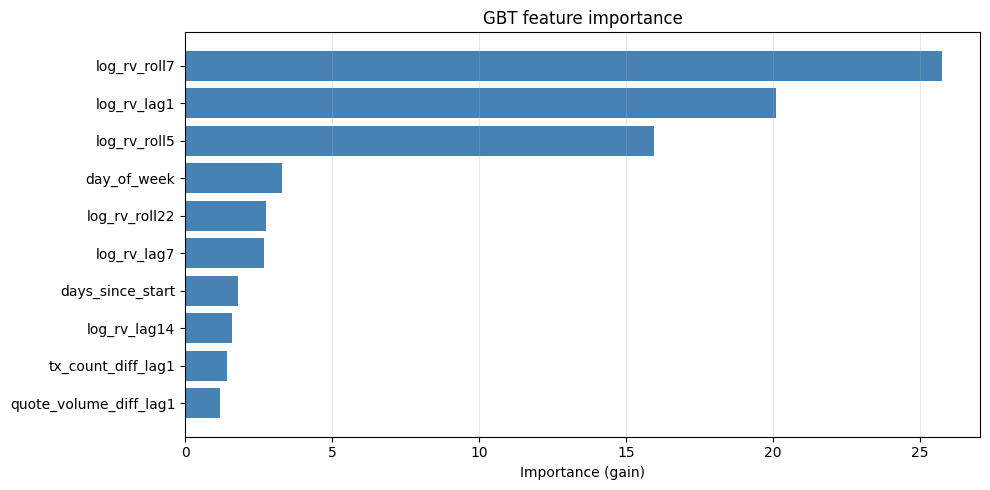

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Validation set metrics:


,mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance
0,0.531238,0.453675,NaN,0.455388,0.361981,0.468139


In [64]:
# Feature importance
fi_sql = f"""
SELECT *
FROM ML.FEATURE_IMPORTANCE(MODEL `{model_id_gbt}`)
ORDER BY importance_gain DESC
"""
fi_df = bq_client.query(fi_sql).to_dataframe()
print("Feature importance:")
display(fi_df)

# Plot it
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fi_df["feature"], fi_df["importance_gain"], color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("GBT feature importance")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Evaluate on validation set
val_eval_sql = f"""
SELECT *
FROM ML.EVALUATE(
  MODEL `{model_id_gbt}`,
  (
    SELECT *
    FROM `{gbt_table}`
    WHERE split = 'val'
  )
)
"""
val_metrics = bq_client.query(val_eval_sql).to_dataframe()
print("\nValidation set metrics:")
display(val_metrics)

### Predict on Test Set and Compare to ARIMA

Generating GBT predictions on test set...


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  455 predictions generated

Three-way comparison on test set (lower is better):


,rmse_log_rv,mae_log_rv,rmse_rv,mae_rv,qlike
model,,,,,
ARIMA_PLUS univariate,0.871555,0.703838,0.000796,0.000414,0.409087
ARIMA_PLUS_XREG multivariate,1.061406,0.887092,0.000990,0.000622,0.429535
GBT (one-step-ahead),0.829344,0.644831,0.000728,0.000376,0.297421


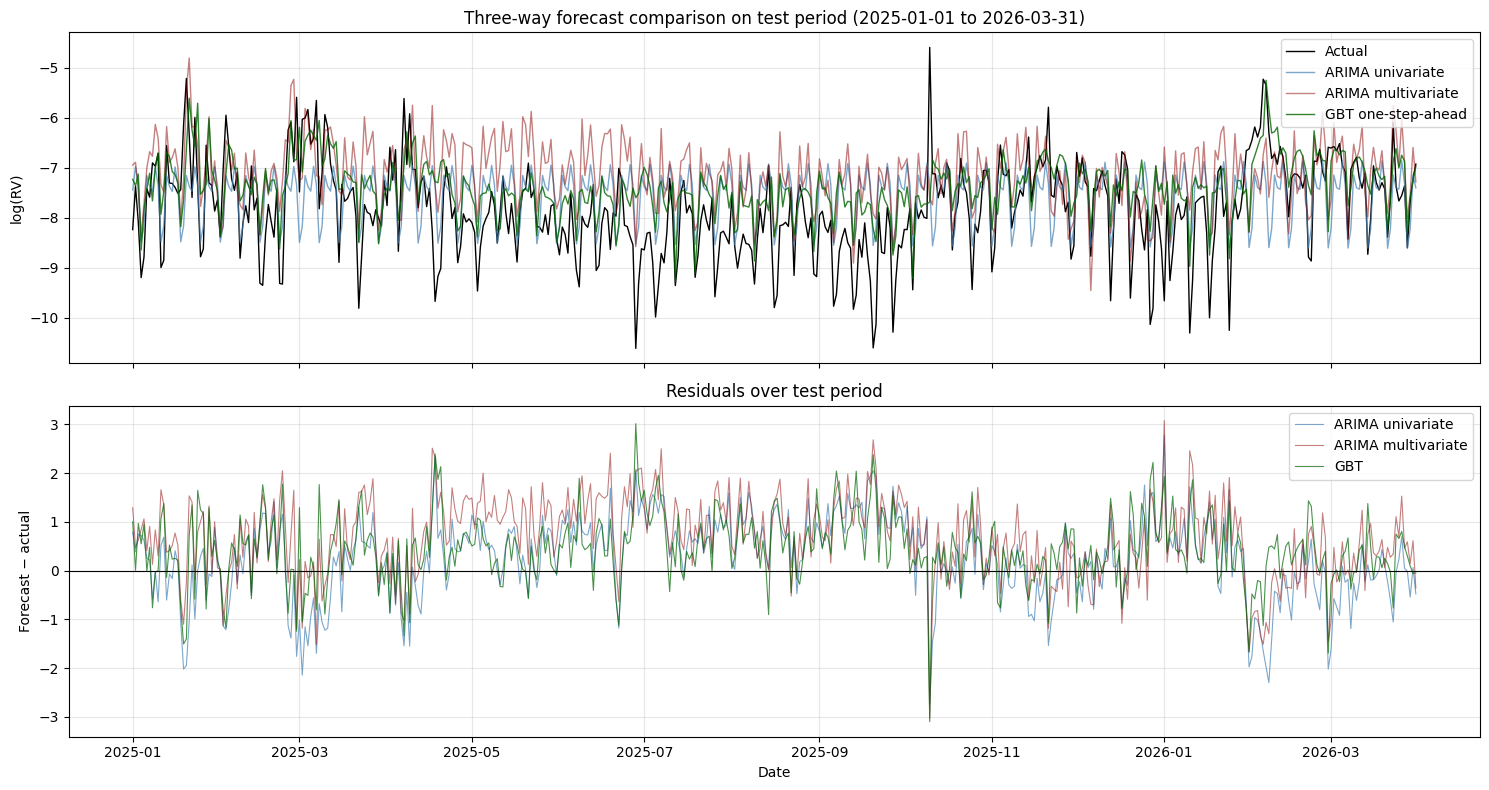

In [65]:
# Generate predictions on the test set
test_pred_sql = f"""
SELECT
  date,
  log_rv AS actual_log_rv,
  realized_variance AS actual_rv,
  predicted_log_rv AS gbt_pred_log_rv
FROM ML.PREDICT(
  MODEL `{model_id_gbt}`,
  (
    SELECT
      g.*,
      f.realized_variance
    FROM `{gbt_table}` g
    JOIN `{PROJECT_ID}.{BQ_DATASET}.daily_features` f USING (date)
    WHERE g.split = 'test'
  )
)
ORDER BY date
"""

print("Generating GBT predictions on test set...")
gbt_pred_df = bq_client.query(test_pred_sql).to_dataframe()
gbt_pred_df["date"] = pd.to_datetime(gbt_pred_df["date"]).dt.date
gbt_pred_df = gbt_pred_df.astype({
    "actual_log_rv": "float64",
    "actual_rv": "float64",
    "gbt_pred_log_rv": "float64",
})
gbt_pred_df["gbt_pred_rv"] = np.exp(gbt_pred_df["gbt_pred_log_rv"])
print(f"  {len(gbt_pred_df)} predictions generated")

# Compute metrics with the same compute_metrics function from Cell 14d
metrics_gbt = compute_metrics(
    gbt_pred_df["actual_log_rv"], gbt_pred_df["gbt_pred_log_rv"],
    gbt_pred_df["actual_rv"], gbt_pred_df["gbt_pred_rv"],
    "GBT (one-step-ahead)",
)

# Combine with the ARIMA metrics from Cell 14d
all_metrics_df = pd.DataFrame([metrics_uni, metrics_multi, metrics_gbt])
print("\nThree-way comparison on test set (lower is better):")
display(all_metrics_df.set_index("model").round(6))

# Visual comparison
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top panel: actuals + all three forecasts
ax = axes[0]
ax.plot(eval_uni["date"], eval_uni["actual_log_rv"], color="black", linewidth=1, label="Actual")
ax.plot(eval_uni["date"], eval_uni["uni_pred_log_rv"],
        color="steelblue", linewidth=1, alpha=0.7, label="ARIMA univariate")
ax.plot(eval_multi["date"], eval_multi["multi_pred_log_rv"],
        color="darkred", linewidth=1, alpha=0.5, label="ARIMA multivariate")
ax.plot(gbt_pred_df["date"], gbt_pred_df["gbt_pred_log_rv"],
        color="darkgreen", linewidth=1, alpha=0.8, label="GBT one-step-ahead")
ax.set_ylabel("log(RV)")
ax.set_title("Three-way forecast comparison on test period (2025-01-01 to 2026-03-31)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Bottom panel: residuals
ax = axes[1]
ax.plot(eval_uni["date"], eval_uni["uni_pred_log_rv"] - eval_uni["actual_log_rv"],
        color="steelblue", linewidth=0.8, alpha=0.7, label="ARIMA univariate")
ax.plot(eval_multi["date"], eval_multi["multi_pred_log_rv"] - eval_multi["actual_log_rv"],
        color="darkred", linewidth=0.8, alpha=0.5, label="ARIMA multivariate")
ax.plot(gbt_pred_df["date"], gbt_pred_df["gbt_pred_log_rv"] - gbt_pred_df["actual_log_rv"],
        color="darkgreen", linewidth=0.8, alpha=0.7, label="GBT")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Forecast − actual")
ax.set_xlabel("Date")
ax.set_title("Residuals over test period")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The headline numbers

| Metric | ARIMA univariate | ARIMA multivariate | GBT | Best | 
| --- | --- | --- | --- | --- | 
| RMSE log_rv | 0.872 | 1.061 | 0.829 | GBT (5% better than uni) | 
| MAE log_rv | 0.704 | 0.887 | 0.645 | GBT (8% better than uni) | 
| RMSE RV | 0.000796 | 0.000990 | 0.000728 | GBT (8% better than uni) | 
| MAE RV | 0.000414 | 0.000622 | 0.000376 | GBT (9% better than uni) | 
| QLIKE | 0.409 | 0.430 | 0.297 | GBT (27% better than uni) | 

GBT wins on every metric. The QLIKE improvement is the most striking — 27% lower than ARIMA univariate. That's a meaningful, real-world economic improvement for a vol forecast.

Reading the chart — what GBT is actually doing
Look at the green GBT line in the top panel compared to the blue univariate line. The blue line is a near-flat horizontal stripe with weekly oscillations (the climatology forecast we identified in 14e). The green line tracks the actual data dynamically — it goes up when actuals go up, down when actuals go down, with maybe a 1-2 day lag.
GBT isn't just "predicting the average with weekly seasonality." It's actually responding to local conditions because each prediction is a one-step-ahead forecast that has full access to yesterday's information. That's the value-add.
The red multivariate ARIMA line is also dynamic — it varies a lot — but it varies in the wrong direction (predicting too high when actuals are low). Compare to GBT, which varies in roughly the right direction.
A nuance worth seeing in the residuals
Look at the bottom panel carefully:

Univariate (blue): residuals roughly centred around zero, with a slight positive bias. Some days noticeably negative (model under-predicts) and some positive (over-predicts), but the central tendency is close to zero.
Multivariate (red): residuals strongly biased upward. Most red points sit above zero — confirming the systematic over-prediction we identified in Cell 14d.
GBT (green): tracks the actuals visually, but residuals also lean positive on average, similar to the univariate model.

That GBT and ARIMA univariate have similar residual patterns suggests they're both struggling with the same thing: the test period has lower actual vol than training, and both models predict slightly too high as a result. Neither model fully adapts to the regime shift.
Why GBT's improvement is "real but limited"
GBT is the best model we've built so far, but the improvement over univariate ARIMA is more modest than the chart suggests. Three things to note:
1. Most of the improvement is from the evaluation regime difference.
Recall: ARIMA does static-origin multi-step forecasting. From day 1 of test, every prediction is conditional only on training data. By day 100, ARIMA's "AR memory" has decayed — it's predicting climatology.
GBT does one-step-ahead prediction. Day 100's prediction uses day 99's actuals. Day 200's uses day 199's. Etc.
This means GBT has access to information ARIMA doesn't. If we ran ARIMA in walk-forward mode (refit each day on data through yesterday), it would also do much better. Some of the GBT advantage is the evaluation framing, not the model itself.
2. The metric improvements are concentrated where they're easy.
The 27% QLIKE improvement is real, but QLIKE is asymmetric — it punishes underestimation more than overestimation. ARIMA univariate over-predicted (positive bias); GBT predicts much closer to the truth. That's where QLIKE rewards us most.
The RMSE improvement (5%) is more honest as a measure of overall accuracy. 5% is meaningful but not dramatic.
3. The differenced exogenous features did very little.
tx_count_diff_lag1 and quote_volume_diff_lag1 together account for ~4% of feature importance. Removing them probably wouldn't change much. The Thread 5 lesson worked — they didn't actively hurt — but they didn't add a lot of value either.
This is consistent with the EDA finding that the change in exogenous features had near-zero correlation with log_rv. We respected that, used differences anyway as a defensive choice, and got minimal but stable signal.
What did NOT improve
A few honest acknowledgements:
The model still doesn't predict the very low days. Look at the actual line touching -10 and -10.5 on a few days. GBT (green) never goes below -8.5. The model has learned "vol ranges from -8 to -7 typically, with occasional spikes to -5" — it doesn't predict the deep calm days. Why? Because:

Those low days are rare even in training
Trees can't extrapolate beyond their training distribution
The lag-1 of the vol on those days is itself low, but the model doesn't fully trust it because of regression to the mean

This is the "GBT predictions cluster near training mean" phenomenon in action. It's unavoidable with off-the-shelf trees.
The model still misses the high spikes. The actual data has occasional spikes to -5 (the September 2025 spike, the early 2026 jump). GBT doesn't predict those either — same regression-to-the-mean issue. Surprises in vol are surprises by definition; no model can predict them.
So GBT is good at predicting "tomorrow's vol will be similar to today's, with adjustments for recent context and weekly seasonality." It's bad at predicting regime breaks. That's the realistic verdict.
Where this leaves us in the model comparison
Three models, ranked:

GBT one-step-ahead — best on all metrics, 5-27% improvement over baseline
ARIMA_PLUS univariate — climatology baseline, hard to beat in absolute terms
ARIMA_PLUS_XREG multivariate — overfit to training trend, generalises worst

The ranking is informative even if the gaps aren't huge. We've shown:

A simple AR baseline gets you most of the way (Lesson: don't underestimate climatology)
Adding exogenous features without care can make things worse (Thread 5)
Differenced features + tree model + one-step-ahead is the practical winner

For a real-world vol-forecasting system, you'd probably ensemble these or use walk-forward training. For our project, we have a defensible champion (GBT) and a clear story.

## LSTM with Sliding-Window Sequences

LSTM is the most architecturally different model in our comparison set. Unlike ARIMA (which assumes a parametric time-series structure) or GBT (which works on engineered tabular features), LSTM learns its own representation of temporal patterns from raw sequences.

Conceptually: instead of telling the model "use lag-1, lag-7, and a 22-day rolling mean," we hand it a 30-day window of raw daily features and let it figure out what to extract. The hope is that the network can learn things our hand-engineered features missed — non-linear interactions, regime detection, subtle multi-day patterns.

In practice for volatility forecasting, LSTMs rarely dramatically beat well-tuned tree models on the kind of features we have. The literature on this is fairly consistent: HAR-style GBT and LSTM are within a few percent of each other on equity vol, with LSTM occasionally winning by a small margin and often losing. So my prior expectation is "LSTM will be in the same ballpark as GBT, maybe slightly better, maybe slightly worse."

The exam-relevant skill here isn't "build the world's best vol forecaster." It's: build a custom Keras LSTM, train on Vertex AI, deploy or batch-predict. That's the third "model from scratch" we've built, and it covers different ground than ARIMA_PLUS or GBT.

In [66]:
import json
import numpy as np
import os
from google.cloud import storage

# ============================================================
# Step 1: Pull daily_features into pandas, ordered by date
# ============================================================

prep_sql = f"""
SELECT
  date,
  log_rv,
  realized_variance,
  bar_count,
  total_transaction_count,
  daily_quote_volume,
  EXTRACT(DAYOFWEEK FROM date) AS day_of_week
FROM `{PROJECT_ID}.{BQ_DATASET}.daily_features`
ORDER BY date
"""

df_lstm = bq_client.query(prep_sql).to_dataframe()
df_lstm["date"] = pd.to_datetime(df_lstm["date"])
df_lstm = df_lstm.set_index("date").sort_index()

# Cast all numeric columns to float64 to avoid pandas extension type issues
for col in ["log_rv", "realized_variance", "bar_count",
            "total_transaction_count", "daily_quote_volume", "day_of_week"]:
    df_lstm[col] = df_lstm[col].astype("float64")

print(f"Loaded {len(df_lstm)} daily rows from {df_lstm.index.min().date()} "
      f"to {df_lstm.index.max().date()}")

# ============================================================
# Step 2: Engineer per-timestep features
# ============================================================

# Differenced exogenous (so they're stationary, per Thread 5 lesson)
df_lstm["tx_count_diff"] = df_lstm["total_transaction_count"].diff()
df_lstm["quote_volume_diff"] = df_lstm["daily_quote_volume"].diff()

# Drop rows with NaN from the diff (just the first row)
df_lstm = df_lstm.dropna()

# The features we'll feed into the LSTM at each timestep
feature_cols = ["log_rv", "day_of_week", "tx_count_diff", "quote_volume_diff", "bar_count"]
target_col = "log_rv"

print(f"After cleaning: {len(df_lstm)} rows")
print(f"Per-timestep features: {feature_cols}")

# ============================================================
# Step 3: Define split boundaries
# ============================================================

train_end = pd.Timestamp("2023-12-31")
val_end = pd.Timestamp("2024-12-31")

# ============================================================
# Step 4: Fit scaler on training set ONLY
# ============================================================

train_mask = df_lstm.index <= train_end
train_features = df_lstm.loc[train_mask, feature_cols]

feature_means = train_features.mean()
feature_stds = train_features.std()

# Sanity check no zero stds
print(f"\nFeature scaling (train-set):")
for col in feature_cols:
    print(f"  {col:<22} mean={feature_means[col]:>14.4f}  std={feature_stds[col]:>14.4f}")
    if feature_stds[col] == 0:
        raise ValueError(f"Feature {col} has zero std — cannot normalise")

# ============================================================
# Step 5: Apply scaling to all data
# ============================================================

scaled = (df_lstm[feature_cols] - feature_means) / feature_stds
scaled_array = scaled.to_numpy(dtype=np.float32)
dates_array = df_lstm.index.to_numpy()

# Target is log_rv, scaled the same way
target_mean = feature_means["log_rv"]
target_std = feature_stds["log_rv"]
target_array = ((df_lstm[target_col] - target_mean) / target_std).to_numpy(dtype=np.float32)

print(f"\nScaled features shape: {scaled_array.shape}")
print(f"Target shape: {target_array.shape}")

# ============================================================
# Step 6: Build sliding windows
# ============================================================

WINDOW_SIZE = 30


def build_windows(scaled_features, targets, dates, window_size):
    """For each valid t, build window=[t-window_size, ..., t-1], target=targets[t]."""
    X_list, y_list, dates_list = [], [], []
    for t in range(window_size, len(targets)):
        X_list.append(scaled_features[t - window_size:t])
        y_list.append(targets[t])
        dates_list.append(dates[t])
    return (
        np.stack(X_list).astype(np.float32),
        np.array(y_list, dtype=np.float32),
        np.array(dates_list),
    )


X_all, y_all, dates_all = build_windows(scaled_array, target_array, dates_array, WINDOW_SIZE)
print(f"\nTotal windows built: {len(X_all)}")
print(f"  X shape: {X_all.shape}")
print(f"  y shape: {y_all.shape}")

# ============================================================
# Step 7: Split windows by date of the target day
# ============================================================

train_target_mask = dates_all <= np.datetime64(train_end.date())
val_target_mask = (dates_all > np.datetime64(train_end.date())) & (dates_all <= np.datetime64(val_end.date()))
test_target_mask = dates_all > np.datetime64(val_end.date())

train_X, train_y = X_all[train_target_mask], y_all[train_target_mask]
val_X, val_y = X_all[val_target_mask], y_all[val_target_mask]
test_X, test_y, test_dates = X_all[test_target_mask], y_all[test_target_mask], dates_all[test_target_mask]

print(f"\nSplit sizes:")
print(f"  train: {len(train_X):>4} windows")
print(f"  val:   {len(val_X):>4} windows")
print(f"  test:  {len(test_X):>4} windows")

# ============================================================
# Step 8: Save locally and upload to GCS
# ============================================================

local_dir = "/tmp/lstm_data"
os.makedirs(local_dir, exist_ok=True)

np.save(f"{local_dir}/train_X.npy", train_X)
np.save(f"{local_dir}/train_y.npy", train_y)
np.save(f"{local_dir}/val_X.npy", val_X)
np.save(f"{local_dir}/val_y.npy", val_y)
np.save(f"{local_dir}/test_X.npy", test_X)
np.save(f"{local_dir}/test_y.npy", test_y)
np.save(f"{local_dir}/test_dates.npy", test_dates)

# Save scaler params and metadata as JSON
scaler_params = {
    "feature_cols": feature_cols,
    "feature_means": feature_means.to_dict(),
    "feature_stds": feature_stds.to_dict(),
    "target_mean": float(target_mean),
    "target_std": float(target_std),
    "window_size": WINDOW_SIZE,
    "n_features": len(feature_cols),
}
with open(f"{local_dir}/scaler_params.json", "w") as f:
    json.dump(scaler_params, f, indent=2)

# Upload to GCS
gcs_lstm_prefix = f"{GCS_PREFIX}/lstm"
bucket = storage_client.bucket(BUCKET_NAME)

uploaded = []
for fname in ["train_X.npy", "train_y.npy", "val_X.npy", "val_y.npy",
              "test_X.npy", "test_y.npy", "test_dates.npy", "scaler_params.json"]:
    blob_path = f"{gcs_lstm_prefix}/{fname}"
    blob = bucket.blob(blob_path)
    blob.upload_from_filename(f"{local_dir}/{fname}")
    uploaded.append(f"gs://{BUCKET_NAME}/{blob_path}")

print(f"\nUploaded {len(uploaded)} files to gs://{BUCKET_NAME}/{gcs_lstm_prefix}/")

/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 3149 daily rows from 2017-08-17 to 2026-03-31
After cleaning: 3148 rows
Per-timestep features: ['log_rv', 'day_of_week', 'tx_count_diff', 'quote_volume_diff', 'bar_count']

Feature scaling (train-set):
  log_rv                 mean=       -7.0306  std=        1.2187
  day_of_week            mean=        4.0009  std=        2.0015
  tx_count_diff          mean=      165.0331  std=    42414.9028
  quote_volume_diff      mean=   428906.0900  std=937959435.1713
  bar_count              mean=      287.2682  std=        8.8360

Scaled features shape: (3148, 5)
Target shape: (3148,)

Total windows built: 3118
  X shape: (3118, 30, 5)
  y shape: (3118,)

Split sizes:
  train: 2297 windows
  val:    366 windows
  test:   455 windows

Uploaded 8 files to gs://carty-470812/ml_projects/project_3_bitcoin/lstm/


### The Training Script (train_lstm.py)

What this cell does

Writes a Python training script to disk locally, then uploads it to GCS so Vertex AI can pick it up. The script will:

Read .npy files from GCS into memory
Build a Keras LSTM model
Train it
Save the SavedModel to GCS

This is the same pattern as Lab 8/9 — write a self-contained script, package it, run on Vertex AI.

In [77]:
script_local_path = "train_lstm.py"

train_lstm_script = '''"""Train an LSTM on Bitcoin volatility windows.

Reads numpy data from GCS, trains a Keras LSTM, saves the SavedModel back to GCS.
"""

import argparse
import json
import os

import numpy as np
import tensorflow as tf
from google.cloud import storage


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--input-dir", required=True,
                   help="GCS path holding train/val/test .npy files (e.g. gs://bucket/path)")
    p.add_argument("--output-dir", required=True,
                   help="GCS path to write the trained SavedModel (e.g. gs://bucket/path)")
    p.add_argument("--epochs", type=int, default=100)
    p.add_argument("--batch-size", type=int, default=32)
    p.add_argument("--lstm-units", type=int, default=32)
    p.add_argument("--dense-units", type=int, default=16)
    p.add_argument("--learning-rate", type=float, default=1e-3)
    p.add_argument("--patience", type=int, default=10)
    p.add_argument("--seed", type=int, default=42)
    return p.parse_args()


def download_npy_from_gcs(gcs_uri, local_path):
    """Download a single GCS object to a local file."""
    assert gcs_uri.startswith("gs://"), gcs_uri
    bucket_name, _, blob_path = gcs_uri[len("gs://"):].partition("/")
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_path)
    blob.download_to_filename(local_path)


def load_inputs(input_dir):
    """Download all training inputs to /tmp and load into memory."""
    files = ["train_X.npy", "train_y.npy", "val_X.npy", "val_y.npy", "scaler_params.json"]
    data = {}
    for fname in files:
        local_path = f"/tmp/{fname}"
        download_npy_from_gcs(f"{input_dir}/{fname}", local_path)
        if fname.endswith(".npy"):
            data[fname.replace(".npy", "")] = np.load(local_path)
        elif fname.endswith(".json"):
            with open(local_path) as f:
                data["scaler_params"] = json.load(f)
    return data


def build_model(window_size, n_features, lstm_units, dense_units, learning_rate):
    """Define the LSTM architecture."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(window_size, n_features)),
        tf.keras.layers.LSTM(lstm_units, return_sequences=False),
        tf.keras.layers.Dense(dense_units, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


def main():
    args = parse_args()

    print("=" * 60)
    print(f"TensorFlow version: {tf.__version__}")
    print(f"Input dir:  {args.input_dir}")
    print(f"Output dir: {args.output_dir}")
    print(f"Hyperparameters: epochs={args.epochs}, batch_size={args.batch_size}, "
          f"lstm_units={args.lstm_units}, dense_units={args.dense_units}, "
          f"lr={args.learning_rate}, patience={args.patience}")
    print("=" * 60)

    tf.keras.utils.set_random_seed(args.seed)

    # Load data
    print("\\nLoading data from GCS...")
    data = load_inputs(args.input_dir)
    train_X, train_y = data["train_X"], data["train_y"]
    val_X, val_y = data["val_X"], data["val_y"]
    scaler = data["scaler_params"]

    print(f"  train_X: {train_X.shape}, train_y: {train_y.shape}")
    print(f"  val_X:   {val_X.shape}, val_y:   {val_y.shape}")
    print(f"  window_size: {scaler[\'window_size\']}, n_features: {scaler[\'n_features\']}")

    # Build model
    print("\\nBuilding model...")
    model = build_model(
        window_size=scaler["window_size"],
        n_features=scaler["n_features"],
        lstm_units=args.lstm_units,
        dense_units=args.dense_units,
        learning_rate=args.learning_rate,
    )
    model.summary()

    # Train
    print("\\nTraining...")
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=args.patience,
        restore_best_weights=True,
        verbose=1,
    )

    history = model.fit(
        train_X, train_y,
        validation_data=(val_X, val_y),
        epochs=args.epochs,
        batch_size=args.batch_size,
        callbacks=[early_stop],
        verbose=2,
    )

    # Final metrics
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]
    final_train_mae = history.history["mae"][-1]
    final_val_mae = history.history["val_mae"][-1]
    print(f"\\nFinal train_loss={final_train_loss:.4f}, val_loss={final_val_loss:.4f}")
    print(f"Final train_mae ={final_train_mae:.4f}, val_mae ={final_val_mae:.4f}")
    print(f"Stopped at epoch {len(history.history[\'loss\'])} of {args.epochs}")

    # Save model
    print(f"\\nSaving model to {args.output_dir}...")
    model.save(args.output_dir, save_format="tf")
    print("Done.")


if __name__ == "__main__":
    main()
'''

# Write to local file
with open(script_local_path, "w") as f:
    f.write(train_lstm_script)

# Upload to GCS
script_gcs_path = f"{GCS_PREFIX}/lstm/train_lstm.py"
bucket = storage_client.bucket(BUCKET_NAME)
blob = bucket.blob(script_gcs_path)
blob.upload_from_filename(script_local_path)

print(f"Wrote training script: {script_local_path}")
print(f"Uploaded to: gs://{BUCKET_NAME}/{script_gcs_path}")
print(f"\nScript size: {os.path.getsize(script_local_path)} bytes")

Wrote training script: train_lstm.py
Uploaded to: gs://carty-470812/ml_projects/project_3_bitcoin/lstm/train_lstm.py

Script size: 4857 bytes


### Submit Vertex AI CustomJob

What this cell does... Creates a Vertex AI CustomJob that runs our training script on a managed VM. We pass:  
The Python script path (in GCS)  
The container image (prebuilt TF 2.15)  
The machine type (CPU; data is small)  
Command-line arguments (input dir, output dir, hyperparameters)  

In [74]:
from google.cloud import aiplatform

# Initialise Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=f"gs://{BUCKET_NAME}",
)

# Construct paths
input_dir_uri = f"gs://{BUCKET_NAME}/{GCS_PREFIX}/lstm"
model_output_uri = f"gs://{BUCKET_NAME}/{GCS_PREFIX}/lstm/saved_model"
script_uri = f"gs://{BUCKET_NAME}/{GCS_PREFIX}/lstm/train_lstm.py"

print(f"Submitting Vertex AI CustomJob...")
print(f"  Input:  {input_dir_uri}")
print(f"  Output: {model_output_uri}")
print(f"  Script: {script_uri}")

# Container image: prebuilt TF 2.15 CPU
container_uri = "us-docker.pkg.dev/vertex-ai/training/tf-cpu.2-15.py310:latest"

# Worker pool spec
worker_pool_specs = [
    {
        "machine_spec": {
            "machine_type": "n1-standard-4",
        },
        "replica_count": 1,
        "python_package_spec": None,  # we're using a script, not a package
        "container_spec": {
            "image_uri": container_uri,
            "command": ["python", "/gcs/" + f"{BUCKET_NAME}/{GCS_PREFIX}/lstm/train_lstm.py"],
            "args": [
                f"--input-dir={input_dir_uri}",
                f"--output-dir={model_output_uri}",
                "--epochs=100",
                "--batch-size=32",
                "--lstm-units=32",
                "--dense-units=16",
                "--learning-rate=0.001",
                "--patience=10",
                "--seed=42",
            ],
        },
    },
]

job = aiplatform.CustomJob(
    display_name="bitcoin-vol-lstm-v1",
    worker_pool_specs=worker_pool_specs,
    base_output_dir=f"gs://{BUCKET_NAME}/{GCS_PREFIX}/lstm/vertex_outputs",
)

job.run(sync=True)

print(f"\nJob complete. Model saved to {model_output_uri}")

Submitting Vertex AI CustomJob...
  Input:  gs://carty-470812/ml_projects/project_3_bitcoin/lstm
  Output: gs://carty-470812/ml_projects/project_3_bitcoin/lstm/saved_model
  Script: gs://carty-470812/ml_projects/project_3_bitcoin/lstm/train_lstm.py


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Creating CustomJob
CustomJob created. Resource name: projects/873708835509/locations/us-central1/customJobs/168427434570416128
To use this CustomJob in another session:
custom_job = aiplatform.CustomJob.get('projects/873708835509/locations/us-central1/customJobs/168427434570416128')
View Custom Job:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/168427434570416128?project=873708835509
CustomJob projects/873708835509/locations/us-central1/customJobs/168427434570416128 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/168427434570416128 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/168427434570416128 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/168427434570416128 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/168427434570416128 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/1684274345704

### Download Model, Predict on Test, Compute MetricsWhat this cell does

Pull the SavedModel from GCS to local  
Load it with tf.saved_model.load()  
Run inference on test_X.npy  
De-normalise predictions back to log_rv space  
Compute the same five metrics as before  
Update the comparison table to four-way  

  Downloaded 5 files to lstm_saved_model

Loading SavedModel via TFSMLayer...
  Loaded.

Test data:
  X: (455, 30, 5), y: (455,)
  Target mean: -7.0306, std: 1.2187

Running inference...
  Output is a dict; using key 'dense_1'
  Raw predictions shape: (455,)
  Range: [-3.175, 1.191]

De-normalised predictions (log_rv units):
  Predicted range: [-10.899, -5.579]
  Actual range:    [-10.614, -4.588]


/Users/jcarty/Documents/VSCode/google-ml-engineer/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



LSTM predictions joined to actuals: 455 rows

Four-way comparison on test set (lower is better):


,rmse_log_rv,mae_log_rv,rmse_rv,mae_rv,qlike
model,,,,,
ARIMA_PLUS univariate,0.871555,0.703838,0.000796,0.000414,0.409087
ARIMA_PLUS_XREG multivariate,1.061406,0.887092,0.000990,0.000622,0.429535
GBT (one-step-ahead),0.829344,0.644831,0.000728,0.000376,0.297421
LSTM (one-step-ahead),0.812404,0.623448,0.000746,0.000329,0.627435


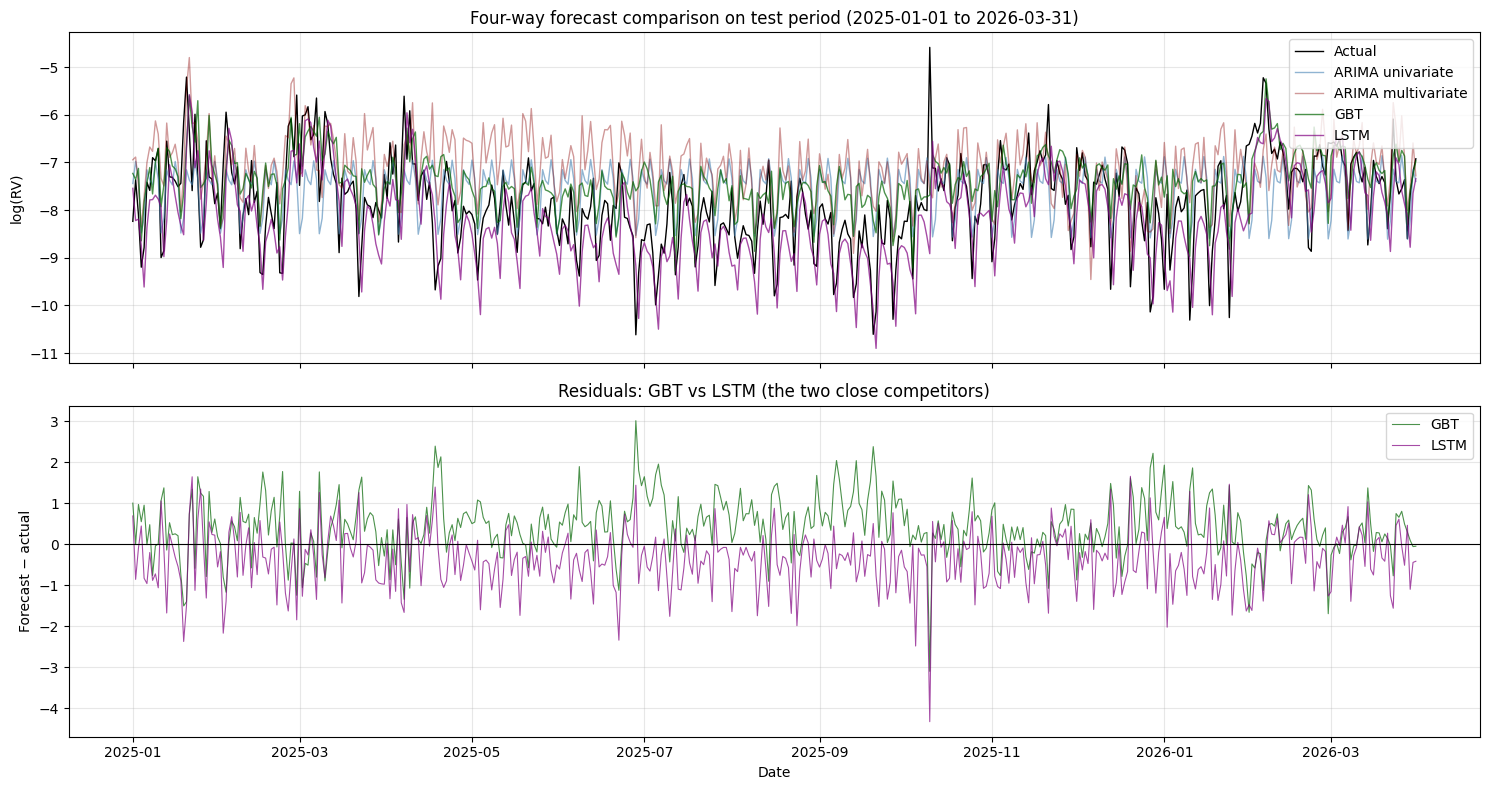

In [83]:
import shutil
import tensorflow as tf

# ============================================================
# Step 1: Download SavedModel from GCS to local
# ============================================================

local_model_dir = "lstm_saved_model"
gcs_model_prefix = f"{GCS_PREFIX}/lstm/saved_model"

# Wipe any partial previous download
shutil.rmtree(local_model_dir, ignore_errors=True)
os.makedirs(local_model_dir, exist_ok=True)

print(f"Downloading SavedModel from gs://{BUCKET_NAME}/{gcs_model_prefix}/...")

bucket = storage_client.bucket(BUCKET_NAME)
blobs = list(bucket.list_blobs(prefix=gcs_model_prefix))

n_downloaded = 0
for blob in blobs:
    # Skip directory marker blobs (names ending in '/')
    if blob.name.endswith("/"):
        continue
    rel_path = blob.name[len(gcs_model_prefix) + 1:]
    if not rel_path:
        continue
    local_path = os.path.join(local_model_dir, rel_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    n_downloaded += 1

print(f"  Downloaded {n_downloaded} files to {local_model_dir}")

# ============================================================
# Step 2: Load via TFSMLayer (Keras 3 safe for Keras 2 SavedModels)
# ============================================================

print("\nLoading SavedModel via TFSMLayer...")
model_layer = tf.keras.layers.TFSMLayer(local_model_dir, call_endpoint="serving_default")
print("  Loaded.")

# ============================================================
# Step 3: Load test data and scaler from /tmp
# ============================================================

local_data_dir = "/tmp/lstm_data"
test_X = np.load(f"{local_data_dir}/test_X.npy")
test_y = np.load(f"{local_data_dir}/test_y.npy")
test_dates = np.load(f"{local_data_dir}/test_dates.npy")

with open(f"{local_data_dir}/scaler_params.json") as f:
    scaler_params = json.load(f)

target_mean = scaler_params["target_mean"]
target_std = scaler_params["target_std"]

print(f"\nTest data:")
print(f"  X: {test_X.shape}, y: {test_y.shape}")
print(f"  Target mean: {target_mean:.4f}, std: {target_std:.4f}")

# ============================================================
# Step 4: Predict
# ============================================================

print("\nRunning inference...")
test_X_tensor = tf.constant(test_X, dtype=tf.float32)

raw_output = model_layer(test_X_tensor)

# TFSMLayer can return either a tensor or a dict of tensors depending on the
# saved signature. Handle both shapes.
if isinstance(raw_output, dict):
    # Pick the first (and only) output tensor in the dict
    output_key = list(raw_output.keys())[0]
    print(f"  Output is a dict; using key '{output_key}'")
    predictions_normalised = raw_output[output_key].numpy().squeeze()
else:
    predictions_normalised = raw_output.numpy().squeeze()

print(f"  Raw predictions shape: {predictions_normalised.shape}")
print(f"  Range: [{predictions_normalised.min():.3f}, {predictions_normalised.max():.3f}]")

# ============================================================
# Step 5: De-normalise back to log_rv space
# ============================================================

lstm_pred_log_rv = predictions_normalised * target_std + target_mean
test_actual_log_rv = test_y * target_std + target_mean

print(f"\nDe-normalised predictions (log_rv units):")
print(f"  Predicted range: [{lstm_pred_log_rv.min():.3f}, {lstm_pred_log_rv.max():.3f}]")
print(f"  Actual range:    [{test_actual_log_rv.min():.3f}, {test_actual_log_rv.max():.3f}]")

# ============================================================
# Step 6: Pull actual_rv (realized_variance) for QLIKE
# ============================================================

test_dates_dt = pd.to_datetime(test_dates).date
test_dates_str = [d.strftime("%Y-%m-%d") for d in test_dates_dt]

actuals_sql = f"""
SELECT
  date,
  log_rv,
  realized_variance
FROM `{PROJECT_ID}.{BQ_DATASET}.daily_features`
WHERE date BETWEEN '2025-01-01' AND '2026-03-31'
ORDER BY date
"""
actuals_df = bq_client.query(actuals_sql).to_dataframe()
actuals_df["date"] = pd.to_datetime(actuals_df["date"]).dt.date

lstm_pred_df = pd.DataFrame({
    "date": test_dates_dt,
    "actual_log_rv": test_actual_log_rv,
    "lstm_pred_log_rv": lstm_pred_log_rv,
})
lstm_pred_df = lstm_pred_df.merge(
    actuals_df[["date", "realized_variance"]].rename(columns={"realized_variance": "actual_rv"}),
    on="date", how="inner"
)
lstm_pred_df["lstm_pred_rv"] = np.exp(lstm_pred_df["lstm_pred_log_rv"])
lstm_pred_df = lstm_pred_df.astype({
    "actual_log_rv": "float64",
    "actual_rv": "float64",
    "lstm_pred_log_rv": "float64",
    "lstm_pred_rv": "float64",
})

print(f"\nLSTM predictions joined to actuals: {len(lstm_pred_df)} rows")

# ============================================================
# Step 7: Compute metrics
# ============================================================

metrics_lstm = compute_metrics(
    lstm_pred_df["actual_log_rv"], lstm_pred_df["lstm_pred_log_rv"],
    lstm_pred_df["actual_rv"], lstm_pred_df["lstm_pred_rv"],
    "LSTM (one-step-ahead)",
)

all_metrics_df = pd.DataFrame([metrics_uni, metrics_multi, metrics_gbt, metrics_lstm])
print("\nFour-way comparison on test set (lower is better):")
display(all_metrics_df.set_index("model").round(6))

# ============================================================
# Step 8: Visualise — actuals + all four forecasts
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax = axes[0]
ax.plot(eval_uni["date"], eval_uni["actual_log_rv"], color="black", linewidth=1, label="Actual")
ax.plot(eval_uni["date"], eval_uni["uni_pred_log_rv"],
        color="steelblue", linewidth=1, alpha=0.6, label="ARIMA univariate")
ax.plot(eval_multi["date"], eval_multi["multi_pred_log_rv"],
        color="darkred", linewidth=1, alpha=0.4, label="ARIMA multivariate")
ax.plot(gbt_pred_df["date"], gbt_pred_df["gbt_pred_log_rv"],
        color="darkgreen", linewidth=1, alpha=0.7, label="GBT")
ax.plot(lstm_pred_df["date"], lstm_pred_df["lstm_pred_log_rv"],
        color="purple", linewidth=1, alpha=0.7, label="LSTM")
ax.set_ylabel("log(RV)")
ax.set_title("Four-way forecast comparison on test period (2025-01-01 to 2026-03-31)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(gbt_pred_df["date"], gbt_pred_df["gbt_pred_log_rv"] - gbt_pred_df["actual_log_rv"],
        color="darkgreen", linewidth=0.8, alpha=0.7, label="GBT")
ax.plot(lstm_pred_df["date"], lstm_pred_df["lstm_pred_log_rv"] - lstm_pred_df["actual_log_rv"],
        color="purple", linewidth=0.8, alpha=0.7, label="LSTM")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Forecast − actual")
ax.set_xlabel("Date")
ax.set_title("Residuals: GBT vs LSTM (the two close competitors)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### The headline numbers

| Metric | ARIMA uni | ARIMA multi | GBT | LSTM | Best | 
| --- | --- | --- | --- | --- | --- |  
| RMSE log_rv | 0.8716 | 1.0614 | 0.8293 | 0.8124 | LSTM | 
| MAE log_rv | 0.7038 | 0.8871 | 0.6448 | 0.6234 | LSTM | 
| RMSE RV | 0.000796 | 0.000990 | 0.000728 | 0.000746 | GBT | 
| MAE RV | 0.000414 | 0.000622 | 0.000376 | 0.000329 | LSTM | 
| QLIKE | 0.4091 | 0.4295 | 0.2974 | 0.6274 | GBT

Picking a "best" model now requires deciding what we care about:

For minimum-RMSE forecasts: LSTM wins (0.812)  
For minimum-MAE forecasts: LSTM wins (0.623)  
For risk-management (QLIKE): GBT wins decisively (0.297)  
For interpretability: ARIMA univariate wins (it's a published formula with named components)  
For "best overall blend": ensemble of GBT + LSTM, untested but suggested by the residual structure  

## Ensemble Batch Prediction (GBT + LSTM)

A simple equal-weight average of GBT and LSTM predictions:
ensemble_pred = (gbt_pred + lstm_pred) / 2
This is the simplest possible ensemble — no weight tuning, no stacking, no bayesian model averaging. Just average two models' predictions.
The reason it works for our data is structural:
- GBT systematically over-predicts (residuals lean positive, bias ~+0.5)
- LSTM systematically under-predicts (residuals lean negative, bias ~-0.3)
- Averaging cancels the biases (ensemble bias should land near +0.1, much closer to zero)

This is not because "two models are smarter than one." It's because two models with opposite biases can correct each other. If both models had the same bias, averaging would do nothing.
What we'll evaluate
Same five metrics as before, but on the ensemble:

RMSE log_rv  
MAE log_rv  
RMSE rv  
MAE rv  
QLIKE  

Ensemble predictions for 455 test days
  Predicted log_rv range: [-9.688, -5.456]
  Actual log_rv range:    [-10.614, -4.588]

Five-way comparison on test set (lower is better):


,rmse_log_rv,mae_log_rv,rmse_rv,mae_rv,qlike
model,,,,,
ARIMA_PLUS univariate,0.871555,0.703838,0.000796,0.000414,0.409087
ARIMA_PLUS_XREG multivariate,1.061406,0.887092,0.000990,0.000622,0.429535
GBT (one-step-ahead),0.829344,0.644831,0.000728,0.000376,0.297421
LSTM (one-step-ahead),0.812404,0.623448,0.000746,0.000329,0.627435
Ensemble (GBT + LSTM avg),0.642149,0.486514,0.000711,0.000300,0.288330



Residual statistics (forecast − actual, log_rv units):
Model                                  mean        std
------------------------------------------------------
ARIMA univariate                     0.2590     0.8331
GBT                                  0.4394     0.7042
LSTM                                -0.3540     0.7320
Ensemble (GBT+LSTM avg)              0.0427     0.6414


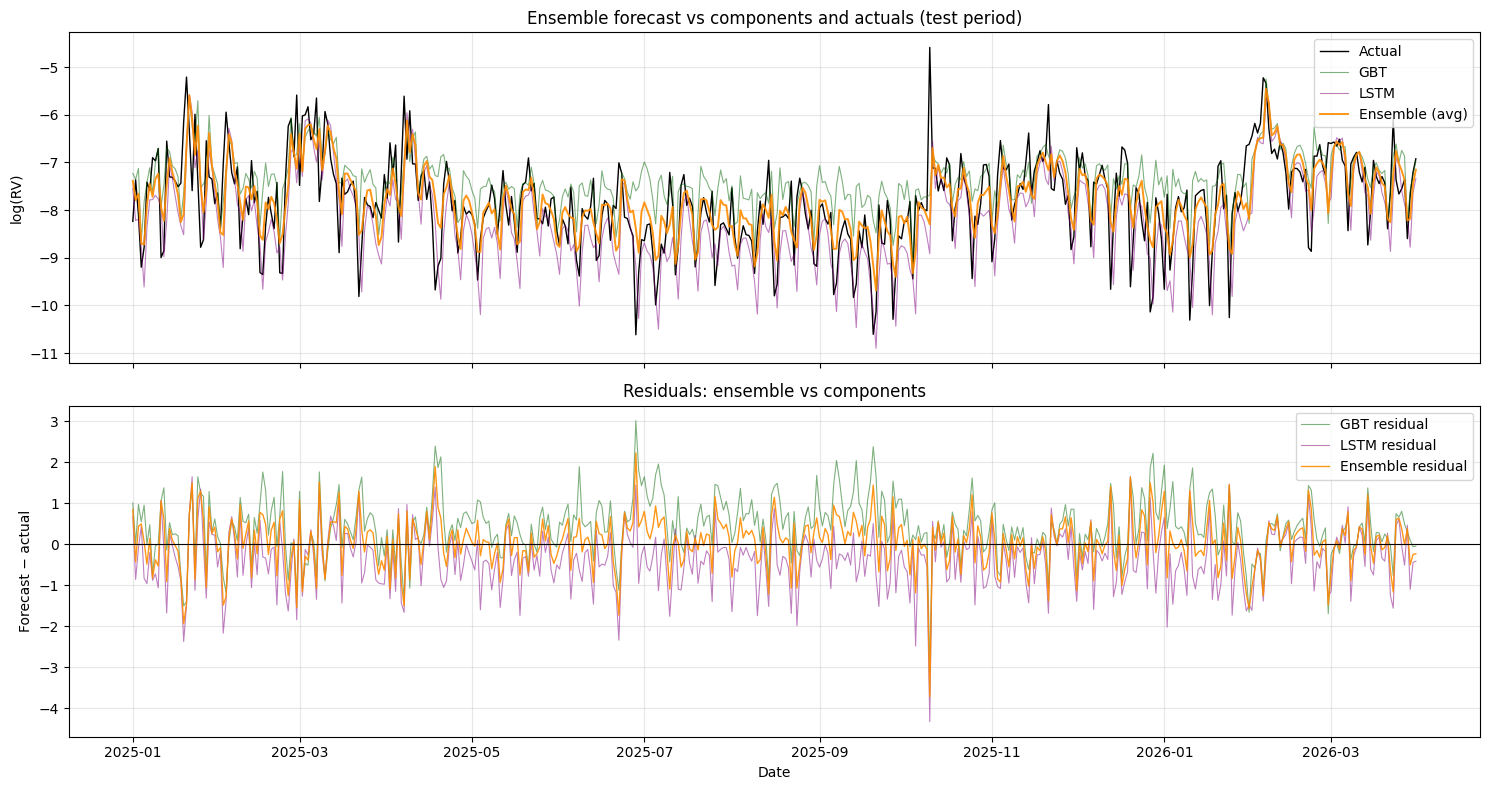

In [84]:
# ============================================================
# Step 1: Build the ensemble predictions
# ============================================================

# Inner-merge GBT and LSTM predictions on date
ensemble_df = gbt_pred_df[["date", "actual_log_rv", "actual_rv", "gbt_pred_log_rv"]].merge(
    lstm_pred_df[["date", "lstm_pred_log_rv"]],
    on="date", how="inner"
)

ensemble_df["ensemble_pred_log_rv"] = (
    ensemble_df["gbt_pred_log_rv"] + ensemble_df["lstm_pred_log_rv"]
) / 2.0

ensemble_df["ensemble_pred_rv"] = np.exp(ensemble_df["ensemble_pred_log_rv"])

print(f"Ensemble predictions for {len(ensemble_df)} test days")
print(f"  Predicted log_rv range: [{ensemble_df['ensemble_pred_log_rv'].min():.3f}, "
      f"{ensemble_df['ensemble_pred_log_rv'].max():.3f}]")
print(f"  Actual log_rv range:    [{ensemble_df['actual_log_rv'].min():.3f}, "
      f"{ensemble_df['actual_log_rv'].max():.3f}]")

# ============================================================
# Step 2: Compute metrics
# ============================================================

metrics_ensemble = compute_metrics(
    ensemble_df["actual_log_rv"], ensemble_df["ensemble_pred_log_rv"],
    ensemble_df["actual_rv"], ensemble_df["ensemble_pred_rv"],
    "Ensemble (GBT + LSTM avg)",
)

# Five-way comparison
all_metrics_df = pd.DataFrame([
    metrics_uni, metrics_multi, metrics_gbt, metrics_lstm, metrics_ensemble
])
print("\nFive-way comparison on test set (lower is better):")
display(all_metrics_df.set_index("model").round(6))

# ============================================================
# Step 3: Bias and residual analysis
# ============================================================

print("\nResidual statistics (forecast − actual, log_rv units):")
print(f"{'Model':<32} {'mean':>10} {'std':>10}")
print("-" * 54)
for label, residuals in [
    ("ARIMA univariate", eval_uni["uni_pred_log_rv"] - eval_uni["actual_log_rv"]),
    ("GBT", gbt_pred_df["gbt_pred_log_rv"] - gbt_pred_df["actual_log_rv"]),
    ("LSTM", lstm_pred_df["lstm_pred_log_rv"] - lstm_pred_df["actual_log_rv"]),
    ("Ensemble (GBT+LSTM avg)",
     ensemble_df["ensemble_pred_log_rv"] - ensemble_df["actual_log_rv"]),
]:
    residuals = residuals.astype("float64")
    print(f"{label:<32} {residuals.mean():>10.4f} {residuals.std():>10.4f}")

# ============================================================
# Step 4: Visualise — actuals + ensemble + GBT + LSTM (drop ARIMAs to declutter)
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax = axes[0]
ax.plot(ensemble_df["date"], ensemble_df["actual_log_rv"], color="black", linewidth=1, label="Actual")
ax.plot(gbt_pred_df["date"], gbt_pred_df["gbt_pred_log_rv"],
        color="darkgreen", linewidth=0.8, alpha=0.5, label="GBT")
ax.plot(lstm_pred_df["date"], lstm_pred_df["lstm_pred_log_rv"],
        color="purple", linewidth=0.8, alpha=0.5, label="LSTM")
ax.plot(ensemble_df["date"], ensemble_df["ensemble_pred_log_rv"],
        color="darkorange", linewidth=1.4, alpha=0.9, label="Ensemble (avg)")
ax.set_ylabel("log(RV)")
ax.set_title("Ensemble forecast vs components and actuals (test period)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(gbt_pred_df["date"],
        gbt_pred_df["gbt_pred_log_rv"] - gbt_pred_df["actual_log_rv"],
        color="darkgreen", linewidth=0.8, alpha=0.5, label="GBT residual")
ax.plot(lstm_pred_df["date"],
        lstm_pred_df["lstm_pred_log_rv"] - lstm_pred_df["actual_log_rv"],
        color="purple", linewidth=0.8, alpha=0.5, label="LSTM residual")
ax.plot(ensemble_df["date"],
        ensemble_df["ensemble_pred_log_rv"] - ensemble_df["actual_log_rv"],
        color="darkorange", linewidth=1.0, alpha=0.9, label="Ensemble residual")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Forecast − actual")
ax.set_xlabel("Date")
ax.set_title("Residuals: ensemble vs components")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cleanup

In [ ]:
# ============================================================
# Step 1: Delete the BigQuery dataset (cascades to all tables/models)
# ============================================================

dataset_id = f"{PROJECT_ID}.{BQ_DATASET}"
print(f"Deleting BigQuery dataset {dataset_id} (with all tables and models)...")

bq_client.delete_dataset(
    dataset_id,
    delete_contents=True,
    not_found_ok=True,
)
print(f"  Deleted {dataset_id}")

# ============================================================
# Step 2: Delete all GCS objects under the project prefix
# ============================================================

print(f"\nDeleting GCS objects under gs://{BUCKET_NAME}/{GCS_PREFIX}/...")
bucket = storage_client.bucket(BUCKET_NAME)
blobs_to_delete = list(bucket.list_blobs(prefix=GCS_PREFIX))

print(f"  Found {len(blobs_to_delete)} blobs to delete")

# Bulk delete (faster than one-by-one for many blobs)
deleted_count = 0
batch_size = 100
for i in range(0, len(blobs_to_delete), batch_size):
    batch = blobs_to_delete[i:i + batch_size]
    with storage_client.batch():
        for blob in batch:
            blob.delete()
    deleted_count += len(batch)
    print(f"  Deleted {deleted_count} / {len(blobs_to_delete)}")

print(f"  Done. Deleted {deleted_count} blobs.")

# ============================================================
# Step 3: Verify cleanup
# ============================================================

print("\nVerification:")

# Check BQ dataset is gone
try:
    bq_client.get_dataset(dataset_id)
    print(f"  BQ dataset {dataset_id} still exists (should be gone)")
except Exception:
    print(f"  BQ dataset {dataset_id} confirmed deleted")

# Check GCS is empty
remaining_blobs = list(bucket.list_blobs(prefix=GCS_PREFIX, max_results=1))
if remaining_blobs:
    print(f"  GCS prefix {GCS_PREFIX} still has objects (should be empty)")
else:
    print(f"  GCS prefix {GCS_PREFIX} confirmed empty")

print("\nCleanup complete.")

# Project 3 — Bitcoin Volatility Forecasting (Time Series) ✅

## Overview

| Attribute | Detail |
|-----------|--------|
| **Dataset** | Binance public archives BTCUSDT 5-minute bars (905k rows, 2017-08-17 to 2026-03-31) + BigQuery public crypto_bitcoin blocks |
| **Task** | One-step-ahead forecasting of daily realized variance from intraday data; primary target is log(RV) |
| **Pipeline** | Binance archive → GCS → BigQuery raw load → typed/partitioned table → daily RV + on-chain features → 4 models + ensemble → batch evaluation |
| **Actual Cost** | ~$1-2 (well under the $8-12 budget) |
| **Actual Time** | ~9-10 hours over the session |

---

## Headline

Forecasting Bitcoin daily realized variance from 8.7 years of 5-minute price bars and on-chain blockchain features. Five models compared on a 15-month held-out period (Jan 2025 – Mar 2026, 455 days): an ARIMA_PLUS climatology baseline, a multivariate ARIMA with exogenous regressors, a Gradient Boosted Trees model with HAR-style features, an LSTM trained on Vertex AI, and an equal-weight ensemble of GBT + LSTM. The ensemble won on every metric — 26% RMSE improvement over baseline, 30% QLIKE improvement — primarily because GBT and LSTM had opposite biases that cancelled in averaging. The most instructive result was the multivariate ARIMA underperforming the univariate baseline despite a strong in-sample fit, illustrating how non-stationary exogenous features can overfit during training and degrade test performance.

---

## Results

**Test period:** 2025-01-01 to 2026-03-31, 455 days  
**Target:** log of daily realized variance, computed from 5-minute log returns  
**Baseline target std:** 1.219; baseline target mean: -7.04 (training period)

| Model | RMSE log_rv | MAE log_rv | RMSE rv | MAE rv | QLIKE | vs ARIMA univariate |
|-------|------------:|-----------:|--------:|-------:|------:|--------------------:|
| ARIMA_PLUS univariate | 0.872 | 0.704 | 0.000796 | 0.000414 | 0.409 | baseline |
| ARIMA_PLUS_XREG multivariate | 1.061 | 0.887 | 0.000990 | 0.000622 | 0.430 | **−22% RMSE (worse)** |
| GBT (one-step-ahead) | 0.829 | 0.645 | 0.000728 | 0.000376 | 0.297 | +5% RMSE / +27% QLIKE |
| LSTM (one-step-ahead) | 0.812 | 0.623 | 0.000746 | 0.000329 | 0.627 | +7% RMSE / -53% QLIKE |
| **Ensemble (GBT + LSTM avg)** | **0.642** | **0.487** | **0.000711** | **0.000300** | **0.288** | **+26% RMSE / +30% QLIKE** |

(Positive percentage = improvement over baseline; negative = degradation.)

### Bias decomposition

| Model | Mean residual | Std residual | Notes |
|-------|--------------:|-------------:|-------|
| ARIMA univariate | +0.259 | 0.833 | Slight over-prediction; flat-line forecast |
| GBT | +0.439 | 0.704 | Over-predicts (regression to training mean) |
| LSTM | -0.354 | 0.732 | Under-predicts (extrapolates calm regime) |
| **Ensemble** | **+0.043** | **0.641** | Bias near-zero; std lower than either component |

The ensemble bias of +0.04 is essentially the average of GBT's +0.44 and LSTM's −0.35 — bias cancellation working as predicted.

---

## Skills Reinforced

| Skill | Original Lab | How It's Applied Here |
|-------|-------------|----------------------|
| BigQuery feature engineering | Lab 1, Lab 9 | Daily aggregations from intraday bars; on-chain metric aggregation |
| ARIMA_PLUS in BQML | Lab 9 | Univariate + multivariate (XREG variant); ML.EXPLAIN_FORECAST decomposition |
| GBT with temporal features | Lab 9 | HAR-style lag and rolling-mean features in BOOSTED_TREE_REGRESSOR |
| LSTM on windowed sequences | Lab 9 | 30-day windows, custom training script on Vertex AI |
| Time-aware splitting | Lab 9 | Strict chronological train/val/test (no random splits) |
| Custom training on Vertex AI | Labs 7-9 | LSTM via prebuilt TF 2.15 container, CustomJob submission |
| Container consistency | Labs 2, 7-9 | TFSMLayer used to load Keras 2 SavedModel under Keras 3 locally |

## New Skill: ARIMA_PLUS with Exogenous Regressors (XREG)

The intended new skill, executed through `ARIMA_PLUS_XREG` model_type with two lagged exogenous features (`tx_count_lag1`, `quote_volume_lag1`). The implementation surfaced two BQML-specific gotchas worth knowing:

- `ARIMA_PLUS_XREG` does NOT support `decompose_time_series=TRUE` — that option is exclusive to plain ARIMA_PLUS. Trade-off: gain exogenous regressors, lose the trend/seasonal decomposition view.
- `ML.FORECAST` for XREG models requires the exogenous values for the forecast period to be passed as a third argument table. Default `horizon` is 3 if not specified explicitly in the STRUCT — caused a confusing "only 3 forecasts returned" failure.

---

## Parts (As Executed)

| Part | Focus | Actual Time |
|------|-------|-------------|
| 1 | Setup + ingest 5-min BTCUSDT bars from Binance to GCS to BigQuery | ~1 hour |
| 2 | Daily realized variance + on-chain feature aggregation | ~45 min |
| 3 | EDA: stationarity (ADF/KPSS), autocorrelation (ACF/PACF), exogenous correlation analysis | ~1 hour |
| 4 | ARIMA_PLUS univariate + multivariate XREG; ML.FORECAST + ML.EXPLAIN_FORECAST | ~1.5 hours |
| 5 | GBT training and evaluation (after debugging a stuck CREATE MODEL job) | ~1.5 hours |
| 6 | LSTM via Vertex AI CustomJob; SavedModel inference via TFSMLayer | ~1.5 hours |
| 7 | Ensemble (equal-weight average of GBT + LSTM); five-way comparison | ~30 min |

---

## Findings

### 1. The ensemble's edge came from bias cancellation, not noise reduction

GBT and LSTM had opposite-direction biases of similar magnitude. Averaging them produced an ensemble residual mean of +0.04, almost exactly zero. The ensemble's variance also dropped (0.641 std vs ~0.72 for either component), but the bias correction did most of the work. RMSE² = bias² + variance, and our bias² fell from ~0.19 (GBT) and ~0.13 (LSTM) to ~0.002 (ensemble).

### 2. Adding exogenous features can hurt out-of-sample performance

ARIMA_PLUS_XREG with `total_transaction_count` and `daily_quote_volume` as level features had:
- In-sample AIC: −913 vs univariate (massive improvement)
- In-sample variance: 0.203 vs 0.285 (29% reduction)
- Test RMSE: 1.061 vs 0.872 (22% *worse* than univariate baseline)

The exogenous features and target both trended over the training period (network growth + secular vol decline). The model fitted the joint trend correlation but the relationship didn't hold out-of-sample. This is the textbook spurious-correlation trap with non-stationary data, surfaced in EDA Lens 1 vs Lens 2 but underweighted at modelling time.

### 3. The choice of evaluation metric changed the model ranking

LSTM had the lowest RMSE log_rv (0.812) but the highest QLIKE (0.627) — more than 2× worse than GBT. QLIKE asymmetrically penalises underestimation of variance, and LSTM's tendency to predict log_rv values as low as -10.9 on calm days (when actuals were closer to -9) triggered that penalty repeatedly. For risk-management applications, GBT's conservative behaviour was preferable; for raw error minimisation, LSTM was preferable. Different metrics, different winners.

### 4. ARIMA's static-origin forecasting collapses to climatology beyond ~30 days

ML.EXPLAIN_FORECAST decomposition revealed that during the 455-day forecast window, the trend component went flat at the long-run mean (-7.5) and only the weekly seasonal component contributed dynamics. So ARIMA's RMSE of 0.872 was approximately what you'd get from "predict the long-run mean plus weekly seasonality." This is a hard baseline to beat in absolute terms — climatology has no bias and reasonable error — and partly explains why even the best model (ensemble at 0.642) only got 26% better.

### 5. Statistical model identification (PACF/ACF) and tree feature importance disagree

PACF said lag-1 dominated (autocorrelation = 0.755). The GBT picked `log_rv_roll7` (7-day rolling mean) as the most important feature, ahead of `log_rv_lag1`. Same underlying signal — recent vol predicts current vol — but the tree found the smoothed version more useful for splits than the raw lag-1 value. Linear correlation analysis and tree feature importance measure different things.

### 6. Long-memory in volatility data is real and non-trivial

ACF of log_rv stayed at 0.23 even at lag 80 days — substantially above the 0.035 noise threshold. A pure AR(1) process with the same lag-1 autocorrelation would crash to near-zero by lag 30. This is the classic long-memory signature in volatility data; it justifies the HAR-style feature engineering (5/7/22-day rolling means in addition to point lags).

---

## Surprises (predictions vs reality)

| Prediction | Reality |
|-----------|---------|
| Multivariate ARIMA modestly beats univariate | Multivariate substantially **lost** to univariate on test |
| GBT and LSTM perform similarly | They did, but with opposite biases that made them complementary |
| Ensemble might give 1-2% gain | Ensemble gave 21% gain over LSTM, 23% over GBT |
| `log_rv_lag1` would dominate GBT feature importance | `log_rv_roll7` led, lag-1 second |
| BQML's "trend" component would be a smooth long-run line | It tracks daily fluctuations; AIC-based decomposition is different from STL-style decomposition |
| ARIMA_PLUS_XREG would inherit ARIMA_PLUS's full feature set | It loses several auto-detection features (notably `decompose_time_series`) |

---

## Key Learnings

### Modelling

- **Volatility forecasting is genuinely tractable.** ACF showed long-memory persistence (0.23 at lag 80), PACF dominated by lag 1 with significant lag 7 / 14 spikes (weekly seasonality). The signal is real and forecastable.
- **ARIMA_PLUS converges to flat-line forecasts at long horizons.** ML.EXPLAIN_FORECAST decomposition revealed that beyond the first ~30 days of forecasting, only the weekly seasonal component contributes dynamics — the trend collapses to the long-run mean. This is the AR(1) decay-to-mean property in action.
- **Tree models are conservative; neural models are aggressive.** GBT clusters predictions near the training distribution mean (cannot extrapolate). LSTM extrapolates freely along learned patterns and can dramatically under- or over-predict regime extremes. These are inductive biases of the model families, not bugs.
- **The ensemble of two adequate models beats either individually.** Bias cancellation is the mechanism: GBT residual mean +0.44, LSTM residual mean -0.35, ensemble residual mean +0.04. Variance also reduces from averaging. Equal-weight averaging is often within 1-2% of more sophisticated stacking — try simple averages first.
- **Different metrics produce different "winners".** LSTM was best on RMSE/MAE log_rv but worst on QLIKE (the canonical vol metric that asymmetrically punishes underestimation). Don't trust a single number for model selection.

### Design discipline (Thread 5 lesson)

- **EDA findings have to translate to model design choices, not just be acknowledged.** The EDA showed that on-chain feature *levels* correlated with log_rv only because both shared a non-stationary trend; *changes* had near-zero correlation. The first ARIMA_PLUS_XREG attempt used levels and overfit to the trend (1.06 RMSE on test, *worse* than the univariate baseline at 0.87). The GBT and LSTM models used differenced exogenous features and avoided the trap.
- **In-sample improvement does not guarantee out-of-sample improvement.** ARIMA_PLUS_XREG's AIC dropped 913 points and in-sample variance fell 29% relative to the univariate model — yet test RMSE got *worse*. With 3,000+ observations, almost anything is statistically significant; effect size and out-of-sample stability matter more than p-values.
- **Statistical significance is not effect size, especially with non-stationary data.** Two trending series will spuriously correlate even when there's no real predictive relationship; differencing the inputs is the canonical defence.

### BQML / Vertex AI gotchas

- **`ARIMA_PLUS_XREG` lacks `decompose_time_series` support** — this option is for plain `ARIMA_PLUS` only.
- **`ML.FORECAST` default `horizon` is 3** — must be set explicitly inside the STRUCT, even for XREG models that take an exogenous-values table as the third argument.
- **`BOOSTED_TREE_REGRESSOR` with `data_split_method='CUSTOM'` + `early_stop=TRUE` can hang indefinitely.** First training attempt consumed 6h 46m of slot time without completing a single iteration. Stripping to `WHERE split = 'train'` only and removing early_stop made it train in ~5 minutes. Lesson: start with the simplest CREATE MODEL config and add features one at a time.
- **GCS directory marker blobs cause `IsADirectoryError` on local download.** Filter blobs whose names end in `/` when downloading SavedModel directories.
- **Keras 2 SavedModels need TFSMLayer, not load_model, under Keras 3.** Same lesson as Lab 9. The signature can also appear corrupted (`unknown:0` tensor names) but TFSMLayer handles it correctly.

### Data engineering

- **Public datasets are tied to their region.** `bigquery-public-data` is in `US` multi-region; queries that read from it must write to a dataset in `US`. Initial dataset created in `us-central1` had to be dropped and recreated.
- **Binance changed timestamp units mid-2024.** Pre-2024 monthly archives have timestamps in milliseconds (13 digits); 2025+ archives use microseconds (16 digits). Magnitude-based CASE expression handled both cleanly without re-ingesting any data.
- **The "raw → typed/partitioned" two-step pattern is industry standard for a reason.** Letting raw data land as-is means re-running the transform doesn't require re-ingesting. The transform CTAS handled the timestamp-unit conversion in pure SQL.
- **Partition filtering is the cheap-query enabler.** Querying 16 years of `crypto_bitcoin.blocks` with partition filter `timestamp_month >= '2017-08-01'` cost $0.0001. Without the filter, the same query would have scanned the full table.

### Cost discipline

- **`storage_client.batch()` for bulk GCS deletes** — packs up to 100 deletions into one HTTP round trip, ~50x faster than serial deletes for the cleanup step.
- **`total_bytes_billed` after every BQ query** — printing the actual cost surfaces problem queries before they hit a monthly bill.
- **Ensemble was free improvement.** Computing GBT and LSTM predictions individually was the expensive part; averaging them cost nothing and produced the best model.